#Modeling 1

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
TOKEN_tabpfn_client="xxx"

In [ ]:
#Definindo semente

In [ ]:
#instalação das bibliotecas não nativas no Colab
!pip install boruta shap
!pip install xgboost
!pip install lightgbm
!pip install catboost
!pip install tabpfn
!pip install tabpfn-client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.2/771.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.3/472.3 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.6/220.6 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 618.0/618.0 kB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73

In [ ]:
# TabPFN Client
import tabpfn_client
print("tabpfn_client:", tabpfn_client.__version__)

# TabPFN
import tabpfn
print("tabpfn:", tabpfn.__version__)

# XGBoost
import xgboost
print("xgboost:", xgboost.__version__)

# CatBoost
import catboost
print("catboost:", catboost.__version__)

# LightGBM
import lightgbm
print("lightgbm:", lightgbm.__version__)

# Scikit-learn (onde está o RandomForest)
import sklearn
print("scikit-learn:", sklearn.__version__)

tabpfn_client: 0.5.3
tabpfn: 8.5.0
xgboost: 3.4.1
catboost: 1.2.10
lightgbm: 4.6.0
scikit-learn: 1.6.1


In [ ]:
from importlib.metadata import version

print("boruta:", version("Boruta"))

boruta: 0.4.3


In [ ]:
def set_seed(seed=42):
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)

    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass

    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except ImportError:
        pass


In [ ]:
#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from xgboost import XGBClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

#seleção das variáveis
from boruta import BorutaPy

#importancia das variaveis
import shap

#definição de seed para reprodutibilidade
seed = 42

In [ ]:
# Instalando pacotes

In [ ]:
!pip install dfply
!pip install scikit-plot
!pip install graphviz
!pip install dtreeviz
!pip install imbalanced-learn
!pip install pycalib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 612.4/612.4 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pycalib: filename=pycalib-0.1.0.dev6-py3-none-any.whl size=37368 sha256=dd1657e91edeee39919b9ca428ff4f2f2e86cb223ffd32479e795b783ffaf954
  Stored in directory: /root/.cache/pip/wheels/ec/b5/10/93c91bf324e855f115998634a7f6091b62d7a6a32d6e62c05b
Successfully built pycalib


In [ ]:
# Carregando pacotes

In [ ]:
import pandas as pd  # processamento de bancos de dados
import numpy as np  # processamento numérico
import matplotlib.pyplot as plt  # geração de gráficos
import seaborn as sns  # geração de gráficos alternativos

#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from tabpfn import TabPFNClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, FixedThresholdClassifier
from sklearn.metrics import roc_curve, precision_recall_curve, auc, classification_report, confusion_matrix
from sklearn.calibration import calibration_curve

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração de gráficos no notebook
%matplotlib inline
plt.rcParams["figure.figsize"] = [10, 5]
plt.style.use("fivethirtyeight")
%config InlineBackend.figure_format = 'retina'

# Configurações de fonte e matemática
from matplotlib import rc
rc('font', **{'family': 'sans-serif', 'sans-serif': ['DejaVu Sans'], 'size': 10})
rc('mathtext', **{'default': 'regular'})

#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from xgboost import XGBClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

#seleção das variáveis
from boruta import BorutaPy

#importancia das variaveis
import shap

# SCIKIT-LEARN

#bibliotecas do sklearn para preprocessamento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import (roc_curve, auc, confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             accuracy_score, brier_score_loss)
from sklearn.model_selection import (KFold, cross_val_score, train_test_split,
                                     GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier

from sklearn import preprocessing
from tabpfn import TabPFNClassifier

import shap

# Biblioteca dfply
from dfply import *

# Visualização de árvores de decisão
from dtreeviz.trees import *

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

from collections import Counter

# Ignorar warnings
import warnings
warnings.filterwarnings("ignore")

# Definição de semente de aleatoriedade
np.random.seed(42)

#definição de seed para reprodutibilidade
seed = 42

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/dados_treino_processados1_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/dados_teste_processados1_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
# Separação das bases entre X_train, X_test, y_train, y_test

X_train = df_train.drop(columns=["cura"])
y_train = df_train["cura"]

X_test = df_test.drop(columns=["cura"])
y_test = df_test["cura"]

In [ ]:
X_train.head()

,pop,cs_sexo_0.0,cs_sexo_1.0,cs_sexo_9.0,cs_raca_1.0,cs_raca_2.0,cs_raca_3.0,cs_raca_4.0,cs_raca_5.0,cs_raca_9.0,...,escola_faixa_10.0,contato_5_15_0.0,contato_5_15_1.0,contato_5_15_2.0,contato_5_15_9.0,faixa_etaria_0.0,faixa_etaria_1.0,faixa_etaria_2.0,faixa_etaria_3.0,faixa_etaria_9.0
0,0.745332,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.745332,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.745332,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.745332,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.745332,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
X.train.columns

##• Proporção do desfecho (Obrigatório)

In [ ]:
#Visualização da proporção do desfecho na base de treino
y_train.value_counts(normalize=True)

,proportion
cura,
1,0.803671
0,0.196329


In [ ]:
#Visualização da proporção do desfecho na base de teste
y_test.value_counts(normalize=True)

,proportion
cura,
1,0.830967
0,0.169033


#3- Criação e Avaliação dos Modelos Iniciais

---



##Criação e Tuning dos Modelos

###Random Forest

####Hyperopt

In [ ]:
!pip install hyperopt

In [ ]:
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Espaço de busca do Hyperopt
space = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.quniform('max_depth', 5, 14, 1),
    'min_samples_split': hp.uniform('min_samples_split', 0.01, 0.05),
    'min_samples_leaf': hp.choice('min_samples_leaf', [5, 10, 26]),
    'max_features': hp.choice('max_features', [None, 'sqrt', 'log2'])
}

# Função objetivo
def objective(params):
    model = RandomForestClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        min_samples_split=params['min_samples_split'],
        min_samples_leaf=params['min_samples_leaf'],
        max_features=params['max_features'],
        random_state=seed,
        n_jobs=-1
    )

    # Acurácia via cross validation (ROC AUC)
    score = cross_val_score(model, X_train, y_train, scoring="roc_auc", cv=5, n_jobs=-1).mean()

    # Hyperopt minimiza → então retornamos o negativo
    return {'loss': -score, 'status': STATUS_OK}

# Armazena resultados
trials = Trials()

# Execução da busca
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,   # Número de iterações (equivale ao n_iter)
    trials=trials,
    rstate=np.random.default_rng(seed)
)

print("\nMelhores hiperparâmetros encontrados:")
print(best)

# Reconstruindo o modelo final com os melhores parâmetros
best_params_hyperopt = {
    'n_estimators': [200, 300, 400, 500][best['n_estimators']],
    'max_depth': int(best['max_depth']),
    'min_samples_split': best['min_samples_split'],
    'min_samples_leaf': [5, 10, 26][best['min_samples_leaf']],
    'max_features': [None, 'sqrt', 'log2'][best['max_features']],
    'random_state': seed
}

rf_hyperopt = RandomForestClassifier(**best_params_hyperopt)
rf_hyperopt.fit(X_train, y_train)

print("\nModelo final treinado com Hyperopt.")

# Print dos melhores hiperparâmetros
print("Hiperparametros do rf ", best_params_hyperopt)


100%|██████████| 50/50 [17:15<00:00, 20.71s/trial, best loss: -0.712781642739883]

Melhores hiperparâmetros encontrados:
{'max_depth': np.float64(14.0), 'max_features': np.int64(2), 'min_samples_leaf': np.int64(0), 'min_samples_split': np.float64(0.01029621509884489), 'n_estimators': np.int64(2)}

Modelo final treinado com Hyperopt.
Hiperparametros do rf  {'n_estimators': 400, 'max_depth': 14, 'min_samples_split': np.float64(0.01029621509884489), 'min_samples_leaf': 5, 'max_features': 'log2', 'random_state': 42}


In [ ]:
rf_hyperopt = RandomForestClassifier(**best_params_hyperopt)
rf_hyperopt.fit(X_train, y_train)

RandomForestClassifier(max_depth=14, max_features='log2', min_samples_leaf=5,
                       min_samples_split=np.float64(0.01029621509884489),
                       n_estimators=400, random_state=42)

In [ ]:
# Generate predictions and probabilities
y_pred_rf_hyperopt = rf_hyperopt.predict(X_test)
y_prob_rf_hyperopt = rf_hyperopt.predict_proba(X_test)[:, 1]

# Métricas
auc_rf_hyperopt = roc_auc_score(y_test, y_prob_rf_hyperopt)

# Impressão
print(f'rf - ROC AUC: {auc_rf_hyperopt:.4f}')

rf - ROC AUC: 0.7155


In [ ]:
# Depois do Hyperopt
auc_rf_hyperopt = roc_auc_score(y_test, y_prob_rf_hyperopt)
auc_cv_rf_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials
)
params_rf_hyperopt = best_params_hyperopt

In [ ]:
for params, value in best_params_hyperopt.items():
  print(f"{params}: {value}")

n_estimators: 400
max_depth: 14
min_samples_split: 0.01029621509884489
min_samples_leaf: 5
max_features: log2
random_state: 42


####Random Search

In [ ]:
# Modelo e dicionário de busca
rf=RandomForestClassifier(random_state=seed)
rf_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 100 a 500
    'max_depth': np.arange(5, 15, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_samples_split': np.arange(0.01, 0.06, 0.01),  # número mínimo de observaçoes ou proporcao para fazer a quebra
    'min_samples_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'max_features': [None, 'sqrt', 'log2']
}

# Criação do random search
rf_rs=RandomizedSearchCV(estimator=rf,
                         param_distributions=rf_dict,
                         scoring="roc_auc",
                         cv=5,
                         n_iter=20,
                         n_jobs=-1,
                         random_state=seed
                         )

# Fit do random search
rf_rs.fit(X_train, y_train)

# Print dos melhores hiperparâmetros
print("Hiperparametros do rf ", rf_rs.best_params_)

# Criação do modelo final
rf=rf_rs.best_estimator_


Hiperparametros do rf  {'n_estimators': np.int64(500), 'min_samples_split': np.float64(0.01), 'min_samples_leaf': 10, 'max_features': None, 'max_depth': np.int64(10)}


In [ ]:
# Generate predictions and probabilities
y_pred_rf_rs = rf.predict(X_test)
y_prob_rf_rs = rf.predict_proba(X_test)[:, 1]

# Métricas
auc_rf_rs = roc_auc_score(y_test, y_prob_rf_rs)
auc_cv_rf_rs = rf_rs.best_score_

# Impressão
print(f'rf - ROC AUC: {auc_rf_rs:.4f}')

rf - ROC AUC: 0.7123


In [ ]:
# Depois do Random Search
auc_rf_rs = roc_auc_score(y_test, y_prob_rf_rs)
params_rf_rs = rf_rs.best_params_

In [ ]:
for params, value in rf_rs.best_params_.items():
    print(f"{params}: {value}")


n_estimators: 500
min_samples_split: 0.01
min_samples_leaf: 10
max_features: None
max_depth: 10


####Optuna

In [ ]:
!pip install optuna


In [ ]:
import optuna
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score


In [ ]:
def objective(trial):

    rf = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        min_samples_split=trial.suggest_float("min_samples_split", 0.01, 0.05),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 26),
        max_features=trial.suggest_categorical(
            "max_features", [None, "sqrt", "log2"]
        ),
        random_state=seed,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        rf,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc
# ===============================
# IMPORTS
# ===============================
import numpy as np
import optuna

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# ===============================
# OPTUNA - FUNÇÃO OBJETIVO
# ===============================
def objective(trial):

    rf = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        min_samples_split=trial.suggest_float("min_samples_split", 0.01, 0.05),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 26),
        max_features=trial.suggest_categorical(
            "max_features", [None, "sqrt", "log2"]
        ),
        random_state=seed,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        rf,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


# ===============================
# RODAR OPTUNA
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("\nMelhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros:")
print(study.best_params)


# ===============================
# TREINO DO MODELO FINAL
# ===============================
rf = RandomForestClassifier(
    **study.best_params,
    random_state=seed,
    n_jobs=-1
)

rf.fit(X_train, y_train)


# ===============================
# PREDIÇÕES
# ===============================
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]




[I 2026-07-05 11:50:45,446] A new study created in memory with name: no-name-dbc68dee-e97a-44f9-9a2a-47ad06602aba
[I 2026-07-05 11:51:54,022] Trial 0 finished with value: 0.713674009323688 and parameters: {'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 0.03095111395458644, 'min_samples_leaf': 19, 'max_features': None}. Best is trial 0 with value: 0.713674009323688.
[I 2026-07-05 11:52:05,738] Trial 1 finished with value: 0.7127854491563979 and parameters: {'n_estimators': 200, 'max_depth': 13, 'min_samples_split': 0.019137784168495542, 'min_samples_leaf': 25, 'max_features': 'log2'}. Best is trial 0 with value: 0.713674009323688.
[I 2026-07-05 11:52:17,556] Trial 2 finished with value: 0.7109687343486559 and parameters: {'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 0.04090428221175387, 'min_samples_leaf': 11, 'max_features': 'log2'}. Best is trial 0 with value: 0.713674009323688.
[I 2026-07-05 11:52:24,299] Trial 3 finished with value: 0.7125254347555974 and p


Melhor AUC (CV): 0.7158051660718308
Melhores hiperparâmetros:
{'n_estimators': 500, 'max_depth': 12, 'min_samples_split': 0.010561809310118356, 'min_samples_leaf': 8, 'max_features': 'sqrt'}


In [ ]:
# Generate predictions and probabilities
y_pred_rf_optuna = rf.predict(X_test)
y_prob_rf_optuna = rf.predict_proba(X_test)[:, 1]

# Métricas
auc_rf_optuna = roc_auc_score(y_test, y_prob_rf_optuna)
auc_cv_rf_optuna = study.best_value

# Impressão
print(f'rf - ROC AUC: {auc_rf_optuna:.4f}')

rf - ROC AUC: 0.7153


In [ ]:
auc_rf_optuna = roc_auc_score(y_test, y_prob_rf_optuna)
params_rf_optuna = study.best_params

In [ ]:
for params, value in study.best_params.items():
    print(f"{params}: {value}")


n_estimators: 500
max_depth: 12
min_samples_split: 0.010561809310118356
min_samples_leaf: 8
max_features: sqrt


####Selecionando melhor modelo completo

In [ ]:
import pandas as pd



# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_rf = pd.DataFrame({
    'Modelo': ['RandomForest'],
    'RandomSearch': [auc_cv_rf_rs],
    'Hyperopt': [auc_cv_rf_hyperopt],
    'Optuna': [auc_cv_rf_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_rf = pd.DataFrame({
    'Modelo': ['RandomForest'],
    'RandomSearch': [params_rf_rs],
    'Hyperopt': [params_rf_hyperopt],
    'Optuna': [params_rf_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_rf)


===== Tabela AUC-ROC =====
         Modelo  RandomSearch  Hyperopt    Optuna
0  RandomForest      0.711617  0.712782  0.715805


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_rf = df_auc_rf.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_rf = df_auc_rf.drop(columns='Modelo').max(axis=1)[0]
best_model_rf = df_auc_rf['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_rf} ({best_method_rf}) = {best_auc_rf:.4f}")

✅ Modelo com maior AUC-ROC: RandomForest (Optuna) = 0.7158


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_rf == 'RandomSearch':
    best_params_rf_final = params_rf_rs
elif best_method_rf == 'Hyperopt':
    best_params_rf_final = params_rf_hyperopt
elif best_method_rf == 'Optuna':
    best_params_rf_final = params_rf_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_rf}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_rf_final)



✅ Melhor método: Optuna
🔧 Hiperparâmetros selecionados:
{'n_estimators': 500, 'max_depth': 12, 'min_samples_split': 0.010561809310118356, 'min_samples_leaf': 8, 'max_features': 'sqrt'}


In [ ]:
print("params_rf_rs:")
print(params_rf_rs)
print(type(params_rf_rs))

print("\nparams_rf_hyperopt:")
print(params_rf_hyperopt)
print(type(params_rf_hyperopt))

print("\nparams_rf_optuna:")
print(params_rf_optuna)
print(type(params_rf_optuna))

params_rf_rs:
{'n_estimators': np.int64(500), 'min_samples_split': np.float64(0.01), 'min_samples_leaf': 10, 'max_features': None, 'max_depth': np.int64(10)}
<class 'dict'>

params_rf_hyperopt:
{'n_estimators': 400, 'max_depth': 14, 'min_samples_split': np.float64(0.01029621509884489), 'min_samples_leaf': 5, 'max_features': 'log2', 'random_state': 42}
<class 'dict'>

params_rf_optuna:
{'n_estimators': 500, 'max_depth': 12, 'min_samples_split': 0.010561809310118356, 'min_samples_leaf': 8, 'max_features': 'sqrt'}
<class 'dict'>


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Criar modelo com os melhores parâmetros
rf_final = RandomForestClassifier(
    **{**best_params_rf_final, **({"random_state": seed} if "random_state" not in best_params_rf_final else {})}
)

# Treinar usando seus dados completos de treino
rf_final.fit(X_train, y_train)

RandomForestClassifier(max_depth=12, min_samples_leaf=8,
                       min_samples_split=0.010561809310118356, n_estimators=500,
                       random_state=42)

####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_rf.pkl"

joblib.dump(rf_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_rf.pkl


In [ ]:
joblib.dump({
    "model_rf": rf_final,
    "params_rf": best_params_rf_final,
    "method_rf": best_method_rf,
    "auc_cv_rf": best_auc_rf
}, caminho)

In [ ]:
data = joblib.load(caminho)

rf = data["model_rf"]
print(data["params_rf"])
print(data["method_rf"])
print(data["auc_cv_rf"])

{'n_estimators': 500, 'max_depth': 12, 'min_samples_split': 0.010561809310118356, 'min_samples_leaf': 8, 'max_features': 'sqrt'}
Optuna
0.7158051660718308


###LGBM

####Hyperopt

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install hyperopt

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# Espaço de busca do Hyperopt
# ===============================
space_lgb = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.quniform('max_depth', 5, 15, 1),
    'min_data_in_leaf': hp.choice('min_data_in_leaf', np.arange(5, 27, 1)),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(1e-3), np.log(1.0)),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# ===============================
# Função objetivo Hyperopt
# ===============================
def objective_hyperopt(params):
    lgb = LGBMClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        min_data_in_leaf=int(params['min_data_in_leaf']),
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        random_state=seed,
        n_jobs=-1
    )

    # Cross-validation ROC-AUC
    score = cross_val_score(
        lgb,
        X_train,
        y_train,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    ).mean()

    # Hyperopt minimiza, então retornamos negativo
    return {'loss': -score, 'status': STATUS_OK}

# ===============================
# Executar Hyperopt
# ===============================
trials = Trials()

best_hyperopt = fmin(
    fn=objective_hyperopt,
    space=space_lgb,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(seed)
)

# ===============================
# Reconstruir dicionário final de hiperparâmetros
# ===============================
best_params_hyperopt = {
    'n_estimators': [200, 300, 400, 500][best_hyperopt['n_estimators']],
    'max_depth': int(best_hyperopt['max_depth']),
    'min_data_in_leaf': int(best_hyperopt['min_data_in_leaf']),
    'learning_rate': best_hyperopt['learning_rate'],
    'subsample': best_hyperopt['subsample'],
    'colsample_bytree': best_hyperopt['colsample_bytree'],
    'reg_alpha': best_hyperopt['reg_alpha'],
    'reg_lambda': best_hyperopt['reg_lambda']
}

print("\n✅ Melhores hiperparâmetros Hyperopt:")
print(best_params_hyperopt)

# ===============================
# Treinar modelo final LGBM
# ===============================
lgb = LGBMClassifier(
    **best_params_hyperopt,
    random_state=seed,
    n_jobs=-1
)

lgb.fit(X_train, y_train)

# ===============================
# Predições e ROC-AUC
# ===============================
y_prob_lgb = lgb.predict_proba(X_test)[:, 1]
auc_lgb_hyperopt = roc_auc_score(y_test, y_prob_lgb)
print(f"✅ ROC-AUC teste Hyperopt: {auc_lgb_hyperopt:.4f}")

100%|██████████| 50/50 [09:00<00:00, 10.82s/trial, best loss: -0.7162216825445117]

✅ Melhores hiperparâmetros Hyperopt:
{'n_estimators': 200, 'max_depth': 7, 'min_data_in_leaf': 0, 'learning_rate': np.float64(0.024960003735517), 'subsample': np.float64(0.9372230279998082), 'colsample_bytree': np.float64(0.6135469808943453), 'reg_alpha': np.float64(0.2522941965095827), 'reg_lambda': np.float64(1.5401416364277283)}
[LightGBM] [Warning] min_data_in_leaf is set=0, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=0
[LightGBM] [Warning] min_data_in_leaf is set=0, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=0
[LightGBM] [Info] Number of positive: 14712, number of negative: 3594
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006320 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 158
[LightGBM] [I

In [ ]:
# Generate predictions and probabilities
y_pred_lgb_hyperopt = lgb.predict(X_test)
y_prob_lgb_hyperopt = lgb.predict_proba(X_test)[:, 1]

# Métricas
auc_lgb_hyperopt = roc_auc_score(y_test, y_prob_lgb_hyperopt)
auc_cv_lgb_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials)

# Impressão
print(f'lgb - ROC AUC: {auc_lgb_hyperopt:.4f}')

In [ ]:
# Depois do Hyperopt
auc_lgb_hyperopt = roc_auc_score(y_test, y_prob_lgb_hyperopt)
params_lgb_hyperopt = best_params_hyperopt

In [ ]:
for param, value in best_params_hyperopt.items():
    print(f"{param}: {value}")

####Optuna

In [ ]:
!pip install optuna


In [ ]:
# ===============================
# IMPORTS
# ===============================
import optuna
import numpy as np

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

# ===============================
# FUNÇÃO OBJETIVO
# ===============================
def objective_lgb(trial):

    lgb = LGBMClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        min_data_in_leaf=trial.suggest_int("min_data_in_leaf", 5, 26),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        random_state=seed,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        lgb,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


# ===============================
# RODAR OPTUNA
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective_lgb, n_trials=50)

print("\nMelhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros:")
print(study.best_params)


# ===============================
# MODELO FINAL (lgb)
# ===============================
lgb = LGBMClassifier(
    **study.best_params,
    random_state=seed,
    n_jobs=-1
)

lgb.fit(X_train, y_train)

# ===============================
# PREDIÇÕES
# ===============================
y_pred_lgb = lgb.predict(X_test)
y_prob_lgb = lgb.predict_proba(X_test)[:, 1]

print("ROC-AUC teste:", roc_auc_score(y_test, y_prob_lgb))


In [ ]:
# Generate predictions and probabilities
y_pred_lgb_optuna = lgb.predict(X_test)
y_prob_lgb_optuna = lgb.predict_proba(X_test)[:, 1]

# Métricas
auc_lgb_optuna = roc_auc_score(y_test, y_prob_lgb_optuna)

# Impressão
print(f'lgb - ROC AUC: {auc_lgb_optuna:.4f}')

In [ ]:
auc_lgb_optuna = roc_auc_score(y_test, y_prob_lgb_optuna)
auc_cv_lgb_optuna = study.best_value
params_lgb_optuna = study.best_params

In [ ]:
for param, value in study.best_params.items():
    print(f"{param}: {value}")

####Random Search

In [ ]:
# Modelo e dicionário de busca
lgb=LGBMClassifier(random_state=seed)
lgb_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 1
    'max_depth': np.arange(5, 15, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_data_in_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'learning_rate': np.logspace(-2, -0.7, 4),          # taxa de aprendizado, de 0.01 a 0.2 em escala logarítmica
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'colsample_bytree': np.linspace(0.6, 1.0, 3),       # proporção de features usadas por árvore
    'reg_alpha': np.logspace(-3, 0, 4),                 # regularização L1, de 0.001 a 1
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2
}

# Criação do random search
lgb_rs=RandomizedSearchCV(estimator=lgb,
                         param_distributions=lgb_dict,
                         scoring="roc_auc",
                         cv=5,
                         n_iter=20,
                         n_jobs=-1,
                         random_state=seed
                         )

# Fit do random search
lgb_rs.fit(X_train, y_train)

# Print dos melhores hiperparâmetros
print("Hiperparametros do lgb ", lgb_rs.best_params_)

# Criação do modelo final
lgb=lgb_rs.best_estimator_

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Info] Number of positive: 14712, number of negative: 3594
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006178 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 156
[LightGBM] [Info] Number of data points in the train set: 18306, number of used features: 57
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.803671 -> initscore=1.409398
[LightGBM] [Info] Start training from score 1.409398
Hiperparametros do lgb  {'subsample': np.float64(1.0), 'reg_lambda': np.float64(1.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(400), 'min_data_in_leaf': 10, 'max_depth': np.int64(8), 'lear

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Probabilidades
y_prob_lgb = lgb.predict_proba(X_test)[:, 1]

# Aplica o threshold
threshold = 0.5
y_pred_lgb = (y_prob_lgb >= threshold).astype(int)

# Métricas
auc_lgb = roc_auc_score(y_test, y_prob_lgb)  # Continua usando probabilidade para o AUC

# Impressão
print(f'lgb - ROC AUC: {auc_lgb:.4f}')

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
lgb - ROC AUC: 0.7226


In [ ]:
# Depois
auc_lgb_rs = roc_auc_score(y_test, y_prob_lgb)
auc_cv_lgb_rs = lgb_rs.best_score_
params_lgb_rs = lgb_rs.best_params_

In [ ]:
for params, value in lgb_rs.best_params_.items():
    print(f"{params}: {value}")


subsample: 1.0
reg_lambda: 1.0
reg_alpha: 1.0
n_estimators: 400
min_data_in_leaf: 10
max_depth: 8
learning_rate: 0.01
colsample_bytree: 0.6


####Selecionando melhor modelo completo

In [ ]:
import pandas as pd

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_lgb = pd.DataFrame({
    'Modelo': ['lgb'],
    'RandomSearch': [auc_cv_lgb_rs],
    'Hyperopt': [auc_cv_lgb_hyperopt],
    'Optuna': [auc_cv_lgb_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_lgb = pd.DataFrame({
    'Modelo': ['lgb'],
    'RandomSearch': [params_lgb_rs],
    'Hyperopt': [params_lgb_hyperopt],
    'Optuna': [params_lgb_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_lgb)


===== Tabela AUC-ROC =====
  Modelo  RandomSearch  Hyperopt    Optuna
0    lgb      0.716842  0.716222  0.719252


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_lgb = df_auc_lgb.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_lgb = df_auc_lgb.drop(columns='Modelo').max(axis=1)[0]
best_model_lgb = df_auc_lgb['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_lgb} ({best_method_lgb}) = {best_auc_lgb:.4f}")

✅ Modelo com maior AUC-ROC: lgb (Optuna) = 0.7193


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_lgb == 'RandomSearch':
    best_params_lgb_final = params_lgb_rs
elif best_method_lgb == 'Hyperopt':
    best_params_lgb_final = params_lgb_hyperopt
elif best_method_lgb == 'Optuna':
    best_params_lgb_final = params_lgb_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_lgb}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_lgb_final)



✅ Melhor método: Optuna
🔧 Hiperparâmetros selecionados:
{'n_estimators': 400, 'max_depth': 10, 'min_data_in_leaf': 14, 'learning_rate': 0.01288467930680873, 'subsample': 0.8292348312452953, 'colsample_bytree': 0.602625567180822, 'reg_alpha': 0.44685839723398, 'reg_lambda': 1.6167023810624825}


In [ ]:
print("params_lgb_rs:")
print(params_lgb_rs)
print(type(params_lgb_rs))

print("\nparams_lgb_hyperopt:")
print(params_lgb_hyperopt)
print(type(params_lgb_hyperopt))

print("\nparams_lgb_optuna:")
print(params_lgb_optuna)
print(type(params_lgb_optuna))

params_lgb_rs:
{'subsample': np.float64(1.0), 'reg_lambda': np.float64(1.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(400), 'min_data_in_leaf': 10, 'max_depth': np.int64(8), 'learning_rate': np.float64(0.01), 'colsample_bytree': np.float64(0.6)}
<class 'dict'>

params_lgb_hyperopt:
{'n_estimators': 200, 'max_depth': 7, 'min_data_in_leaf': 0, 'learning_rate': np.float64(0.024960003735517), 'subsample': np.float64(0.9372230279998082), 'colsample_bytree': np.float64(0.6135469808943453), 'reg_alpha': np.float64(0.2522941965095827), 'reg_lambda': np.float64(1.5401416364277283)}
<class 'dict'>

params_lgb_optuna:
{'n_estimators': 400, 'max_depth': 10, 'min_data_in_leaf': 14, 'learning_rate': 0.01288467930680873, 'subsample': 0.8292348312452953, 'colsample_bytree': 0.602625567180822, 'reg_alpha': 0.44685839723398, 'reg_lambda': 1.6167023810624825}
<class 'dict'>


In [ ]:
from lightgbm import LGBMClassifier  # ou LGBMRegressor

# Criar modelo com os melhores parâmetros
lgb_final = LGBMClassifier(
    **{**best_params_lgb_final, **({"random_state": seed} if "random_state" not in best_params_lgb_final else {})}
)

# Treinar usando seus dados completos de treino
lgb_final.fit(X_train, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=14, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=14
[LightGBM] [Warning] min_data_in_leaf is set=14, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=14
[LightGBM] [Info] Number of positive: 14712, number of negative: 3594
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006062 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 154
[LightGBM] [Info] Number of data points in the train set: 18306, number of used features: 56
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.803671 -> initscore=1.409398
[LightGBM] [Info] Start training from score 1.409398


LGBMClassifier(colsample_bytree=0.602625567180822,
               learning_rate=0.01288467930680873, max_depth=10,
               min_data_in_leaf=14, n_estimators=400, random_state=42,
               reg_alpha=0.44685839723398, reg_lambda=1.6167023810624825,
               subsample=0.8292348312452953)

####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_lgb.pkl"

joblib.dump(lgb_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_lgb.pkl


In [ ]:
joblib.dump({
    "model_lgb": lgb_final,
    "params_lgb": best_params_lgb_final,
    "method_lgb": best_method_lgb,
    "auc_cv_lgb": best_auc_lgb
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_lgb.pkl']

In [ ]:
data = joblib.load(caminho)

lgb = data["model_lgb"]
print(data["params_lgb"])
print(data["method_lgb"])
print(data["auc_cv_lgb"])

{'n_estimators': 400, 'max_depth': 10, 'min_data_in_leaf': 14, 'learning_rate': 0.01288467930680873, 'subsample': 0.8292348312452953, 'colsample_bytree': 0.602625567180822, 'reg_alpha': 0.44685839723398, 'reg_lambda': 1.6167023810624825}
Optuna
0.719251695554961


###CatBoost

####Random Search

In [ ]:
# Modelo e dicionário de busca
cat = CatBoostClassifier(random_state=seed)
cat_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 100 a 500
    'max_depth': np.arange(3, 11, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_data_in_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2

}

# Criação do random search
cat_rs=RandomizedSearchCV(estimator=cat,
                         param_distributions=cat_dict,
                         scoring="roc_auc",
                         cv=5,
                         n_iter=20,
                         n_jobs=-1,
                         random_state=seed
                         )

# Fit do random search
cat_rs.fit(X_train, y_train)

# Print dos melhores hiperparâmetros
print("Hiperparametros do cat ", cat_rs.best_params_)

# Criação do modelo final
cat=cat_rs.best_estimator_
auc_cv_cat_rs = cat_rs.best_score_

0:	learn: 0.6785878	total: 13.1ms	remaining: 5.22s
1:	learn: 0.6647140	total: 20.6ms	remaining: 4.1s
2:	learn: 0.6518349	total: 25.8ms	remaining: 3.42s
3:	learn: 0.6390707	total: 30.7ms	remaining: 3.04s
4:	learn: 0.6278895	total: 37.5ms	remaining: 2.97s
5:	learn: 0.6169309	total: 42.8ms	remaining: 2.81s
6:	learn: 0.6072533	total: 47.9ms	remaining: 2.69s
7:	learn: 0.5978325	total: 52.6ms	remaining: 2.58s
8:	learn: 0.5895116	total: 57.1ms	remaining: 2.48s
9:	learn: 0.5817705	total: 61.6ms	remaining: 2.4s
10:	learn: 0.5741552	total: 66.2ms	remaining: 2.34s
11:	learn: 0.5670993	total: 70.4ms	remaining: 2.27s
12:	learn: 0.5606405	total: 75.1ms	remaining: 2.24s
13:	learn: 0.5543414	total: 79.7ms	remaining: 2.2s
14:	learn: 0.5486343	total: 84.4ms	remaining: 2.17s
15:	learn: 0.5433058	total: 89.1ms	remaining: 2.14s
16:	learn: 0.5379716	total: 93.8ms	remaining: 2.11s
17:	learn: 0.5327148	total: 98.1ms	remaining: 2.08s
18:	learn: 0.5282085	total: 103ms	remaining: 2.06s
19:	learn: 0.5239818	total

In [ ]:
# Generate predictions and probabilities
y_pred_cat_rs = cat.predict(X_test)
y_prob_cat_rs = cat.predict_proba(X_test)[:, 1]

# Métricas
auc_cat_rs = roc_auc_score(y_test, y_prob_cat_rs)

# Impressão
print(f'cat - ROC AUC: {auc_cat_rs:.4f}')

cat - ROC AUC: 0.7245


In [ ]:
# Depois
auc_cat_rs = roc_auc_score(y_test, y_prob_cat_rs)
params_cat_rs = cat_rs.best_params_

In [ ]:
for param, value in cat_rs.best_params_.items():
    print(f"{param}: {value}")

subsample: 0.6
reg_lambda: 1.0
n_estimators: 400
min_data_in_leaf: 10
max_depth: 4


####Hyperopt

In [ ]:
!pip install hyperopt catboost


In [ ]:
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Espaço de busca do Hyperopt equivalente ao cat_dict
space = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.choice('max_depth', np.arange(3, 11, 1).tolist()),
    'min_data_in_leaf': hp.choice('min_data_in_leaf', [5, 10, 26]),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# Função objetivo
def objective(params):
    model = CatBoostClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        min_data_in_leaf=params['min_data_in_leaf'],
        subsample=params['subsample'],
        reg_lambda=params['reg_lambda'],
        random_state=seed,
        verbose=0
    )

    # Validação cruzada com ROC-AUC
    score = cross_val_score(
        model,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=5,
        n_jobs=-1
    ).mean()

    return {'loss': -score, 'status': STATUS_OK}

# Armazena histórico da otimização
trials = Trials()

# Execução da busca bayesiana
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,   # TPE = otimização bayesiana
    max_evals=50,       # equivalente ao n_iter do RandomSearchCV
    trials=trials,
    show_progressbar=True,
    rstate=np.random.default_rng(seed)
)

# Reconstrução dos parâmetros (hp.choice retorna índice)
cat_hyperopt_best_params = {
    'n_estimators': [200, 300, 400, 500][best['n_estimators']],
    'max_depth': list(range(3, 11))[best['max_depth']],
    'min_data_in_leaf': [5, 10, 26][best['min_data_in_leaf']],
    'subsample': best['subsample'],
    'reg_lambda': best['reg_lambda'],
    'random_state': seed
}

auc_cv_cat_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials)

print("\nMelhores hiperparâmetros encontrados:")
print(cat_hyperopt_best_params)

# Modelo final
cat_hyperopt = CatBoostClassifier(**cat_hyperopt_best_params, verbose=0)
cat_hyperopt.fit(X_train, y_train)

print("\nModelo CatBoost treinado com os melhores hiperparâmetros da Hyperopt.")

100%|██████████| 50/50 [19:54<00:00, 23.90s/trial, best loss: -0.7179029239474746]

Melhores hiperparâmetros encontrados:
{'n_estimators': 400, 'max_depth': 4, 'min_data_in_leaf': 26, 'subsample': np.float64(0.7454404644922561), 'reg_lambda': np.float64(1.0218915730941298), 'random_state': 42}

Modelo CatBoost treinado com os melhores hiperparâmetros da Hyperopt.


In [ ]:
# Generate predictions and probabilities
y_pred_cat_hyperopt = cat_hyperopt.predict(X_test)
y_prob_cat_hyperopt = cat_hyperopt.predict_proba(X_test)[:, 1]

# Métricas
auc_cat_hyperopt = roc_auc_score(y_test, y_prob_cat_hyperopt)

# Impressão
print(f'cat - ROC AUC: {auc_cat_hyperopt:.4f}')

cat - ROC AUC: 0.7244


In [ ]:
# Depois do Hyperopt
auc_cat_hyperopt = roc_auc_score(y_test, y_prob_cat_hyperopt)
params_cat_hyperopt = cat_hyperopt_best_params

In [ ]:
for param, value in cat_hyperopt_best_params.items():
    print(f"{param}: {value}")

n_estimators: 400
max_depth: 4
min_data_in_leaf: 26
subsample: 0.7454404644922561
reg_lambda: 1.0218915730941298
random_state: 42


####Optuna

In [ ]:
!pip install optuna
import optuna
import numpy as np

from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)


In [ ]:
def objective_cat(trial):

    cat = CatBoostClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        min_data_in_leaf=trial.suggest_categorical(
            "min_data_in_leaf", [5, 10, 26]
        ),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        random_state=seed,
        verbose=0
    )

    cv = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=seed
    )

    auc = cross_val_score(
        cat,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


In [ ]:
cat = optuna.create_study(direction="maximize")
cat.optimize(objective_cat, n_trials=50)


[I 2026-07-05 13:39:10,055] A new study created in memory with name: no-name-a40266a5-d19c-4cc9-8aad-f3708be6391a
[I 2026-07-05 13:40:22,342] Trial 0 finished with value: 0.7096324735354169 and parameters: {'n_estimators': 500, 'max_depth': 8, 'min_data_in_leaf': 5, 'subsample': 0.9669030091755115, 'reg_lambda': 1.0775049133988992}. Best is trial 0 with value: 0.7096324735354169.
[I 2026-07-05 13:40:43,615] Trial 1 finished with value: 0.7192300581620461 and parameters: {'n_estimators': 500, 'max_depth': 6, 'min_data_in_leaf': 26, 'subsample': 0.6270414860107691, 'reg_lambda': 1.5271743327173353}. Best is trial 1 with value: 0.7192300581620461.
[I 2026-07-05 13:41:27,340] Trial 2 finished with value: 0.7113970448810839 and parameters: {'n_estimators': 300, 'max_depth': 9, 'min_data_in_leaf': 26, 'subsample': 0.7016599504037815, 'reg_lambda': 1.0259993355861234}. Best is trial 1 with value: 0.7192300581620461.
[I 2026-07-05 13:41:39,708] Trial 3 finished with value: 0.7185527369509092 a

In [ ]:
auc_cv_cat_optuna=study.best_value
print("Melhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros (CatBoost):")
print(cat.best_params)


Melhor AUC (CV): 0.719251695554961
Melhores hiperparâmetros (CatBoost):
{'n_estimators': 400, 'max_depth': 5, 'min_data_in_leaf': 10, 'subsample': 0.9987797928367681, 'reg_lambda': 1.8780145180088874}


In [ ]:
cat_optuna = CatBoostClassifier(
    **cat.best_params,
    random_state=seed,
    verbose=0
)

cat_optuna.fit(X_train, y_train)


CatBoostClassifier(max_depth=5, min_data_in_leaf=10, n_estimators=400, random_state=42, reg_lambda=1.8780145180088874, subsample=0.9987797928367681, verbose=0)

In [ ]:
# Generate predictions and probabilities
y_pred_cat_optuna = cat_optuna.predict(X_test)
y_prob_cat_optuna = cat_optuna.predict_proba(X_test)[:, 1]

# Métricas
auc_cat_optuna = roc_auc_score(y_test, y_prob_cat_optuna)

# Impressão
print(f'cat - ROC AUC: {auc_cat_optuna:.4f}')

cat - ROC AUC: 0.7235


In [ ]:
auc_cat_optuna = roc_auc_score(y_test, y_prob_cat_optuna)
params_cat_optuna = cat.best_params

In [ ]:
for param, value in cat.best_params.items():
    print(f"{param}: {value}")

n_estimators: 400
max_depth: 5
min_data_in_leaf: 10
subsample: 0.9987797928367681
reg_lambda: 1.8780145180088874


####Selecionando melhor modelo completo

In [ ]:
import pandas as pd


# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_cat = pd.DataFrame({
    'Modelo': ['cat'],
    'RandomSearch': [auc_cv_cat_rs],
    'Hyperopt': [auc_cv_cat_hyperopt],
    'Optuna': [auc_cv_cat_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_cat = pd.DataFrame({
    'Modelo': ['cat'],
    'RandomSearch': [params_cat_rs],
    'Hyperopt': [params_cat_hyperopt],
    'Optuna': [params_cat_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_cat)


===== Tabela AUC-ROC =====
  Modelo  RandomSearch  Hyperopt    Optuna
0    cat      0.717617  0.717903  0.719252


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_cat = df_auc_cat.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_cat = df_auc_cat.drop(columns='Modelo').max(axis=1)[0]
best_model_cat = df_auc_cat['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_cat} ({best_method_cat}) = {best_auc_cat:.4f}")

✅ Modelo com maior AUC-ROC: cat (Optuna) = 0.7193


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_cat == 'RandomSearch':
    best_params_cat_final = params_cat_rs
elif best_method_cat == 'Hyperopt':
    best_params_cat_final = params_cat_hyperopt
elif best_method_cat == 'Optuna':
    best_params_cat_final = params_cat_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_cat}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_cat_final)



✅ Melhor método: Optuna
🔧 Hiperparâmetros selecionados:
{'n_estimators': 400, 'max_depth': 5, 'min_data_in_leaf': 10, 'subsample': 0.9987797928367681, 'reg_lambda': 1.8780145180088874}


In [ ]:
print("params_cat_rs:")
print(params_cat_rs)
print(type(params_cat_rs))

print("\nparams_cat_hyperopt:")
print(params_cat_hyperopt)
print(type(params_cat_hyperopt))

print("\nparams_cat_optuna:")
print(params_cat_optuna)
print(type(params_cat_optuna))

params_cat_rs:
{'subsample': np.float64(0.6), 'reg_lambda': np.float64(1.0), 'n_estimators': np.int64(400), 'min_data_in_leaf': 10, 'max_depth': np.int64(4)}
<class 'dict'>

params_cat_hyperopt:
{'n_estimators': 400, 'max_depth': 4, 'min_data_in_leaf': 26, 'subsample': np.float64(0.7454404644922561), 'reg_lambda': np.float64(1.0218915730941298), 'random_state': 42}
<class 'dict'>

params_cat_optuna:
{'n_estimators': 400, 'max_depth': 5, 'min_data_in_leaf': 10, 'subsample': 0.9987797928367681, 'reg_lambda': 1.8780145180088874}
<class 'dict'>


In [ ]:
from catboost import CatBoostClassifier  #

# Criar modelo com os melhores parâmetros
cat_final = CatBoostClassifier(
    **{**best_params_cat_final, **({"random_state": seed} if "random_state" not in best_params_cat_final else {})}
)

# Treinar usando seus dados completos de treino
cat_final.fit(X_train, y_train)

0:	learn: 0.6783581	total: 36.9ms	remaining: 14.7s
1:	learn: 0.6640549	total: 76.8ms	remaining: 15.3s
2:	learn: 0.6505728	total: 107ms	remaining: 14.2s
3:	learn: 0.6382369	total: 123ms	remaining: 12.2s
4:	learn: 0.6266353	total: 133ms	remaining: 10.5s
5:	learn: 0.6162866	total: 143ms	remaining: 9.4s
6:	learn: 0.6063971	total: 155ms	remaining: 8.72s
7:	learn: 0.5964109	total: 175ms	remaining: 8.59s
8:	learn: 0.5875301	total: 199ms	remaining: 8.63s
9:	learn: 0.5797511	total: 207ms	remaining: 8.07s
10:	learn: 0.5718153	total: 218ms	remaining: 7.69s
11:	learn: 0.5647443	total: 239ms	remaining: 7.72s
12:	learn: 0.5579108	total: 254ms	remaining: 7.57s
13:	learn: 0.5515627	total: 277ms	remaining: 7.62s
14:	learn: 0.5460080	total: 295ms	remaining: 7.58s
15:	learn: 0.5402595	total: 317ms	remaining: 7.6s
16:	learn: 0.5350935	total: 349ms	remaining: 7.86s
17:	learn: 0.5299523	total: 377ms	remaining: 8s
18:	learn: 0.5256816	total: 393ms	remaining: 7.88s
19:	learn: 0.5213408	total: 410ms	remaining:

CatBoostClassifier(max_depth=5, min_data_in_leaf=10, n_estimators=400, random_state=42, reg_lambda=1.8780145180088874, subsample=0.9987797928367681)

####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_cat.pkl"

joblib.dump(cat_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_cat.pkl


In [ ]:
joblib.dump({
    "model_cat": cat_final,
    "params_cat": best_params_cat_final,
    "method_cat": best_method_cat,
    "auc_cv_cat": best_auc_cat
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_cat.pkl']

In [ ]:
data = joblib.load(caminho)

cat = data["model_cat"]
print(data["params_cat"])
print(data["method_cat"])
print(data["auc_cv_cat"])

{'n_estimators': 400, 'max_depth': 5, 'min_data_in_leaf': 10, 'subsample': 0.9987797928367681, 'reg_lambda': 1.8780145180088874}
Optuna
0.719251695554961


###XGBoost

####Random Search

In [ ]:
# Modelo e dicionário de busca
xgb=XGBClassifier(random_state=seed,
                  objective='binary:logistic')
xgb_dict = {
    'n_estimators': np.arange(200, 501, 100),           # número de árvores, de 100 a 500 com passo de 100
    'max_depth': np.arange(3, 11, 1),                   # profundidade máxima da árvore, de 3 a 10
    'learning_rate': np.logspace(-2, -0.7, 4),          # taxa de aprendizado, de 0.01 a 0.2 em escala logarítmica
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'colsample_bytree': np.linspace(0.6, 1.0, 3),       # proporção de features usadas por árvore
    'gamma': np.linspace(0, 0.3, 4),                    # regularização por redução mínima da perda
    'reg_alpha': np.logspace(-3, 0, 4),                 # regularização L1, de 0.001 a 1
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2, de 1 a 2
}

# Criação do random search
xgb_rs=RandomizedSearchCV(estimator=xgb,
                          param_distributions=xgb_dict,
                          scoring="roc_auc",
                          cv=5,
                          n_iter=20,
                          n_jobs=-1,
                          random_state=seed
)

# Fit do random search
xgb_rs.fit(X_train, y_train)

# Print dos melhores hiperparâmetros
print("Hiperparametros do xgb ", xgb_rs.best_params_)

# Criação do modelo final
xgb=xgb_rs.best_estimator_


Hiperparametros do xgb  {'subsample': np.float64(0.8), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.02712272579332028), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}


In [ ]:
# Generate predictions and probabilities
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# Métricas
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# Impressão
print(f'xgbBoost - ROC AUC: {auc_xgb:.4f}')

xgbBoost - ROC AUC: 0.7264


In [ ]:
# ===============================
# Hiperparâmetros já obtidos
# ===============================
# Random Search
auc_xgb_rs = roc_auc_score(y_test, y_prob_xgb)
params_xgb_rs = xgb_rs.best_params_

In [ ]:
# Depois
auc_xgb_rs = roc_auc_score(y_test, y_prob_xgb)
auc_cv_xgb_rs = xgb_rs.best_score_
params_xgb_rs = xgb_rs.best_params_

In [ ]:
for params, value in xgb_rs.best_params_.items():
    print(f"{params}: {value}")


subsample: 0.8
reg_lambda: 2.0
reg_alpha: 1.0
n_estimators: 500
max_depth: 3
learning_rate: 0.02712272579332028
gamma: 0.0
colsample_bytree: 1.0


####Hyperopt

In [ ]:
!pip install hyperopt xgboost


In [ ]:
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Espaço de busca equivalente ao seu xgb_dict
space = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.choice('max_depth', np.arange(3, 11, 1).tolist()),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'gamma': hp.uniform('gamma', 0.0, 0.3),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(0.001), np.log(1)),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# Função objetivo
def objective(params):
    model = XGBClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        gamma=params['gamma'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        objective='binary:logistic',
        random_state=seed,
        tree_method='hist',
        predictor='cpu_predictor',
        n_jobs=-1
    )

    # Validação cruzada com ROC-AUC
    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    return {'loss': -score, 'status': STATUS_OK}

# Trials para armazenar histórico
trials = Trials()

# Rodar a busca bayesiana
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,       # equivalente ao n_iter
    trials=trials,
    show_progressbar=True,
    rstate=np.random.default_rng(seed)
)

# Reconstrução dos hiperparâmetros (hp.choice retorna índice)
xgb_hyperopt_best_params = {
    'n_estimators': [200, 300, 400, 500][best['n_estimators']],
    'max_depth': list(range(3, 11))[best['max_depth']],
    'learning_rate': best['learning_rate'],
    'subsample': best['subsample'],
    'colsample_bytree': best['colsample_bytree'],
    'gamma': best['gamma'],
    'reg_alpha': best['reg_alpha'],
    'reg_lambda': best['reg_lambda'],
    'objective': 'binary:logistic',
    'random_state': seed,
    'tree_method': 'hist',
    'predictor': 'cpu_predictor',
    'n_jobs': -1
}

print("\nMelhores hiperparâmetros encontrados:")
print(xgb_hyperopt_best_params)

# Modelo final com os melhores hiperparâmetros
xgb = XGBClassifier(**xgb_hyperopt_best_params)
xgb.fit(X_train, y_train)

print("\nModelo XGBoost treinado com Hyperopt!")


100%|██████████| 50/50 [05:21<00:00,  6.43s/trial, best loss: -0.7180248891783144]

Melhores hiperparâmetros encontrados:
{'n_estimators': 300, 'max_depth': 3, 'learning_rate': np.float64(0.05025237724871394), 'subsample': np.float64(0.8124441754948634), 'colsample_bytree': np.float64(0.9415188840408013), 'gamma': np.float64(0.14384428238799524), 'reg_alpha': np.float64(0.5900147841290745), 'reg_lambda': np.float64(1.3012821164777746), 'objective': 'binary:logistic', 'random_state': 42, 'tree_method': 'hist', 'predictor': 'cpu_predictor', 'n_jobs': -1}

Modelo XGBoost treinado com Hyperopt!


In [ ]:
# Generate predictions and probabilities
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb_hyperopt = xgb.predict_proba(X_test)[:, 1]

# Métricas
auc_xgb_hyperopt = roc_auc_score(y_test, y_prob_xgb)

# Impressão
print(f'xgbBoost - ROC AUC: {auc_xgb_hyperopt:.4f}')

xgbBoost - ROC AUC: 0.7264


In [ ]:
# Depois do Hyperopt
auc_xgb_hyperopt = roc_auc_score(y_test, y_prob_xgb_hyperopt)
auc_cv_xgb_hyperopt = -trials.best_trial['result']['loss']
params_xgb_hyperopt = xgb_hyperopt_best_params  # seu dicionário do hyperopt

In [ ]:
for param, value in xgb_hyperopt_best_params.items():
    print(f"{param}: {value}")

n_estimators: 300
max_depth: 3
learning_rate: 0.05025237724871394
subsample: 0.8124441754948634
colsample_bytree: 0.9415188840408013
gamma: 0.14384428238799524
reg_alpha: 0.5900147841290745
reg_lambda: 1.3012821164777746
objective: binary:logistic
random_state: 42
tree_method: hist
predictor: cpu_predictor
n_jobs: -1


####Optuna

In [ ]:
import optuna
import numpy as np

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)


In [ ]:
def objective_xgb(trial):

    xgb = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float(
            "learning_rate", 0.01, 0.2, log=True
        ),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        gamma=trial.suggest_float("gamma", 0.0, 0.3),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        objective="binary:logistic",
        eval_metric="auc",
        random_state=seed,
        tree_method="hist",
        predictor="cpu_predictor",
        n_jobs=-1
    )

    cv = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=seed
    )

    auc = cross_val_score(
        xgb,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


In [ ]:
xgb_optuna = optuna.create_study(direction="maximize")
xgb_optuna.optimize(objective_xgb, n_trials=50)


[I 2026-07-05 12:49:40,400] A new study created in memory with name: no-name-024db19a-2618-475f-a1bf-982e865684fd
[I 2026-07-05 12:49:50,079] Trial 0 finished with value: 0.7070884522799685 and parameters: {'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.029721851519481902, 'subsample': 0.7423868454343774, 'colsample_bytree': 0.761210249254114, 'gamma': 0.06096787691069245, 'reg_alpha': 0.002198551497635452, 'reg_lambda': 1.114440785484787}. Best is trial 0 with value: 0.7070884522799685.
[I 2026-07-05 12:49:59,018] Trial 1 finished with value: 0.720094276843079 and parameters: {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.02261808983535296, 'subsample': 0.8098971359260781, 'colsample_bytree': 0.7336342072132273, 'gamma': 0.19696645674967286, 'reg_alpha': 0.007400699704907271, 'reg_lambda': 1.3730089226513127}. Best is trial 1 with value: 0.720094276843079.
[I 2026-07-05 12:50:15,924] Trial 2 finished with value: 0.7133480761712939 and parameters: {'n_estimators': 40

In [ ]:
print("Melhor AUC (CV):", xgb_optuna.best_value)
print("Melhores hiperparâmetros (XGB):")
print(xgb_optuna.best_params)


Melhor AUC (CV): 0.7203555215765389
Melhores hiperparâmetros (XGB):
{'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.03677628269240224, 'subsample': 0.7594554348103733, 'colsample_bytree': 0.8768101946941615, 'gamma': 0.003003708198740601, 'reg_alpha': 0.003801320615838509, 'reg_lambda': 1.251141762576001}


In [ ]:
xgb_optuna = XGBClassifier(
    **xgb_optuna.best_params,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=seed,
    tree_method="hist",
    predictor="cpu_predictor",
    n_jobs=-1
)

xgb_optuna.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8768101946941615, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='auc', feature_types=None, feature_weights=None,
              gamma=0.003003708198740601, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03677628269240224, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb_optuna = xgb_optuna.predict(X_test)
y_prob_xgb_optuna = xgb_optuna.predict_proba(X_test)[:, 1]


In [ ]:
# ===============================
# MÉTRICAS COM THRESHOLD FIXO
# ===============================
threshold = 0.5

# Probabilidade -> classe
y_pred_xgb_optuna = (y_prob_xgb >= threshold).astype(int)

# AUC (não depende do threshold)
auc_xgb_optuna = roc_auc_score(y_test, y_prob_xgb_optuna)



In [ ]:
# Optuna
auc_xgb_optuna = roc_auc_score(y_test, y_prob_xgb_optuna)
auc_cv_xgb_optuna = study.best_value
params_xgb_optuna = study.best_params  # se usar Optuna

In [ ]:
for param, value in study.best_params.items():
    print(f"{param}: {value}")

n_estimators: 400
max_depth: 10
min_data_in_leaf: 14
learning_rate: 0.01288467930680873
subsample: 0.8292348312452953
colsample_bytree: 0.602625567180822
reg_alpha: 0.44685839723398
reg_lambda: 1.6167023810624825


####Selecionando melhor modelo completo

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_xgb = pd.DataFrame({
    'Modelo': ['XGBoost'],
    'RandomSearch': [auc_cv_xgb_rs],
    'Hyperopt': [auc_cv_xgb_hyperopt],
    'Optuna': [auc_cv_xgb_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_xgb = pd.DataFrame({
    'Modelo': ['XGBoost'],
    'RandomSearch': [params_xgb_rs],
    'Hyperopt': [params_xgb_hyperopt],
    'Optuna': [params_xgb_optuna]
})

print("===== Tabela AUC-ROC =====")
print(df_auc_xgb)



===== Tabela AUC-ROC =====
    Modelo  RandomSearch  Hyperopt    Optuna
0  XGBoost      0.718195  0.718025  0.719252


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_xgb = df_auc_xgb.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_xgb = df_auc_xgb.drop(columns='Modelo').max(axis=1)[0]
best_model_xgb = df_auc_xgb['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_xgb} ({best_method_xgb}) = {best_auc_xgb:.4f}")

✅ Modelo com maior AUC-ROC: XGBoost (Optuna) = 0.7193


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_xgb == 'RandomSearch':
    best_params_xgb_final = params_xgb_rs
elif best_method_xgb == 'Hyperopt':
    best_params_xgb_final = params_xgb_hyperopt
elif best_method_xgb == 'Optuna':
    best_params_xgb_final = params_xgb_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_xgb}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_xgb_final)



✅ Melhor método: Optuna
🔧 Hiperparâmetros selecionados:
{'n_estimators': 400, 'max_depth': 10, 'min_data_in_leaf': 14, 'learning_rate': 0.01288467930680873, 'subsample': 0.8292348312452953, 'colsample_bytree': 0.602625567180822, 'reg_alpha': 0.44685839723398, 'reg_lambda': 1.6167023810624825}


In [ ]:
print("params_xgb_rs:")
print(params_xgb_rs)
print(type(params_xgb_rs))

print("\nparams_xgb_hyperopt:")
print(params_xgb_hyperopt)
print(type(params_xgb_hyperopt))

print("\nparams_xgb_optuna:")
print(params_xgb_optuna)
print(type(params_xgb_optuna))

params_xgb_rs:
{'subsample': np.float64(0.8), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.02712272579332028), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}
<class 'dict'>

params_xgb_hyperopt:
{'n_estimators': 300, 'max_depth': 3, 'learning_rate': np.float64(0.05025237724871394), 'subsample': np.float64(0.8124441754948634), 'colsample_bytree': np.float64(0.9415188840408013), 'gamma': np.float64(0.14384428238799524), 'reg_alpha': np.float64(0.5900147841290745), 'reg_lambda': np.float64(1.3012821164777746), 'objective': 'binary:logistic', 'random_state': 42, 'tree_method': 'hist', 'predictor': 'cpu_predictor', 'n_jobs': -1}
<class 'dict'>

params_xgb_optuna:
{'n_estimators': 400, 'max_depth': 10, 'min_data_in_leaf': 14, 'learning_rate': 0.01288467930680873, 'subsample': 0.8292348312452953, 'colsample_bytree': 0.602625567180822, 'reg_alpha': 0.44685839723398, 'reg_lambd

In [ ]:
from xgboost import XGBClassifier  #

# Criar modelo com os melhores parâmetros
xgb_final = XGBClassifier(
    **{**best_params_xgb_final, **({"random_state": seed} if "random_state" not in best_params_xgb_final else {})}
)

# Treinar usando seus dados completos de treino
xgb_final.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.602625567180822, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01288467930680873,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, min_data_in_leaf=14, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, ...)

####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_xgb.pkl"

joblib.dump(xgb_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_xgb.pkl


In [ ]:
joblib.dump({
    "model_xgb": xgb_final,
    "params_xgb": best_params_xgb_final,
    "method_xgb": best_method_xgb,
    "auc_cv_xgb": best_auc_xgb
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_xgb.pkl']

In [ ]:
data = joblib.load(caminho)

xgb = data["model_xgb"]
print(data["params_xgb"])
print(data["method_xgb"])
print(data["auc_cv_xgb"])

{'n_estimators': 400, 'max_depth': 10, 'min_data_in_leaf': 14, 'learning_rate': 0.01288467930680873, 'subsample': 0.8292348312452953, 'colsample_bytree': 0.602625567180822, 'reg_alpha': 0.44685839723398, 'reg_lambda': 1.6167023810624825}
Optuna
0.719251695554961


###TABPFN

In [ ]:
!pip install tabpfn-client > /dev/null

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 32.2 MB/s eta 0:00:00
  Attempting uninstall: xxhash
    Found existing installation: xxhash 3.7.1
    Uninstalling xxhash-3.7.1:
      Successfully uninstalled xxhash-3.7.1
  Attempting uninstall: omegaconf
    Found existing installation: omegaconf 2.3.1
    Uninstalling omegaconf-2.3.1:
      Successfully uninstalled omegaconf-2.3.1
  Attempting uninstall: tabpfn-common-utils
    Found existing installation: tabpfn-common-utils 0.2.23
    Uninstalling tabpfn-common-utils-0.2.23:
      Successfully uninstalled tabpfn-common-utils-0.2.23


In [ ]:
from tabpfn_client import TabPFNClassifier, set_access_token

set_access_token(TOKEN_tabpfn_client)
clf = TabPFNClassifier(random_state=seed)
clf.fit(X_train, y_train)
predictions = clf.predict(X_test)

00:00 Fitting... \

00:05 Fitting... Done!
00:00 Predicting... \

00:04 Predicting... Done!


In [ ]:
# Modelo TabPFN com configuração de ensemble
tabpfn=TabPFNClassifier(random_state=seed,ignore_pretraining_limits=True)# para rodar mais de 1000 amostras

#Ajuste da base de treino para rodar o tabpfn (com 1000 amostras, proporcionais)
df_train_tabpfn = df_train.copy()
df_train_tabpfn = (
    df_train_tabpfn
    .groupby('cura', group_keys=False)  # agrupa pelo desfecho
    .apply(lambda x: x.sample(int(1000 * len(x) / len(df_train_tabpfn)), random_state=seed, replace=True))
    .reset_index(drop=True)
)
X_train_tabpfn = df_train_tabpfn.drop(columns = "cura")
y_train_tabpfn = df_train_tabpfn.cura

# Ajuste direto (fit) — sem busca de hiperparâmetros
tabpfn.fit(X_train_tabpfn, y_train_tabpfn)


00:00 Fitting... \

00:05 Fitting... Done!


TabPFNClassifier(client_options=ClientOptions(timeout=900.0,
                                              headers={'sentry-trace': 'bfa513c8ebe14fd2a5df6154e51239ef'}),
                 ignore_pretraining_limits=True, random_state=42)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# ======================================
# Validação cruzada (somente treino)
# ======================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

tabpfn_cv = TabPFNClassifier(
    random_state=seed,
    ignore_pretraining_limits=True
)

auc_scores = cross_val_score(
    tabpfn_cv,
    X_train_tabpfn,
    y_train_tabpfn,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1  # recomendado para TabPFN
)

auc_cv_tabpfn = auc_scores.mean()

print(f"AUC CV TabPFN: {auc_cv_tabpfn:.4f}")
print(f"Desvio padrão: {auc_scores.std():.4f}")
print(f"AUC por fold: {auc_scores}")

00:00 Fitting... \

00:05 Fitting... Done!
00:00 Predicting... \

00:03 Predicting... Done!
00:00 Fitting... \

00:05 Fitting... Done!
00:00 Predicting... \

00:02 Predicting... Done!
00:00 Fitting... \

...

00:02 Predicting... Done!
00:00 Fitting... \

00:10 Fitting... Done!
00:00 Predicting... \

00:03 Predicting... Done!
00:00 Fitting... \

00:05 Fitting... Done!
00:00 Predicting... \

00:02 Predicting... Done!
AUC CV TabPFN: 0.6955
Desvio padrão: 0.0340
AUC por fold: [0.71757813 0.7343526  0.6422201  0.67048893 0.71298077]


#### Metricas threshold

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Probabilidades
y_prob_tabpfn = tabpfn.predict_proba(X_test)[:, 1]

# Aplica o threshold
threshold = 0.5
y_pred_tabpfn = (y_prob_tabpfn >= threshold).astype(int)

# Métricas
auc_tabpfn = roc_auc_score(y_test, y_prob_tabpfn)  # Continua usando probabilidade para o AUC

# Impressão
print(f'tabpfn - ROC AUC: {auc_tabpfn:.4f}')


00:00 Predicting... |

00:03 Predicting... Done!
tabpfn - ROC AUC: 0.6864


In [ ]:
tabpfn.fit(X_train_tabpfn, y_train_tabpfn)

y_prob_tabpfn = tabpfn.predict_proba(X_test)[:, 1]
auc_tabpfn = roc_auc_score(y_test, y_prob_tabpfn)

print(f"AUC CV (treino): {auc_cv_tabpfn:.4f}")
print(f"AUC Teste      : {auc_tabpfn:.4f}")

00:00 Fitting... \

00:05 Fitting... Done!
00:00 Predicting... \

00:03 Predicting... Done!
AUC CV (treino): 0.6955
AUC Teste      : 0.6864


####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_tabpfn.pkl"

joblib.dump(tabpfn, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_tabpfn.pkl


In [ ]:
joblib.dump({
    "model_tabpfn": tabpfn,
    "auc_cv_tabpfn": auc_cv_tabpfn
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_tabpfn.pkl']

In [ ]:
data = joblib.load(caminho)

tabpfn = data["model_tabpfn"]
print(data["auc_cv_tabpfn"])

0.695524105649785


In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_tabpfn.pkl"

tabpfn = joblib.load(caminho)

print("✅ Modelo carregado com sucesso!")

✅ Modelo carregado com sucesso!


In [ ]:
from sklearn.metrics import roc_auc_score

# Extract the model from the dictionary
tabpfn = tabpfn['model_tabpfn']

# Probabilidade da classe positiva
y_prob_tabpfn = tabpfn.predict_proba(X_test)[:, 1]

00:00 Predicting... |

00:03 Predicting... Done!


In [ ]:
auc = roc_auc_score(y_test, y_prob_tabpfn)

print(f"✅ AUC-ROC: {auc:.4f}")

✅ AUC-ROC: 0.6864


In [ ]:
# Recupera o AUC da validação cruzada
auc_cv_tabpfn = data["auc_cv_tabpfn"]

print(f"✅ AUC-CV: {auc_cv_tabpfn:.4f}")

✅ AUC-CV: 0.6955


#4- Seleção de Variáveis e Avaliação do Melhor Modelo

---



##Random Forest

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_rf.pkl"

rf = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

rf = data["model_rf"]
print(data["params_rf"])
print(data["method_rf"])

{'n_estimators': 400, 'max_depth': 14, 'min_samples_split': np.float64(0.01029621509884489), 'min_samples_leaf': 5, 'max_features': 'log2', 'random_state': 42}
Hyperopt


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# ===============================
# Criar DataFrame final de AUCs
# ===============================

params_rf = data["params_rf"]

rf = RandomForestClassifier(
    **{**params_rf, **({"random_state": seed} if "random_state" not in params_rf else {})}
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=14, max_features='log2', min_samples_leaf=5,
                       min_samples_split=np.float64(0.01029621509884489),
                       n_estimators=400, random_state=42)

##• Feature selection do melhor modelo (Obrigatório para árvores e boosting)

In [ ]:
pd.DataFrame({
    "variavel": X_train.columns,
    "feature_importance": rf.feature_importances_
}).sort_values(by="feature_importance", ascending=False)

,variavel,feature_importance
38,agravdroga_0.0,0.130812
39,agravdroga_1.0,0.120812
41,agravtabac_0.0,0.067683
30,pop_rua_1.0,0.060237
54,faixa_etaria_1.0,0.054943
46,escola_faixa_1.0,0.052027
42,agravtabac_1.0,0.047262
0,pop,0.046892
29,pop_rua_0.0,0.030840
1,cs_sexo_0.0,0.030501


In [ ]:
rf_boruta = deepcopy(rf)

# Cria o BorutaPy

boruta = BorutaPy (rf_boruta,
                   n_estimators='auto',
                   alpha=0.05,
                   max_iter=100,
                   verbose=2,
                   random_state=seed)

# Fit do Boruta para encontrar as features mais relevantes
boruta.fit(X_train, y_train)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	58
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	58
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	58
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	58
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	58
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	58
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	58
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	13
Tentative: 	7
Rejected: 	38
Iteration: 	9 / 100
Confirmed: 	13
Tentative: 	7
Rejected: 	38
Iteration: 	10 / 100
Confirmed: 	13
Tentative: 	7
Rejected: 	38
Iteration: 	11 / 100
Confirmed: 	13
Tentative: 	7
Rejected: 	38
Iteration: 	12 / 100
Confirmed: 	13
Tentative: 	7
Rejected: 	38
Iteration: 	13 / 100
Confirmed: 	13
Tentative: 	6
Rejected: 	39
Iteration: 	14 / 100
Confirmed: 	13
Tentative: 	6
Rejected: 	39
Iteration: 	15 / 100
Confirmed: 	13
Tentative: 	6
Rejected: 	39
Iteration: 	16 / 100
Confirmed: 	13
Tentative: 	6
Reject

BorutaPy(estimator=RandomForestClassifier(max_depth=14, max_features='log2',
                                          min_samples_leaf=5,
                                          min_samples_split=np.float64(0.01029621509884489),
                                          n_estimators=37,
                                          random_state=RandomState(MT19937) at 0x7D96FC255040),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7D96FC255040, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): ['pop', 'cs_sexo_0.0', 'cs_sexo_1.0', 'cs_raca_1.0', 'agravalcoo_0.0', 'pop_rua_0.0', 'pop_rua_1.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravtabac_0.0', 'agravtabac_1.0', 'escola_faixa_1.0', 'faixa_etaria_1.0']
❌ Features rejeitadas: ['cs_sexo_9.0', 'cs_raca_2.0', 'cs_raca_3.0', 'cs_raca_4.0', 'cs_raca_5.0', 'cs_raca_9.0', 'raiox_tora_1.0', 'raiox_tora_2.0', 'raiox_tora_4.0', 'raiox_tora_9.0', 'agravalcoo_1.0', 'agravalcoo_9.0', 'agravdiabe_0.0', 'agravdiabe_1.0', 'agravdiabe_9.0', 'agravdoenc_0.0', 'agravdoenc_1.0', 'agravdoenc_9.0', 'bacilosc_e_1.0', 'bacilosc_e_2.0', 'bacilosc_e_3.0', 'pop_liber_0.0', 'pop_liber_1.0', 'pop_liber_9.0', 'pop_rua_9.0', 'pop_imig_0.0', 'pop_imig_1.0', 'pop_imig_9.0', 'benef_gov_0.0', 'benef_gov_1.0', 'benef_gov_9.0', 'agravdroga_9.0', 'agravtabac_9.0', 'tempo_diag_trat_14_1.0', 'escola_faixa_0.0', 'escola_faixa_9.0', 'escola_faixa_10.0', 'contato_5_15_0.0', 'contato_5_15_1.0', 'contato_5_15_2.0', 'contato_5_15_9.0

In [ ]:
# Mostrar ranking de importância calculado pelo Boruta
feactures_ranking = pd.DataFrame({
    "variavel": X_train.columns,
    "rank": boruta.ranking_,
    "confirmada": boruta.support_,
    "tentativa": boruta.support_weak_
}).sort_values(by="rank", ascending=True)

# Print ranking
feactures_ranking.head(20)

,variavel,rank,confirmada,tentativa
0,pop,1,True,False
1,cs_sexo_0.0,1,True,False
2,cs_sexo_1.0,1,True,False
4,cs_raca_1.0,1,True,False
14,agravalcoo_0.0,1,True,False
29,pop_rua_0.0,1,True,False
30,pop_rua_1.0,1,True,False
38,agravdroga_0.0,1,True,False
41,agravtabac_0.0,1,True,False
42,agravtabac_1.0,1,True,False


In [ ]:
# ===============================
# Seleção inicial (Boruta)
# ===============================
selected_features = confirmed_features + tentative_features

X_train_novo = X_train[selected_features].copy()
X_test_novo = X_test[selected_features].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

# ===============================
# Verificação automática
# ===============================
if X_train_novo.shape[1] < 10:
    print("\n⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.")

    # Selecionar top 20 do ranking
    top_20_features = feactures_ranking['variavel'].head(20).tolist()

    X_train_novo = X_train[top_20_features].copy()
    X_test_novo = X_test[top_20_features].copy()

    print("Novo shape com Top 20 features:")
    print("Shape do X_train:", X_train_novo.shape)
    print("Shape do X_test:", X_test_novo.shape)

else:
    print("\n✅ Mantendo features selecionadas pelo Boruta.")

Shape do X_train após Boruta: (18306, 13)
Shape do X_test após Boruta: (7324, 13)

✅ Mantendo features selecionadas pelo Boruta.


####Salvando dataframe boruta

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Unificando base de Treino
df_train = pd.concat([X_train_novo, y_train], axis = 1)

#Salvando base de Treino
path_to_save_train = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_treino_rf1boruta_rj_2015_2025.csv"
df_train.to_csv(path_to_save_train, index = False)

In [ ]:
#Unificando base de Teste
df_test= pd.concat([X_test_novo, y_test], axis = 1)

#Salvando base de Teste
path_to_save_test = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_teste_rf1boruta_rj_2015_2025.csv"
df_test.to_csv(path_to_save_test, index = False)

###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_treino_rf1boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_teste_rf1boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
#Separação das bases entre X_train, X_test, y_train, y_test
X_train_novo=df_train.drop(columns = "cura")
y_train=df_train.cura
X_test_novo=df_test.drop(columns = "cura")
y_test=df_test.cura

##• Retreino do melhor modelo com base nas novas features (Obrigatório para árvores e boosting)

### Retreino do Modelo

####Hyperopt

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install hyperopt

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# Espaço de busca do Hyperopt (RF)
# ===============================
space_rf = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.quniform('max_depth', 5, 14, 1),
    'min_samples_split': hp.uniform('min_samples_split', 0.01, 0.05),
    'min_samples_leaf': hp.choice('min_samples_leaf', [5, 10, 26]),
    'max_features': hp.choice('max_features', [None, 'sqrt', 'log2'])
}


# ===============================
# Função objetivo Hyperopt
# ===============================
def objective_hyperopt(params):
    rf_novo = RandomForestClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        min_samples_split=params['min_samples_split'],
        min_samples_leaf=params['min_samples_leaf'],
        max_features=params['max_features'],
        random_state=seed,
        n_jobs=-1
    )

    score = cross_val_score(
        rf_novo,
        X_train_novo,
        y_train,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    ).mean()

    return {'loss': -score, 'status': STATUS_OK}

# ===============================
# Executar Hyperopt
# ===============================
trials = Trials()

best_hyperopt = fmin(
    fn=objective_hyperopt,
    space=space_rf,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(seed)
)

# ===============================
# Reconstruir dicionário final
# ===============================
best_params_hyperopt_novo = {
    'n_estimators': [200, 300, 400, 500][best_hyperopt['n_estimators']],
    'max_depth': int(best_hyperopt['max_depth']),
    'min_samples_split': best_hyperopt['min_samples_split'],
    'min_samples_leaf': [5, 10, 26][best_hyperopt['min_samples_leaf']],
    'max_features': [None, 'sqrt', 'log2'][best_hyperopt['max_features']],
    'random_state': seed
}

print("\n✅ Melhores hiperparâmetros Hyperopt:")
print(best_params_hyperopt_novo)

# ===============================
# Treinar modelo final RF
# ===============================
rf_novo = RandomForestClassifier(
    **best_params_hyperopt_novo
)

rf_novo.fit(X_train_novo, y_train)

# ===============================
# Predições e ROC-AUC
# ===============================
y_prob_rf_novo = rf_novo.predict_proba(X_test_novo)[:, 1]
auc_rf_novo = roc_auc_score(y_test, y_prob_rf_novo)

print(f"✅ ROC-AUC teste Hyperopt: {auc_rf_novo:.4f}")

# ===============================
# Métricas adicionais
# ===============================
y_pred_rf_novo_hyperopt = rf_novo.predict(X_test_novo)
y_prob_rf_novo_hyperopt = rf_novo.predict_proba(X_test_novo)[:, 1]

auc_rf_novo_hyperopt = roc_auc_score(y_test, y_prob_rf_novo_hyperopt)
auc_cv_rf_novo_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials
)

print(f'rf_novo - ROC AUC: {auc_rf_novo_hyperopt:.4f}')

# ===============================
# Parâmetros finais
# ===============================
params_rf_novo_hyperopt = best_params_hyperopt_novo

for param, value in best_params_hyperopt_novo.items():
    print(f"{param}: {value}")

100%|██████████| 50/50 [10:08<00:00, 12.18s/trial, best loss: -0.7088147942094911]

✅ Melhores hiperparâmetros Hyperopt:
{'n_estimators': 300, 'max_depth': 8, 'min_samples_split': np.float64(0.013865785827080366), 'min_samples_leaf': 10, 'max_features': None, 'random_state': 42}
✅ ROC-AUC teste Hyperopt: 0.7060
rf_novo - ROC AUC: 0.7060
n_estimators: 300
max_depth: 8
min_samples_split: 0.013865785827080366
min_samples_leaf: 10
max_features: None
random_state: 42


####Optuna

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install optuna

import optuna
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

# ===============================
# FUNÇÃO OBJETIVO
# ===============================
def objective_rf(trial):

    rf_novo = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        min_samples_split=trial.suggest_float("min_samples_split", 0.01, 0.05),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 26),
        max_features=trial.suggest_categorical(
            "max_features", [None, "sqrt", "log2"]
        ),
        random_state=seed,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        rf_novo,
        X_train_novo,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


# ===============================
# RODAR OPTUNA
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective_rf, n_trials=50)

print("\nMelhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros:")
print(study.best_params)


# ===============================
# MODELO FINAL (rf)
# ===============================
rf_novo = RandomForestClassifier(
    **study.best_params,
    random_state=seed,
    n_jobs=-1
)

rf_novo.fit(X_train_novo, y_train)

# ===============================
# PREDIÇÕES
# ===============================
y_pred_rf_novo = rf_novo.predict(X_test_novo)
y_prob_rf_novo = rf_novo.predict_proba(X_test_novo)[:, 1]

print("ROC-AUC teste:", roc_auc_score(y_test, y_prob_rf_novo))


# ===============================
# MÉTRICAS ADICIONAIS
# ===============================
y_pred_rf_novo_optuna = rf_novo.predict(X_test_novo)
y_prob_rf_novo_optuna = rf_novo.predict_proba(X_test_novo)[:, 1]

auc_rf_novo_optuna = roc_auc_score(y_test, y_prob_rf_novo_optuna)
auc_cv_rf_novo_optuna = study.best_value

print(f'rf_novo - ROC AUC: {auc_rf_novo_optuna:.4f}')


auc_rf_novo_optuna = roc_auc_score(y_test, y_prob_rf_novo_optuna)
params_rf_novo_optuna = study.best_params

for param, value in study.best_params.items():
    print(f"{param}: {value}")


[I 2026-07-05 14:11:04,151] A new study created in memory with name: no-name-63e5d105-682b-4256-8ec8-56a1ffa88041
[I 2026-07-05 14:11:13,608] Trial 0 finished with value: 0.707950038655558 and parameters: {'n_estimators': 200, 'max_depth': 14, 'min_samples_split': 0.0466576246245415, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 0 with value: 0.707950038655558.
[I 2026-07-05 14:11:28,702] Trial 1 finished with value: 0.7099158537297059 and parameters: {'n_estimators': 200, 'max_depth': 8, 'min_samples_split': 0.041566221141152444, 'min_samples_leaf': 9, 'max_features': None}. Best is trial 1 with value: 0.7099158537297059.
[I 2026-07-05 14:12:01,541] Trial 2 finished with value: 0.7101362912096582 and parameters: {'n_estimators': 500, 'max_depth': 9, 'min_samples_split': 0.03482959481870461, 'min_samples_leaf': 23, 'max_features': None}. Best is trial 2 with value: 0.7101362912096582.
[I 2026-07-05 14:12:08,716] Trial 3 finished with value: 0.709283310988828 and paramet


Melhor AUC (CV): 0.7116543112822766
Melhores hiperparâmetros:
{'n_estimators': 400, 'max_depth': 8, 'min_samples_split': 0.01801880127767845, 'min_samples_leaf': 5, 'max_features': None}
ROC-AUC teste: 0.705671654587955
rf_novo - ROC AUC: 0.7057
n_estimators: 400
max_depth: 8
min_samples_split: 0.01801880127767845
min_samples_leaf: 5
max_features: None


####Random Search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# MODELO BASE (rf_novo)
# ===============================
rf_novo = RandomForestClassifier(
    random_state=seed,
    n_jobs=-1
)

# ===============================
# ESPAÇO DE BUSCA
# ===============================
rf_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 100 a 500
    'max_depth': np.arange(5, 15, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_samples_split': np.arange(0.01, 0.06, 0.01),  # número mínimo de observaçoes ou proporcao para fazer a quebra
    'min_samples_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'max_features': [None, 'sqrt', 'log2']
}

# ===============================
# RANDOM SEARCH
# ===============================
rf_novo_rs = RandomizedSearchCV(
    estimator=rf_novo,
    param_distributions=rf_dict,
    scoring="roc_auc",
    cv=5,
    n_iter=20,
    n_jobs=-1,
    random_state=seed
)

# Fit
rf_novo_rs.fit(X_train_novo, y_train)

# ===============================
# MELHORES PARÂMETROS
# ===============================
print("Melhores hiperparâmetros:")
print(rf_novo_rs.best_params_)

# ===============================
# MODELO FINAL
# ===============================
rf_novo = rf_novo_rs.best_estimator_

# ===============================
# PREDIÇÕES
# ===============================
y_prob_rf_novo_rs = rf_novo.predict_proba(X_test_novo)[:, 1]

# ===============================
# MÉTRICAS FINAIS
# ===============================
auc_rf_novo_rs = roc_auc_score(y_test, y_prob_rf_novo_rs)
auc_cv_rf_novo_rs = rf_novo_rs.best_score_
params_rf_novo_rs = rf_novo_rs.best_params_

for params, value in rf_novo_rs.best_params_.items():
    print(f"{params}: {value}")

Melhores hiperparâmetros:
{'n_estimators': np.int64(300), 'min_samples_split': np.float64(0.01), 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': np.int64(10)}
n_estimators: 300
min_samples_split: 0.01
min_samples_leaf: 10
max_features: log2
max_depth: 10


####Selecionando melhor modelo novo

In [ ]:
import pandas as pd

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_cv_rf_novo = pd.DataFrame({
    'Modelo': ['rf_novo'],
    'RandomSearch': [auc_cv_rf_novo_rs],
    'Hyperopt': [auc_cv_rf_novo_hyperopt],
    'Optuna': [auc_cv_rf_novo_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_rf_novo = pd.DataFrame({
    'Modelo': ['xgb_novo'],
    'RandomSearch': [params_rf_novo_rs],
    'Hyperopt': [params_rf_novo_hyperopt],
    'Optuna': [params_rf_novo_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_cv_rf_novo)


===== Tabela AUC-ROC =====
    Modelo  RandomSearch  Hyperopt    Optuna
0  rf_novo      0.707792  0.708815  0.711654


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_rf_novo = df_auc_cv_rf_novo.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_rf_novo = df_auc_cv_rf_novo.drop(columns='Modelo').max(axis=1)[0]
best_model_rf_novo = df_auc_cv_rf_novo['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_rf_novo} ({best_method_rf_novo}) = {best_auc_rf_novo:.4f}")

✅ Modelo com maior AUC-ROC: rf_novo (Optuna) = 0.7117


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_rf_novo == 'RandomSearch':
    best_params_rf_novo_final = params_rf_novo_rs
elif best_method_rf_novo == 'Hyperopt':
    best_params_rf_novo_final = params_rf_novo_hyperopt
elif best_method_rf_novo == 'Optuna':
    best_params_rf_novo_final = params_rf_novo_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_rf_novo}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_rf_novo_final)


✅ Melhor método: Optuna
🔧 Hiperparâmetros selecionados:
{'n_estimators': 400, 'max_depth': 8, 'min_samples_split': 0.01801880127767845, 'min_samples_leaf': 5, 'max_features': None}


In [ ]:
print("params_rf_novo_rs:")
print(params_rf_novo_rs)
print(type(params_rf_novo_rs))

print("\nparams_rf_novo_hyperopt:")
print(params_rf_novo_hyperopt)
print(type(params_rf_novo_hyperopt))

print("\nparams_rf_novo_optuna:")
print(params_rf_novo_optuna)
print(type(params_rf_novo_optuna))

params_rf_novo_rs:
{'n_estimators': np.int64(300), 'min_samples_split': np.float64(0.01), 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': np.int64(10)}
<class 'dict'>

params_rf_novo_hyperopt:
{'n_estimators': 300, 'max_depth': 8, 'min_samples_split': np.float64(0.013865785827080366), 'min_samples_leaf': 10, 'max_features': None, 'random_state': 42}
<class 'dict'>

params_rf_novo_optuna:
{'n_estimators': 400, 'max_depth': 8, 'min_samples_split': 0.01801880127767845, 'min_samples_leaf': 5, 'max_features': None}
<class 'dict'>


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Criar modelo com os melhores parâmetros
rf_novo_final = RandomForestClassifier(
    **{**best_params_rf_novo_final, **({"random_state": seed} if "random_state" not in best_params_rf_novo_final else {})}
)

# Treinar usando seus dados completos de treino
rf_novo_final.fit(X_train_novo, y_train)

RandomForestClassifier(max_depth=8, max_features=None, min_samples_leaf=5,
                       min_samples_split=0.01801880127767845, n_estimators=400,
                       random_state=42)

####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_rf_novo.pkl"

joblib.dump(rf_novo_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_rf_novo.pkl


In [ ]:
joblib.dump({
    "model_rf_novo": rf_novo_final,
    "params_rf_novo": best_params_rf_novo_final,
    "method_rf_novo": best_method_rf_novo,
    "features_rf_novo": list(X_train_novo.columns),
    "auc_cv_rf_novo": best_auc_rf_novo
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_rf_novo.pkl']

In [ ]:
data = joblib.load(caminho)

rf_novo = data["model_rf_novo"]
print(data["params_rf_novo"])
print(data["method_rf_novo"])
print(data["features_rf_novo"])
print(data["auc_cv_rf_novo"])

{'n_estimators': 400, 'max_depth': 8, 'min_samples_split': 0.01801880127767845, 'min_samples_leaf': 5, 'max_features': None}
Optuna
['pop', 'cs_sexo_0.0', 'cs_sexo_1.0', 'cs_raca_1.0', 'agravalcoo_0.0', 'pop_rua_0.0', 'pop_rua_1.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravtabac_0.0', 'agravtabac_1.0', 'escola_faixa_1.0', 'faixa_etaria_1.0']
0.7116543112822766


In [ ]:
from sklearn.ensemble import RandomForestClassifier  # ou LGBMRegressor

params_rf_novo = data["params_rf_novo"]

rf_novo = RandomForestClassifier(
    **{**params_rf_novo, **({"random_state": seed} if "random_state" not in params_rf_novo else {})}
)

rf_novo.fit(X_train_novo, y_train)

RandomForestClassifier(max_depth=8, max_features=None, min_samples_leaf=5,
                       min_samples_split=0.01801880127767845, n_estimators=400,
                       random_state=42)

###Modelos comparados original vs boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_rf.pkl"

rf = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

rf = data["model_rf"]
print(data["params_rf"])
print(data["method_rf"])

{'n_estimators': 500, 'max_depth': 12, 'min_samples_split': 0.010561809310118356, 'min_samples_leaf': 8, 'max_features': 'sqrt'}
Optuna


In [ ]:
from sklearn.ensemble import RandomForestClassifier

params_rf = data["params_rf"]

rf = RandomForestClassifier(
    **{**params_rf, **({"random_state": seed} if "random_state" not in params_rf else {})}
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=12, min_samples_leaf=8,
                       min_samples_split=0.010561809310118356, n_estimators=500,
                       random_state=42)

####Comparacao modelo completo e boruta - tabela

In [ ]:
# ======================================
# VALIDAÇÃO CRUZADA
# ======================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

auc_cv = cross_val_score(
    rf,
    X_train,
    y_train,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
).mean()

auc_cv_novo = cross_val_score(
    rf_novo,
    X_train_novo,
    y_train,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
).mean()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ======================================
# TREINAR MODELO NA BASE ORIGINAL
# ======================================

rf = RandomForestClassifier(
    **{**params_rf, **({"random_state": seed} if "random_state" not in params_rf else {})}
)
rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob_rf)


# ======================================
# TREINAR MODELO NA BASE BORUTA
# ======================================

rf_novo = RandomForestClassifier(
    **{**best_params_rf_novo_final, **({"random_state": seed} if "random_state" not in params_rf else {})}
)

rf_novo.fit(X_train_novo, y_train)

y_prob_rf_novo = rf_novo.predict_proba(X_test_novo)[:, 1]
auc_novo = roc_auc_score(y_test, y_prob_rf_novo)

# ======================================
# COMPARAÇÃO FINAL
# ======================================

print("\n==============================")
print("📊 COMPARAÇÃO FINAL DOS MODELOS (RandomForest)")
print("==============================")
print(f"AUC CV - Base Completa : {auc_cv:.4f}")
print(f"AUC CV - Após Boruta   : {auc_cv_novo:.4f}")
print(f"AUC Teste - Base Completa : {auc:.4f}")
print(f"AUC Teste - Após Boruta   : {auc_novo:.4f}")


if auc_cv_novo > auc_cv:
    print("\n🏆 Melhor modelo: BORUTA")
elif auc_cv > auc_cv_novo:
    print("\n🏆 Melhor modelo: BASE COMPLETA")
else:
    print("\n🤝 Empate técnico")


# ======================================
# TABELA RESUMO
# ======================================

df_comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Após Boruta"],
    "AUC_CV": [auc_cv, auc_cv_novo],
    "AUC_Teste": [auc, auc_novo],
    "N_Features": [X_train.shape[1], X_train_novo.shape[1]]
})

print("\nResumo Final:")
print(df_comparacao)


📊 COMPARAÇÃO FINAL DOS MODELOS (RandomForest)
AUC CV - Base Completa : 0.7158
AUC CV - Após Boruta   : 0.7117
AUC Teste - Base Completa : 0.7153
AUC Teste - Após Boruta   : 0.7057

🏆 Melhor modelo: BASE COMPLETA

Resumo Final:
          Modelo    AUC_CV  AUC_Teste  N_Features
0  Base Completa  0.715805   0.715259          58
1    Após Boruta  0.711654   0.705672          13


##XGBoost

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_xgb.pkl"

xgb = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

xgb = data["model_xgb"]
print(data["params_xgb"])
print(data["method_xgb"])

{'subsample': np.float64(0.8), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.02712272579332028), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}
RandomSearch


In [ ]:
from xgboost import XGBClassifier

params_xgb = data["params_xgb"]

xgb = XGBClassifier(
    **{**params_xgb, **({"random_state": seed} if "random_state" not in params_xgb else {})}
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(1.0), device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=np.float64(0.0), grow_policy=None, importance_type=None,
              interaction_constraints=None,
              learning_rate=np.float64(0.02712272579332028), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=np.int64(3), max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=np.int64(500), n_jobs=None,
              num_parallel_tree=None, ...)

##• Feature selection do melhor modelo (Obrigatório para árvores e boosting)

In [ ]:
pd.DataFrame({
    "variavel": X_train.columns,
    "feature_importance": xgb.feature_importances_
}).sort_values(by="feature_importance", ascending=False)

,variavel,feature_importance
38,agravdroga_0.0,0.290772
46,escola_faixa_1.0,0.061119
41,agravtabac_0.0,0.052709
54,faixa_etaria_1.0,0.050263
30,pop_rua_1.0,0.042628
2,cs_sexo_1.0,0.036595
1,cs_sexo_0.0,0.030552
4,cs_raca_1.0,0.026324
39,agravdroga_1.0,0.023010
42,agravtabac_1.0,0.020578


In [ ]:
xgb_boruta = deepcopy(xgb)

# Cria o BorutaPy

boruta = BorutaPy (xgb_boruta,
                   n_estimators='auto',
                   alpha=0.05,
                   max_iter=100,
                   verbose=2,
                   random_state=seed)

# Fit do Boruta para encontrar as features mais relevantes
boruta.fit(X_train, y_train)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	58
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	58
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	58
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	58
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	58
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	58
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	58
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	17
Tentative: 	19
Rejected: 	22
Iteration: 	9 / 100
Confirmed: 	17
Tentative: 	19
Rejected: 	22
Iteration: 	10 / 100
Confirmed: 	17
Tentative: 	19
Rejected: 	22
Iteration: 	11 / 100
Confirmed: 	17
Tentative: 	19
Rejected: 	22
Iteration: 	12 / 100
Confirmed: 	19
Tentative: 	17
Rejected: 	22
Iteration: 	13 / 100
Confirmed: 	19
Tentative: 	15
Rejected: 	24
Iteration: 	14 / 100
Confirmed: 	19
Tentative: 	15
Rejected: 	24
Iteration: 	15 / 100
Confirmed: 	19
Tentative: 	15
Rejected: 	24
Iteration: 	16 / 100
Confirmed: 	20
Tentative: 	

BorutaPy(estimator=XGBClassifier(base_score=None, booster=None, callbacks=None,
                                 colsample_bylevel=None, colsample_bynode=None,
                                 colsample_bytree=np.float64(1.0), device=None,
                                 early_stopping_rounds=None,
                                 enable_categorical=True, eval_metric=None,
                                 feature_types=None, feature_weights=None,
                                 gamma=np.float64(0.0), grow_policy=None,
                                 importance_type=None,
                                 interaction_con...
                                 learning_rate=np.float64(0.02712272579332028),
                                 max_bin=None, max_cat_threshold=None,
                                 max_cat_to_onehot=None, max_delta_step=None,
                                 max_depth=np.int64(3), max_leaves=None,
                                 min_child_weight=None, missing=nan,
                                 monotone_constraints=None, multi_strategy=None,
                                 n_estimators=244, n_jobs=None,
                                 num_parallel_tree=None, ...),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7D974AE4E240, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): ['pop', 'cs_sexo_0.0', 'cs_sexo_1.0', 'cs_raca_1.0', 'cs_raca_2.0', 'raiox_tora_4.0', 'agravalcoo_0.0', 'agravalcoo_1.0', 'agravdiabe_1.0', 'bacilosc_e_3.0', 'pop_liber_1.0', 'pop_rua_1.0', 'benef_gov_9.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravtabac_0.0', 'agravtabac_1.0', 'escola_faixa_0.0', 'escola_faixa_1.0', 'escola_faixa_9.0', 'faixa_etaria_1.0']
❌ Features rejeitadas: ['cs_sexo_9.0', 'cs_raca_3.0', 'cs_raca_4.0', 'cs_raca_5.0', 'cs_raca_9.0', 'raiox_tora_1.0', 'raiox_tora_2.0', 'raiox_tora_9.0', 'agravdiabe_0.0', 'agravdiabe_9.0', 'agravdoenc_0.0', 'agravdoenc_1.0', 'agravdoenc_9.0', 'bacilosc_e_1.0', 'bacilosc_e_2.0', 'pop_liber_0.0', 'pop_liber_9.0', 'pop_rua_0.0', 'pop_rua_9.0', 'pop_imig_0.0', 'pop_imig_1.0', 'pop_imig_9.0', 'benef_gov_1.0', 'agravdroga_9.0', 'agravtabac_9.0', 'tempo_diag_trat_14_1.0', 'escola_faixa_10.0', 'contato_5_15_0.0', 'contato_5_15_1.0', 'contato_5_15_2.0', 'contato_5_15_9.0', 'faixa_etaria_3.0', 'faixa_etari

In [ ]:
# Mostrar ranking de importância calculado pelo Boruta
feactures_ranking = pd.DataFrame({
    "variavel": X_train.columns,
    "rank": boruta.ranking_,
    "confirmada": boruta.support_,
    "tentativa": boruta.support_weak_
}).sort_values(by="rank", ascending=True)

# Print ranking
feactures_ranking.head(20)

,variavel,rank,confirmada,tentativa
0,pop,1,True,False
1,cs_sexo_0.0,1,True,False
2,cs_sexo_1.0,1,True,False
4,cs_raca_1.0,1,True,False
5,cs_raca_2.0,1,True,False
12,raiox_tora_4.0,1,True,False
15,agravalcoo_1.0,1,True,False
14,agravalcoo_0.0,1,True,False
25,bacilosc_e_3.0,1,True,False
27,pop_liber_1.0,1,True,False


In [ ]:
# ===============================
# Seleção inicial (Boruta)
# ===============================
selected_features = confirmed_features + tentative_features

X_train_novo = X_train[selected_features].copy()
X_test_novo = X_test[selected_features].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

# ===============================
# Verificação automática
# ===============================
if X_train_novo.shape[1] < 10:
    print("\n⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.")

    # Selecionar top 20 do ranking
    top_20_features = feactures_ranking['variavel'].head(20).tolist()

    X_train_novo = X_train[top_20_features].copy()
    X_test_novo = X_test[top_20_features].copy()

    print("Novo shape com Top 20 features:")
    print("Shape do X_train:", X_train_novo.shape)
    print("Shape do X_test:", X_test_novo.shape)

else:
    print("\n✅ Mantendo features selecionadas pelo Boruta.")

Shape do X_train após Boruta: (18306, 25)
Shape do X_test após Boruta: (7324, 25)

✅ Mantendo features selecionadas pelo Boruta.


####Salvando dataframe boruta

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
#Unificando base de Treino
df_train = pd.concat([X_train_novo, y_train], axis = 1)

#Salvando base de Treino
path_to_save_train = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_treino_xgb1boruta_rj_2015_2025.csv"
df_train.to_csv(path_to_save_train, index = False)

In [ ]:
#Unificando base de Teste
df_test= pd.concat([X_test_novo, y_test], axis = 1)

#Salvando base de Teste
path_to_save_test = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_teste_xgb1boruta_rj_2015_2025.csv"
df_test.to_csv(path_to_save_test, index = False)

###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_treino_xgb1boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_teste_xgb1boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
#Separação das bases entre X_train, X_test, y_train, y_test
X_train_novo=df_train.drop(columns = "cura")
y_train=df_train.cura
X_test_novo=df_test.drop(columns = "cura")
y_test=df_test.cura

##• Retreino do melhor modelo com base nas novas features (Obrigatório para árvores e boosting)

### Retreino do Modelo

####Hyperopt

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install xgboost hyperopt

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# Espaço de busca do Hyperopt
# ===============================
space_xgb = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.choice('max_depth', np.arange(3, 11, 1).tolist()),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'gamma': hp.uniform('gamma', 0.0, 0.3),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(0.001), np.log(1)),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# ===============================
# Função objetivo Hyperopt
# ===============================
def objective_hyperopt(params):
    xgb_novo = XGBClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        gamma=params['gamma'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        objective='binary:logistic',
        random_state=seed,
        tree_method='hist',
        predictor='cpu_predictor',
        n_jobs=-1
    )

    score = cross_val_score(
        xgb_novo,
        X_train_novo,
        y_train,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    ).mean()

    return {'loss': -score, 'status': STATUS_OK}

# ===============================
# Executar Hyperopt
# ===============================
trials = Trials()

best_hyperopt = fmin(
    fn=objective_hyperopt,
    space=space_xgb,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(seed)
)

# ===============================
# Reconstruir dicionário final
# ===============================
best_params_hyperopt_novo = {
    'n_estimators': [200, 300, 400, 500][best_hyperopt['n_estimators']],
    'max_depth': list(range(3, 11))[best_hyperopt['max_depth']],
    'learning_rate': best_hyperopt['learning_rate'],
    'subsample': best_hyperopt['subsample'],
    'colsample_bytree': best_hyperopt['colsample_bytree'],
    'gamma': best_hyperopt['gamma'],
    'reg_alpha': best_hyperopt['reg_alpha'],
    'reg_lambda': best_hyperopt['reg_lambda'],
    'objective': 'binary:logistic',
    'random_state': seed,
    'tree_method': 'hist',
    'predictor': 'cpu_predictor',
    'n_jobs': -1
}

auc_cv_xgb_novo_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials
)

print("\n✅ Melhores hiperparâmetros Hyperopt:")
print(best_params_hyperopt_novo)


100%|██████████| 50/50 [03:30<00:00,  4.21s/trial, best loss: -0.7184872225736051]

✅ Melhores hiperparâmetros Hyperopt:
{'n_estimators': 300, 'max_depth': 4, 'learning_rate': np.float64(0.02181798573123217), 'subsample': np.float64(0.7789294379947928), 'colsample_bytree': np.float64(0.9131205896508314), 'gamma': np.float64(0.16213923576465095), 'reg_alpha': np.float64(0.8472268156639913), 'reg_lambda': np.float64(1.7130445215144277), 'objective': 'binary:logistic', 'random_state': 42, 'tree_method': 'hist', 'predictor': 'cpu_predictor', 'n_jobs': -1}


In [ ]:
# ===============================
# Treinar modelo final XGB
# ===============================
xgb_novo = XGBClassifier(
    **best_params_hyperopt_novo,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_novo.fit(X_train_novo, y_train)

# ===============================
# Predições e ROC-AUC
# ===============================
y_prob_xgb_novo = xgb_novo.predict_proba(X_test_novo)[:, 1]
auc_xgb_novo = roc_auc_score(y_test, y_prob_xgb_novo)

print(f"✅ ROC-AUC teste Hyperopt: {auc_xgb_novo:.4f}")

# ===============================
# Métricas adicionais
# ===============================
y_pred_xgb_novo_hyperopt = xgb_novo.predict(X_test_novo)
y_prob_xgb_novo_hyperopt = xgb_novo.predict_proba(X_test_novo)[:, 1]

auc_xgb_novo_hyperopt = roc_auc_score(y_test, y_prob_xgb_novo_hyperopt)

print(f'xgb_novo - ROC AUC: {auc_xgb_novo_hyperopt:.4f}')

# ===============================
# Parâmetros finais
# ===============================
params_xgb_novo_hyperopt = best_params_hyperopt_novo

for param, value in best_params_hyperopt_novo.items():
    print(f"{param}: {value}")

✅ ROC-AUC teste Hyperopt: 0.7224
xgb_novo - ROC AUC: 0.7224
n_estimators: 300
max_depth: 4
learning_rate: 0.02181798573123217
subsample: 0.7789294379947928
colsample_bytree: 0.9131205896508314
gamma: 0.16213923576465095
reg_alpha: 0.8472268156639913
reg_lambda: 1.7130445215144277
objective: binary:logistic
random_state: 42
tree_method: hist
predictor: cpu_predictor
n_jobs: -1


####Optuna

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install xgboost optuna

import optuna
import numpy as np

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

# ===============================
# FUNÇÃO OBJETIVO
# ===============================
def objective_xgb(trial):

    xgb_novo = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        gamma=trial.suggest_float("gamma", 0.0, 0.3),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        objective="binary:logistic",
        eval_metric="auc",
        random_state=seed,
        tree_method="hist",
        predictor="cpu_predictor",
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        xgb_novo,
        X_train_novo,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


# ===============================
# RODAR OPTUNA
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective_xgb, n_trials=50)

print("\nMelhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros:")
print(study.best_params)


# ===============================
# MODELO FINAL (xgb)
# ===============================
xgb_novo = XGBClassifier(
    **study.best_params,
    random_state=seed,
    n_jobs=-1,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_novo.fit(X_train_novo, y_train)

# ===============================
# PREDIÇÕES
# ===============================
y_pred_xgb_novo = xgb_novo.predict(X_test_novo)
y_prob_xgb_novo = xgb_novo.predict_proba(X_test_novo)[:, 1]

print("ROC-AUC teste:", roc_auc_score(y_test, y_prob_xgb_novo))


# ===============================
# MÉTRICAS ADICIONAIS
# ===============================
y_pred_xgb_novo_optuna = xgb_novo.predict(X_test_novo)
y_prob_xgb_novo_optuna = xgb_novo.predict_proba(X_test_novo)[:, 1]

auc_xgb_novo_optuna = roc_auc_score(y_test, y_prob_xgb_novo_optuna)

print(f'xgb_novo - ROC AUC: {auc_xgb_novo_optuna:.4f}')

auc_xgb_novo_optuna = roc_auc_score(y_test, y_prob_xgb_novo_optuna)
auc_cv_xgb_novo_optuna = study.best_value
params_xgb_novo_optuna = study.best_params

for param, value in study.best_params.items():
    print(f"{param}: {value}")

[I 2026-07-05 14:36:24,191] A new study created in memory with name: no-name-e6502163-da99-430a-9bca-b6c7211032f9
[I 2026-07-05 14:36:27,338] Trial 0 finished with value: 0.7193962549772266 and parameters: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.02589400252210561, 'subsample': 0.8362300073120741, 'colsample_bytree': 0.729482114180003, 'gamma': 0.08189149714515355, 'reg_alpha': 0.0019574561621972654, 'reg_lambda': 1.693063709556708}. Best is trial 0 with value: 0.7193962549772266.
[I 2026-07-05 14:36:42,841] Trial 1 finished with value: 0.671941224938843 and parameters: {'n_estimators': 400, 'max_depth': 10, 'learning_rate': 0.045059336741860495, 'subsample': 0.7905614458516015, 'colsample_bytree': 0.8842284521437611, 'gamma': 0.084535152243308, 'reg_alpha': 0.21075457542362466, 'reg_lambda': 1.931669300981374}. Best is trial 0 with value: 0.7193962549772266.
[I 2026-07-05 14:36:47,262] Trial 2 finished with value: 0.7146547240125558 and parameters: {'n_estimators': 300


Melhor AUC (CV): 0.7208534471108776
Melhores hiperparâmetros:
{'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.06193785329107693, 'subsample': 0.8648682549169897, 'colsample_bytree': 0.6495150359640375, 'gamma': 0.1861675099363223, 'reg_alpha': 0.0021545465077712276, 'reg_lambda': 1.7162020163560698}
ROC-AUC teste: 0.7224820650907271
xgb_novo - ROC AUC: 0.7225
n_estimators: 200
max_depth: 4
learning_rate: 0.06193785329107693
subsample: 0.8648682549169897
colsample_bytree: 0.6495150359640375
gamma: 0.1861675099363223
reg_alpha: 0.0021545465077712276
reg_lambda: 1.7162020163560698


####Random Search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import numpy as np

# ===============================
# MODELO BASE (xgb_novo)
# ===============================
xgb_novo = XGBClassifier(
    random_state=seed,
    n_jobs=-1,
    eval_metric='logloss',
    use_label_encoder=False
)

# ===============================
# ESPAÇO DE BUSCA
# ===============================
xgb_dict = {
    'n_estimators': np.arange(200, 501, 100),           # número de árvores, de 100 a 500 com passo de 100
    'max_depth': np.arange(3, 11, 1),                   # profundidade máxima da árvore, de 3 a 10
    'learning_rate': np.logspace(-2, -0.7, 4),          # taxa de aprendizado, de 0.01 a 0.2 em escala logarítmica
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'colsample_bytree': np.linspace(0.6, 1.0, 3),       # proporção de features usadas por árvore
    'gamma': np.linspace(0, 0.3, 4),                    # regularização por redução mínima da perda
    'reg_alpha': np.logspace(-3, 0, 4),                 # regularização L1, de 0.001 a 1
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2, de 1 a 2
}

# ===============================
# RANDOM SEARCH
# ===============================
xgb_novo_rs = RandomizedSearchCV(
    estimator=xgb_novo,
    param_distributions=xgb_dict,
    scoring="roc_auc",
    cv=5,
    n_iter=20,
    n_jobs=-1,
    random_state=seed
)

# Fit
xgb_novo_rs.fit(X_train_novo, y_train)

# ===============================
# MELHORES PARÂMETROS
# ===============================
print("Melhores hiperparâmetros:")
print(xgb_novo_rs.best_params_)

# ===============================
# MODELO FINAL
# ===============================
xgb_novo = xgb_novo_rs.best_estimator_

# ===============================
# PREDIÇÕES
# ===============================
y_prob_xgb_novo_rs = xgb_novo.predict_proba(X_test_novo)[:, 1]

# ===============================
# MÉTRICAS FINAIS
# ===============================
auc_xgb_novo_rs = roc_auc_score(y_test, y_prob_xgb_novo_rs)
auc_cv_xgb_novo_rs = xgb_novo_rs.best_score_
params_xgb_novo_rs = xgb_novo_rs.best_params_

for params, value in xgb_novo_rs.best_params_.items():
    print(f"{params}: {value}")


Melhores hiperparâmetros:
{'subsample': np.float64(0.8), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.02712272579332028), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}
subsample: 0.8
reg_lambda: 2.0
reg_alpha: 1.0
n_estimators: 500
max_depth: 3
learning_rate: 0.02712272579332028
gamma: 0.0
colsample_bytree: 1.0


####Selecionando melhor modelo novo

In [ ]:
import pandas as pd

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_cv_xgb_novo = pd.DataFrame({
    'Modelo': ['xgb_novo'],
    'RandomSearch': [auc_cv_xgb_novo_rs],
    'Hyperopt': [auc_cv_xgb_novo_hyperopt],
    'Optuna': [auc_cv_xgb_novo_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_xgb_novo = pd.DataFrame({
    'Modelo': ['xgb_novo'],
    'RandomSearch': [params_xgb_novo_rs],
    'Hyperopt': [params_xgb_novo_hyperopt],
    'Optuna': [params_xgb_novo_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_cv_xgb_novo)


===== Tabela AUC-ROC =====
     Modelo  RandomSearch  Hyperopt    Optuna
0  xgb_novo      0.718988  0.718487  0.720853


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_xgb_novo = df_auc_cv_xgb_novo.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_xgb_novo = df_auc_cv_xgb_novo.drop(columns='Modelo').max(axis=1)[0]
best_model_xgb_novo = df_auc_cv_xgb_novo['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_xgb_novo} ({best_method_xgb_novo}) = {best_auc_xgb_novo:.4f}")

✅ Modelo com maior AUC-ROC: xgb_novo (Optuna) = 0.7209


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_xgb_novo == 'RandomSearch':
    best_params_xgb_novo_final = params_xgb_novo_rs
elif best_method_xgb_novo == 'Hyperopt':
    best_params_xgb_novo_final = params_xgb_novo_hyperopt
elif best_method_xgb_novo == 'Optuna':
    best_params_xgb_novo_final = params_xgb_novo_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_xgb_novo}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_xgb_novo_final)


✅ Melhor método: Optuna
🔧 Hiperparâmetros selecionados:
{'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.06193785329107693, 'subsample': 0.8648682549169897, 'colsample_bytree': 0.6495150359640375, 'gamma': 0.1861675099363223, 'reg_alpha': 0.0021545465077712276, 'reg_lambda': 1.7162020163560698}


In [ ]:
print("params_xgb_novo_rs:")
print(params_xgb_novo_rs)
print(type(params_xgb_novo_rs))

print("\nparams_xgb_novo_hyperopt:")
print(params_xgb_novo_hyperopt)
print(type(params_xgb_novo_hyperopt))

print("\nparams_xgb_novo_optuna:")
print(params_xgb_novo_optuna)
print(type(params_xgb_novo_optuna))

params_xgb_novo_rs:
{'subsample': np.float64(0.8), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.02712272579332028), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}
<class 'dict'>

params_xgb_novo_hyperopt:
{'n_estimators': 300, 'max_depth': 4, 'learning_rate': np.float64(0.02181798573123217), 'subsample': np.float64(0.7789294379947928), 'colsample_bytree': np.float64(0.9131205896508314), 'gamma': np.float64(0.16213923576465095), 'reg_alpha': np.float64(0.8472268156639913), 'reg_lambda': np.float64(1.7130445215144277), 'objective': 'binary:logistic', 'random_state': 42, 'tree_method': 'hist', 'predictor': 'cpu_predictor', 'n_jobs': -1}
<class 'dict'>

params_xgb_novo_optuna:
{'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.06193785329107693, 'subsample': 0.8648682549169897, 'colsample_bytree': 0.6495150359640375, 'gamma': 0.1861675099363223, 'reg_alpha': 0.002154

In [ ]:
from xgboost import XGBClassifier  # ou LGBMRegressor

# Criar modelo com os melhores parâmetros
xgb_novo_final = XGBClassifier(
    **{**best_params_xgb_novo_final, **({"random_state": seed} if "random_state" not in best_params_xgb_novo_final else {})}
)
# Treinar usando seus dados completos de treino
xgb_novo_final.fit(X_train_novo, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6495150359640375, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.1861675099363223, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.06193785329107693,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_xgb_novo.pkl"

joblib.dump(xgb_novo_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_xgb_novo.pkl


In [ ]:
joblib.dump({
    "model_xgb_novo": xgb_novo_final,
    "params_xgb_novo": best_params_xgb_novo_final,
    "method_xgb_novo": best_method_xgb_novo,
    "auc_xgb_novo": best_auc_xgb_novo
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_xgb_novo.pkl']

In [ ]:
data = joblib.load(caminho)

xgb_novo = data["model_xgb_novo"]
print(data["params_xgb_novo"])
print(data["method_xgb_novo"])
print(data["auc_xgb_novo"])

{'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.06193785329107693, 'subsample': 0.8648682549169897, 'colsample_bytree': 0.6495150359640375, 'gamma': 0.1861675099363223, 'reg_alpha': 0.0021545465077712276, 'reg_lambda': 1.7162020163560698}
Optuna
0.7208534471108776


In [ ]:
from xgboost import XGBClassifier  # ou LGBMRegressor

params_xgb_novo = data["params_xgb_novo"]

xgb_novo = XGBClassifier(
    **{**params_xgb_novo, **({"random_state": seed} if "random_state" not in params_xgb_novo else {})}
)

xgb_novo.fit(X_train_novo, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6495150359640375, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.1861675099363223, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.06193785329107693,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

###Modelos comparados original vs boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_xgb.pkl"

xgb = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

xgb = data["model_xgb"]
print(data["params_xgb"])
print(data["method_xgb"])

{'n_estimators': 400, 'max_depth': 10, 'min_data_in_leaf': 14, 'learning_rate': 0.01288467930680873, 'subsample': 0.8292348312452953, 'colsample_bytree': 0.602625567180822, 'reg_alpha': 0.44685839723398, 'reg_lambda': 1.6167023810624825}
Optuna


In [ ]:
from xgboost import XGBClassifier

params_xgb = data["params_xgb"]

xgb = XGBClassifier(
    **{**params_xgb, **({"random_state": seed} if "random_state" not in params_xgb else {})}
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.602625567180822, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01288467930680873,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, min_data_in_leaf=14, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, ...)

####Comparacao modelo completo e boruta - tabela

In [ ]:
# ======================================
# VALIDAÇÃO CRUZADA
# ======================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

auc_cv = cross_val_score(
    xgb,
    X_train,
    y_train,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
).mean()

auc_cv_novo = cross_val_score(
    rf_novo,
    X_train_novo,
    y_train,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
).mean()

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ======================================
# TREINAR MODELO NA BASE ORIGINAL
# ======================================

xgb = XGBClassifier(
    **{**params_xgb, **({"random_state": seed} if "random_state" not in params_xgb else {})}
)

xgb.fit(X_train, y_train)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob_xgb)


# ======================================
# TREINAR MODELO NA BASE BORUTA
# ======================================

xgb_novo = XGBClassifier(
    **{**best_params_xgb_novo_final, **({"random_state": seed} if "random_state" not in best_params_xgb_novo_final else {})}
)

xgb_novo.fit(X_train_novo, y_train)

y_prob_xgb_novo = xgb_novo.predict_proba(X_test_novo)[:, 1]
auc_novo = roc_auc_score(y_test, y_prob_xgb_novo)

# ======================================
# COMPARAÇÃO FINAL
# ======================================

print("\n==============================")
print("📊 COMPARAÇÃO FINAL DOS MODELOS")
print("==============================")
print(f"AUC CV - Base Completa : {auc_cv:.4f}")
print(f"AUC CV - Após Boruta   : {auc_cv_novo:.4f}")
print(f"AUC Teste - Base Completa : {auc:.4f}")
print(f"AUC Teste - Após Boruta   : {auc_novo:.4f}")


if auc_cv_novo > auc_cv:
    print("\n🏆 Melhor modelo: BORUTA")
elif auc_cv > auc_cv_novo:
    print("\n🏆 Melhor modelo: BASE COMPLETA")
else:
    print("\n🤝 Empate técnico")


# ======================================
# TABELA RESUMO
# ======================================

df_comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Após Boruta"],
    "AUC_CV": [auc_cv, auc_cv_novo],
    "AUC_Teste": [auc, auc_novo],
    "N_Features": [X_train.shape[1], X_train_novo.shape[1]]
})
print("\nResumo Final:")
print(df_comparacao)



📊 COMPARAÇÃO FINAL DOS MODELOS
AUC CV - Base Completa : 0.7109
AUC CV - Após Boruta   : 0.7141
AUC Teste - Base Completa : 0.7128
AUC Teste - Após Boruta   : 0.7225

🏆 Melhor modelo: BORUTA

Resumo Final:
          Modelo    AUC_CV  AUC_Teste  N_Features
0  Base Completa  0.710920   0.712770          58
1    Após Boruta  0.714109   0.722482          25


##LGBM

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_lgb.pkl"

lgb = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

lgb = data["model_lgb"]
print(data["params_lgb"])
print(data["method_lgb"])

{'n_estimators': 500, 'max_depth': 12, 'min_data_in_leaf': 13, 'learning_rate': 0.01034048328556061, 'subsample': 0.7008979712781526, 'colsample_bytree': 0.6721718061599442, 'reg_alpha': 0.9689634654195954, 'reg_lambda': 1.3292384415363485}
Optuna


In [ ]:
from lightgbm import LGBMClassifier  # ou LGBMRegressor

params_lgb = data["params_lgb"]

lgb = LGBMClassifier(
    **{**params_lgb, **({"random_state": seed} if "random_state" not in params_lgb else {})}
)

lgb.fit(X_train, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=13, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=13
[LightGBM] [Warning] min_data_in_leaf is set=13, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=13
[LightGBM] [Info] Number of positive: 14712, number of negative: 3594
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003939 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 154
[LightGBM] [Info] Number of data points in the train set: 18306, number of used features: 56
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.803671 -> initscore=1.409398
[LightGBM] [Info] Start training from score 1.409398


LGBMClassifier(colsample_bytree=0.6721718061599442,
               learning_rate=0.01034048328556061, max_depth=12,
               min_data_in_leaf=13, n_estimators=500, random_state=42,
               reg_alpha=0.9689634654195954, reg_lambda=1.3292384415363485,
               subsample=0.7008979712781526)

##• Feature selection do melhor modelo (Obrigatório para árvores e boosting)

In [ ]:
pd.DataFrame({
    "variavel": X_train.columns,
    "feature_importance": lgb.feature_importances_
}).sort_values(by="feature_importance", ascending=False)

,variavel,feature_importance
0,pop,2685
12,raiox_tora_4.0,557
30,pop_rua_1.0,506
5,cs_raca_2.0,485
54,faixa_etaria_1.0,474
1,cs_sexo_0.0,438
4,cs_raca_1.0,425
42,agravtabac_1.0,423
46,escola_faixa_1.0,417
55,faixa_etaria_2.0,412


In [ ]:
lgb_boruta = deepcopy(lgb)

# Cria o BorutaPy

boruta = BorutaPy (lgb_boruta,
                   n_estimators='auto',
                   alpha=0.10,
                   max_iter=500,
                   verbose=2,
                   random_state=seed)

# Fit do Boruta para encontrar as features mais relevantes
boruta.fit(X_train, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=13, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=13
[LightGBM] [Warning] min_data_in_leaf is set=13, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=13
[LightGBM] [Info] Number of positive: 14712, number of negative: 3594
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012501 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 308
[LightGBM] [Info] Number of data points in the train set: 18306, number of used features: 112
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.803671 -> initscore=1.409398
[LightGBM] [Info] Start training from score 1.409398
Iteration: 	1 / 500
Confirmed: 	0
Tentative: 	58
Rejected: 	0
[LightGBM] [Warning] min_data_in_leaf is set=13, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=13
[LightGBM] [Warni

BorutaPy(alpha=0.1,
         estimator=LGBMClassifier(colsample_bytree=0.6721718061599442,
                                  learning_rate=0.01034048328556061,
                                  max_depth=12, min_data_in_leaf=13,
                                  n_estimators=40, random_state=6054,
                                  reg_alpha=0.9689634654195954,
                                  reg_lambda=1.3292384415363485,
                                  subsample=0.7008979712781526),
         max_iter=500, n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7D97211CF340, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): ['pop', 'cs_sexo_0.0', 'cs_sexo_1.0', 'cs_raca_1.0', 'cs_raca_2.0', 'raiox_tora_4.0', 'pop_rua_1.0', 'agravtabac_1.0', 'escola_faixa_1.0', 'faixa_etaria_1.0', 'faixa_etaria_3.0']
❌ Features rejeitadas: ['cs_sexo_9.0', 'cs_raca_3.0', 'cs_raca_4.0', 'cs_raca_5.0', 'cs_raca_9.0', 'raiox_tora_1.0', 'raiox_tora_2.0', 'raiox_tora_9.0', 'agravalcoo_0.0', 'agravalcoo_1.0', 'agravalcoo_9.0', 'agravdiabe_0.0', 'agravdiabe_1.0', 'agravdiabe_9.0', 'agravdoenc_0.0', 'agravdoenc_1.0', 'agravdoenc_9.0', 'bacilosc_e_1.0', 'bacilosc_e_2.0', 'bacilosc_e_3.0', 'pop_liber_0.0', 'pop_liber_1.0', 'pop_liber_9.0', 'pop_rua_0.0', 'pop_rua_9.0', 'pop_imig_0.0', 'pop_imig_1.0', 'pop_imig_9.0', 'benef_gov_0.0', 'benef_gov_1.0', 'benef_gov_9.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravdroga_9.0', 'agravtabac_0.0', 'agravtabac_9.0', 'tempo_diag_trat_14_1.0', 'escola_faixa_0.0', 'escola_faixa_9.0', 'escola_faixa_10.0', 'contato_5_15_0.0', 'contato_5_15_1.0', 'contato_5_15_2.0

In [ ]:
# Mostrar ranking de importância calculado pelo Boruta
feactures_ranking = pd.DataFrame({
    "variavel": X_train.columns,
    "rank": boruta.ranking_,
    "confirmada": boruta.support_,
    "tentativa": boruta.support_weak_
}).sort_values(by="rank", ascending=True)

# Print ranking
feactures_ranking.head(20)

,variavel,rank,confirmada,tentativa
0,pop,1,True,False
1,cs_sexo_0.0,1,True,False
2,cs_sexo_1.0,1,True,False
4,cs_raca_1.0,1,True,False
5,cs_raca_2.0,1,True,False
12,raiox_tora_4.0,1,True,False
30,pop_rua_1.0,1,True,False
46,escola_faixa_1.0,1,True,False
54,faixa_etaria_1.0,1,True,False
56,faixa_etaria_3.0,1,True,False


In [ ]:
# ===============================
# Seleção inicial (Boruta)
# ===============================
selected_features = confirmed_features + tentative_features

X_train_novo = X_train[selected_features].copy()
X_test_novo = X_test[selected_features].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

# ===============================
# Verificação automática
# ===============================
if X_train_novo.shape[1] < 10:
    print("\n⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.")

    # Selecionar top 20 do ranking
    top_20_features = feactures_ranking['variavel'].head(20).tolist()

    X_train_novo = X_train[top_20_features].copy()
    X_test_novo = X_test[top_20_features].copy()

    print("Novo shape com Top 20 features:")
    print("Shape do X_train:", X_train_novo.shape)
    print("Shape do X_test:", X_test_novo.shape)

else:
    print("\n✅ Mantendo features selecionadas pelo Boruta.")

Shape do X_train após Boruta: (18306, 11)
Shape do X_test após Boruta: (7324, 11)

✅ Mantendo features selecionadas pelo Boruta.


####Salvando dataframe boruta

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Unificando base de Treino
df_train = pd.concat([X_train_novo, y_train], axis = 1)

#Salvando base de Treino
path_to_save_train = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_treino_lgb1boruta_rj_2015_2025.csv"
df_train.to_csv(path_to_save_train, index = False)

In [ ]:
#Unificando base de Teste
df_test= pd.concat([X_test_novo, y_test], axis = 1)

#Salvando base de Teste
path_to_save_test = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_teste_lgb1boruta_rj_2015_2025.csv"
df_test.to_csv(path_to_save_test, index = False)

###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_treino_lgb1boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_teste_lgb1boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
#Separação das bases entre X_train, X_test, y_train, y_test
X_train_novo=df_train.drop(columns = "cura")
y_train=df_train.cura
X_test_novo=df_test.drop(columns = "cura")
y_test=df_test.cura

##• Retreino do melhor modelo com base nas novas features (Obrigatório para árvores e boosting)

####Hyperopt

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install hyperopt

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# Espaço de busca do Hyperopt
# ===============================
space_lgb = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.quniform('max_depth', 5, 15, 1),
    'min_data_in_leaf': hp.choice('min_data_in_leaf', np.arange(5, 27, 1)),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(1e-3), np.log(1.0)),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# ===============================
# Função objetivo Hyperopt
# ===============================
def objective_hyperopt(params):
    lgb_novo = LGBMClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        min_data_in_leaf=int(params['min_data_in_leaf']),
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        random_state=seed,
        n_jobs=-1
    )

    # Cross-validation ROC-AUC
    score = cross_val_score(
        lgb_novo,
        X_train_novo,
        y_train,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    ).mean()

    # Hyperopt minimiza, então retornamos negativo
    return {'loss': -score, 'status': STATUS_OK}

# ===============================
# Executar Hyperopt
# ===============================
trials = Trials()

best_hyperopt = fmin(
    fn=objective_hyperopt,
    space=space_lgb,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(seed)
)

# ===============================
# Reconstruir dicionário final de hiperparâmetros
# ===============================
best_params_hyperopt_novo = {
    'n_estimators': [200, 300, 400, 500][best_hyperopt['n_estimators']],
    'max_depth': int(best_hyperopt['max_depth']),
    'min_data_in_leaf': int(best_hyperopt['min_data_in_leaf']),
    'learning_rate': best_hyperopt['learning_rate'],
    'subsample': best_hyperopt['subsample'],
    'colsample_bytree': best_hyperopt['colsample_bytree'],
    'reg_alpha': best_hyperopt['reg_alpha'],
    'reg_lambda': best_hyperopt['reg_lambda']
}

print("\n✅ Melhores hiperparâmetros Hyperopt:")
print(best_params_hyperopt_novo)

# ===============================
# Treinar modelo final LGBM
# ===============================
lgb_novo = LGBMClassifier(
    **best_params_hyperopt_novo,
    random_state=seed,
    n_jobs=-1
)

lgb_novo.fit(X_train_novo, y_train)

# ===============================
# Predições e ROC-AUC
# ===============================
y_prob_lgb_novo = lgb_novo.predict_proba(X_test_novo)[:, 1]
auc_lgb_novo = roc_auc_score(y_test, y_prob_lgb_novo)
auc_cv_lgb_novo_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials
)
print(f"✅ ROC-AUC teste Hyperopt: {auc_lgb_novo:.4f}")

100%|██████████| 50/50 [07:55<00:00,  9.50s/trial, best loss: -0.6960728909092835]

✅ Melhores hiperparâmetros Hyperopt:
{'n_estimators': 400, 'max_depth': 9, 'min_data_in_leaf': 20, 'learning_rate': np.float64(0.01161288316581128), 'subsample': np.float64(0.8214808952330775), 'colsample_bytree': np.float64(0.6324944001170807), 'reg_alpha': np.float64(0.018335515162482868), 'reg_lambda': np.float64(1.3877045865238806)}
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 14712, number of negative: 3594
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005589 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 64
[LightGBM] [Info] Number of data points in the train set: 18306, numb

In [ ]:
from sklearn.metrics import roc_auc_score

# Generate predictions and probabilities
y_pred_lgb_novo_hyperopt = lgb_novo.predict(X_test_novo)
y_prob_lgb_novo_hyperopt = lgb_novo.predict_proba(X_test_novo)[:, 1]

# Métricas
auc_lgb_novo_hyperopt = roc_auc_score(y_test, y_prob_lgb_novo_hyperopt)

# Impressão
print(f'lgb - ROC AUC: {auc_lgb_novo_hyperopt:.4f}')

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
lgb - ROC AUC: 0.6940


In [ ]:
# Depois do Hyperopt
auc_lgb_novo_hyperopt = roc_auc_score(y_test, y_prob_lgb_novo_hyperopt)
params_lgb_novo_hyperopt = best_params_hyperopt_novo

In [ ]:
for param, value in best_params_hyperopt_novo.items():
    print(f"{param}: {value}")

n_estimators: 400
max_depth: 9
min_data_in_leaf: 20
learning_rate: 0.01161288316581128
subsample: 0.8214808952330775
colsample_bytree: 0.6324944001170807
reg_alpha: 0.018335515162482868
reg_lambda: 1.3877045865238806


####Optuna

In [ ]:
!pip install optuna


In [ ]:
# ===============================
# IMPORTS
# ===============================
import optuna
import numpy as np

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

# ===============================
# FUNÇÃO OBJETIVO
# ===============================
def objective_lgb(trial):

    lgb_novo = LGBMClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        min_data_in_leaf=trial.suggest_int("min_data_in_leaf", 5, 26),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        random_state=seed,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        lgb_novo,
        X_train_novo,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


# ===============================
# RODAR OPTUNA
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective_lgb, n_trials=50)

print("\nMelhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros:")
print(study.best_params)


# ===============================
# MODELO FINAL (lgb)
# ===============================
lgb_novo = LGBMClassifier(
    **study.best_params,
    random_state=seed,
    n_jobs=-1
)

lgb_novo.fit(X_train_novo, y_train)

# ===============================
# PREDIÇÕES
# ===============================
y_pred_lgb_novo = lgb_novo.predict(X_test_novo)
y_prob_lgb_novo = lgb_novo.predict_proba(X_test_novo)[:, 1]
auc_cv_lgb_novo_optuna = study.best_value

print("ROC-AUC teste:", roc_auc_score(y_test, y_prob_lgb_novo))


[I 2026-07-05 14:51:35,719] A new study created in memory with name: no-name-646f81d7-9802-4ebb-b6aa-ea6653428f75
[I 2026-07-05 14:52:04,760] Trial 0 finished with value: 0.691322585298295 and parameters: {'n_estimators': 500, 'max_depth': 7, 'min_data_in_leaf': 26, 'learning_rate': 0.0684099226988295, 'subsample': 0.7914519940120133, 'colsample_bytree': 0.6192851338109003, 'reg_alpha': 0.03672845673347882, 'reg_lambda': 1.8871798515748834}. Best is trial 0 with value: 0.691322585298295.
[I 2026-07-05 14:52:19,698] Trial 1 finished with value: 0.6966271717469777 and parameters: {'n_estimators': 200, 'max_depth': 12, 'min_data_in_leaf': 5, 'learning_rate': 0.02449490385237831, 'subsample': 0.6833367924108997, 'colsample_bytree': 0.6152090590389857, 'reg_alpha': 0.023550582295708243, 'reg_lambda': 1.572586319933555}. Best is trial 1 with value: 0.6966271717469777.
[I 2026-07-05 14:52:38,067] Trial 2 finished with value: 0.696015112077861 and parameters: {'n_estimators': 300, 'max_depth':


Melhor AUC (CV): 0.6982012538557559
Melhores hiperparâmetros:
{'n_estimators': 400, 'max_depth': 5, 'min_data_in_leaf': 25, 'learning_rate': 0.017341640117636798, 'subsample': 0.6009464005211522, 'colsample_bytree': 0.6017391879789394, 'reg_alpha': 0.2871652834646789, 'reg_lambda': 1.6201174515202998}
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Info] Number of positive: 14712, number of negative: 3594
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001159 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 64
[LightGBM] [Info] Number of data points in the train set: 18306, number of used features: 11
[LightGBM] [Info] [binary:Boost

In [ ]:
# Generate predictions and probabilities
y_pred_lgb_novo_optuna = lgb_novo.predict(X_test_novo)
y_prob_lgb_novo_optuna = lgb_novo.predict_proba(X_test_novo)[:, 1]

# Métricas
auc_lgb_novo_optuna = roc_auc_score(y_test, y_prob_lgb_novo_optuna)

# Impressão
print(f'lgb_novo - ROC AUC: {auc_lgb_novo_optuna:.4f}')

[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
lgb_novo - ROC AUC: 0.6943


In [ ]:
auc_lgb_novo_optuna = roc_auc_score(y_test, y_prob_lgb_novo_optuna)
params_lgb_novo_optuna = study.best_params

In [ ]:
for param, value in study.best_params.items():
    print(f"{param}: {value}")

n_estimators: 400
max_depth: 5
min_data_in_leaf: 25
learning_rate: 0.017341640117636798
subsample: 0.6009464005211522
colsample_bytree: 0.6017391879789394
reg_alpha: 0.2871652834646789
reg_lambda: 1.6201174515202998


####Random Search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier
import numpy as np

# ===============================
# MODELO BASE (lgb_novo)
# ===============================
lgb_novo = LGBMClassifier(random_state=seed)

# ===============================
# ESPAÇO DE BUSCA
# ===============================
lgb_dict = {
    'n_estimators': np.arange(200, 501, 100),
    'max_depth': np.arange(5, 15, 1),
    'min_data_in_leaf': np.arange(5,26,10),
    'learning_rate': np.logspace(-2, -0.7, 4),
    'subsample': np.linspace(0.6, 1.0, 3),
    'colsample_bytree': np.linspace(0.6, 1.0, 3),
    'reg_alpha': np.logspace(-3, 0, 4),
    'reg_lambda': np.linspace(1, 2, 3)
}

# ===============================
# RANDOM SEARCH
# ===============================
lgb_novo_rs = RandomizedSearchCV(
    estimator=lgb_novo,
    param_distributions=lgb_dict,
    scoring="roc_auc",
    cv=5,
    n_iter=20,
    n_jobs=-1,
    random_state=seed
)

# Fit
lgb_novo_rs.fit(X_train_novo, y_train)

# ===============================
# MELHORES PARÂMETROS
# ===============================
print("Melhores hiperparâmetros:")
print(lgb_novo_rs.best_params_)

# ===============================
# MODELO FINAL
# ===============================
lgb_novo = lgb_novo_rs.best_estimator_

# ===============================
# PREDIÇÕES
# ===============================
y_prob_lgb_novo_rs = lgb_novo.predict_proba(X_test_novo)[:, 1]
auc_cv_lgb_novo_rs = lgb_novo_rs.best_score_


[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Info] Number of positive: 14712, number of negative: 3594
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001886 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 64
[LightGBM] [Info] Number of data points in the train set: 18306, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.803671 -> initscore=1.409398
[LightGBM] [Info] Start training from score 1.409398
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

In [ ]:
# Depois
auc_lgb_novo_rs = roc_auc_score(y_test, y_prob_lgb_novo_rs)
params_lgb_novo_rs = lgb_novo_rs.best_params_

In [ ]:
for params, value in lgb_novo_rs.best_params_.items():
    print(f"{params}: {value}")


subsample: 1.0
reg_lambda: 1.0
reg_alpha: 1.0
n_estimators: 400
min_data_in_leaf: 25
max_depth: 8
learning_rate: 0.01
colsample_bytree: 0.6


####Selecionando melhor modelo novo

In [ ]:
import pandas as pd

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_cv_lgb_novo = pd.DataFrame({
    'Modelo': ['lgb_novo'],
    'RandomSearch': [auc_cv_lgb_novo_rs],
    'Hyperopt': [auc_cv_lgb_novo_hyperopt],
    'Optuna': [auc_cv_lgb_novo_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_lgb_novo = pd.DataFrame({
    'Modelo': ['lgb_novo'],
    'RandomSearch': [params_lgb_novo_rs],
    'Hyperopt': [params_lgb_novo_hyperopt],
    'Optuna': [params_lgb_novo_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_cv_lgb_novo)


===== Tabela AUC-ROC =====
     Modelo  RandomSearch  Hyperopt    Optuna
0  lgb_novo      0.697327  0.696073  0.698201


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_lgb_novo = df_auc_cv_lgb_novo.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_lgb_novo = df_auc_cv_lgb_novo.drop(columns='Modelo').max(axis=1)[0]
best_model_lgb_novo = df_auc_cv_lgb_novo['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_lgb_novo} ({best_method_lgb_novo}) = {best_auc_lgb_novo:.4f}")

✅ Modelo com maior AUC-ROC: lgb_novo (Optuna) = 0.6982


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_lgb_novo == 'RandomSearch':
    best_params_lgb_novo_final = params_lgb_novo_rs
elif best_method_lgb_novo == 'Hyperopt':
    best_params_lgb_novo_final = params_lgb_novo_hyperopt
elif best_method_lgb_novo == 'Optuna':
    best_params_lgb_novo_final = params_lgb_novo_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_lgb_novo}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_lgb_novo_final)



✅ Melhor método: Optuna
🔧 Hiperparâmetros selecionados:
{'n_estimators': 400, 'max_depth': 5, 'min_data_in_leaf': 25, 'learning_rate': 0.017341640117636798, 'subsample': 0.6009464005211522, 'colsample_bytree': 0.6017391879789394, 'reg_alpha': 0.2871652834646789, 'reg_lambda': 1.6201174515202998}


In [ ]:
print("params_lgb_novo_rs:")
print(params_lgb_novo_rs)
print(type(params_lgb_novo_rs))

print("\nparams_lgb_novo_hyperopt:")
print(params_lgb_novo_hyperopt)
print(type(params_lgb_novo_hyperopt))

print("\nparams_lgb_novo_optuna:")
print(params_lgb_novo_optuna)
print(type(params_lgb_novo_optuna))

params_lgb_novo_rs:
{'subsample': np.float64(1.0), 'reg_lambda': np.float64(1.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(400), 'min_data_in_leaf': np.int64(25), 'max_depth': np.int64(8), 'learning_rate': np.float64(0.01), 'colsample_bytree': np.float64(0.6)}
<class 'dict'>

params_lgb_novo_hyperopt:
{'n_estimators': 400, 'max_depth': 9, 'min_data_in_leaf': 20, 'learning_rate': np.float64(0.01161288316581128), 'subsample': np.float64(0.8214808952330775), 'colsample_bytree': np.float64(0.6324944001170807), 'reg_alpha': np.float64(0.018335515162482868), 'reg_lambda': np.float64(1.3877045865238806)}
<class 'dict'>

params_lgb_novo_optuna:
{'n_estimators': 400, 'max_depth': 5, 'min_data_in_leaf': 25, 'learning_rate': 0.017341640117636798, 'subsample': 0.6009464005211522, 'colsample_bytree': 0.6017391879789394, 'reg_alpha': 0.2871652834646789, 'reg_lambda': 1.6201174515202998}
<class 'dict'>


In [ ]:
from lightgbm import LGBMClassifier  # ou LGBMRegressor

# Criar modelo com os melhores parâmetros
lgb_novo_final = LGBMClassifier(
    **{**best_params_lgb_novo_final, **({"random_state": seed} if "random_state" not in best_params_lgb_novo_final else {})}
)

# Treinar usando seus dados completos de treino
lgb_novo_final.fit(X_train_novo, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Info] Number of positive: 14712, number of negative: 3594
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003570 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 64
[LightGBM] [Info] Number of data points in the train set: 18306, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.803671 -> initscore=1.409398
[LightGBM] [Info] Start training from score 1.409398
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

LGBMClassifier(colsample_bytree=0.6017391879789394,
               learning_rate=0.017341640117636798, max_depth=5,
               min_data_in_leaf=25, n_estimators=400, random_state=42,
               reg_alpha=0.2871652834646789, reg_lambda=1.6201174515202998,
               subsample=0.6009464005211522)

####Salvando modelo boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_lgb_novo.pkl"

joblib.dump(lgb_novo_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_lgb_novo.pkl


In [ ]:
joblib.dump({
    "model_lgb_novo": lgb_novo_final,
    "params_lgb_novo": best_params_lgb_novo_final,
    "method_lgb_novo": best_method_lgb_novo,
    "auc_cv_lgb_novo": best_auc_lgb_novo
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_lgb_novo.pkl']

In [ ]:
data = joblib.load(caminho)

lgb_novo = data["model_lgb_novo"]
print(data["params_lgb_novo"])
print(data["method_lgb_novo"])
print(data["auc_cv_lgb_novo"])

{'n_estimators': 400, 'max_depth': 5, 'min_data_in_leaf': 25, 'learning_rate': 0.017341640117636798, 'subsample': 0.6009464005211522, 'colsample_bytree': 0.6017391879789394, 'reg_alpha': 0.2871652834646789, 'reg_lambda': 1.6201174515202998}
Optuna
0.6982012538557559


In [ ]:
from lightgbm import LGBMClassifier  # ou LGBMRegressor

params_lgb_novo = data["params_lgb_novo"]

lgb_novo = LGBMClassifier(
    **{**params_lgb_novo, **({"random_state": seed} if "random_state" not in params_lgb_novo else {})}
)

lgb_novo.fit(X_train_novo, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Info] Number of positive: 14712, number of negative: 3594
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003475 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 64
[LightGBM] [Info] Number of data points in the train set: 18306, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.803671 -> initscore=1.409398
[LightGBM] [Info] Start training from score 1.409398
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

LGBMClassifier(colsample_bytree=0.6017391879789394,
               learning_rate=0.017341640117636798, max_depth=5,
               min_data_in_leaf=25, n_estimators=400, random_state=42,
               reg_alpha=0.2871652834646789, reg_lambda=1.6201174515202998,
               subsample=0.6009464005211522)

###Modelos comparados original vs boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_lgb.pkl"

lgb = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

lgb = data["model_lgb"]
print(data["params_lgb"])
print(data["method_lgb"])

{'n_estimators': 400, 'max_depth': 10, 'min_data_in_leaf': 14, 'learning_rate': 0.01288467930680873, 'subsample': 0.8292348312452953, 'colsample_bytree': 0.602625567180822, 'reg_alpha': 0.44685839723398, 'reg_lambda': 1.6167023810624825}
Optuna


In [ ]:
from lightgbm import LGBMClassifier  # ou LGBMRegressor

params_lgb = data["params_lgb"]

lgb = LGBMClassifier(
    **{**params_lgb, **({"random_state": seed} if "random_state" not in params_lgb else {})}
)

lgb.fit(X_train, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=14, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=14
[LightGBM] [Warning] min_data_in_leaf is set=14, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=14
[LightGBM] [Info] Number of positive: 14712, number of negative: 3594
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010646 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 154
[LightGBM] [Info] Number of data points in the train set: 18306, number of used features: 56
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.803671 -> initscore=1.409398
[LightGBM] [Info] Start training from score 1.409398


LGBMClassifier(colsample_bytree=0.602625567180822,
               learning_rate=0.01288467930680873, max_depth=10,
               min_data_in_leaf=14, n_estimators=400, random_state=42,
               reg_alpha=0.44685839723398, reg_lambda=1.6167023810624825,
               subsample=0.8292348312452953)

####Comparacao modelo completo e boruta - tabela

In [ ]:
# ======================================
# VALIDAÇÃO CRUZADA
# ======================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

auc_cv = cross_val_score(
    lgb,
    X_train,
    y_train,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
).mean()

auc_cv_novo = cross_val_score(
    rf_novo,
    X_train_novo,
    y_train,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
).mean()

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ======================================
# TREINAR MODELO NA BASE ORIGINAL
# ======================================

lgb = LGBMClassifier(
    **{**params_lgb, **({"random_state": seed} if "random_state" not in params_lgb else {})}
)

lgb.fit(X_train, y_train)

y_prob_lgb = lgb.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob_lgb)


# ======================================
# TREINAR MODELO NA BASE BORUTA
# ======================================

lgb_novo = LGBMClassifier(
    **{**best_params_lgb_novo_final, **({"random_state": seed} if "random_state" not in best_params_lgb_novo_final else {})}
)

lgb_novo.fit(X_train_novo, y_train)

y_prob_lgb_novo = lgb_novo.predict_proba(X_test_novo)[:, 1]
auc_novo = roc_auc_score(y_test, y_prob_lgb_novo)


# ======================================
# COMPARAÇÃO FINAL
# ======================================

print("\n==============================")
print("📊 COMPARAÇÃO FINAL DOS MODELOS")
print("==============================")
print(f"AUC CV - Base Completa : {auc_cv:.4f}")
print(f"AUC CV - Após Boruta   : {auc_cv_novo:.4f}")
print(f"AUC Teste - Base Completa : {auc:.4f}")
print(f"AUC Teste - Após Boruta   : {auc_novo:.4f}")


if auc_cv_novo > auc_cv:
    print("\n🏆 Melhor modelo: BORUTA")
elif auc_cv > auc_cv_novo:
    print("\n🏆 Melhor modelo: BASE COMPLETA")
else:
    print("\n🤝 Empate técnico")


# ======================================
# TABELA RESUMO
# ======================================

df_comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Após Boruta"],
    "AUC_CV": [auc_cv, auc_cv_novo],
    "AUC_Teste": [auc, auc_novo],
    "N_Features": [X_train.shape[1], X_train_novo.shape[1]]
})
print("\nResumo Final:")
print(df_comparacao)

[LightGBM] [Warning] min_data_in_leaf is set=14, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=14
[LightGBM] [Warning] min_data_in_leaf is set=14, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=14
[LightGBM] [Info] Number of positive: 14712, number of negative: 3594
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005928 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 154
[LightGBM] [Info] Number of data points in the train set: 18306, number of used features: 56
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.803671 -> initscore=1.409398
[LightGBM] [Info] Start training from score 1.409398
[LightGBM] [Warning] min_data_in_leaf is set=14, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=14
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ig

##CatBoost

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_cat.pkl"

cat = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

cat = data["model_cat"]
print(data["params_cat"])
print(data["method_cat"])
print(data["auc_cv_cat"])

{'n_estimators': 400, 'max_depth': 5, 'min_data_in_leaf': 5, 'subsample': 0.7792725268253553, 'reg_lambda': 1.5347840151910583}
Optuna
0.7209806241310035


In [ ]:
from catboost import CatBoostClassifier

params_cat = data["params_cat"]

cat = CatBoostClassifier(
    **{**params_cat, **({"random_state": seed} if "random_state" not in params_cat else {})}
)

cat.fit(X_train, y_train)

0:	learn: 0.6783572	total: 17.2ms	remaining: 6.86s
1:	learn: 0.6634238	total: 25.1ms	remaining: 4.99s
2:	learn: 0.6499771	total: 32ms	remaining: 4.24s
3:	learn: 0.6376694	total: 39.2ms	remaining: 3.88s
4:	learn: 0.6261030	total: 45.9ms	remaining: 3.63s
5:	learn: 0.6157651	total: 52.2ms	remaining: 3.43s
6:	learn: 0.6058885	total: 60ms	remaining: 3.37s
7:	learn: 0.5959458	total: 68.4ms	remaining: 3.35s
8:	learn: 0.5870736	total: 75.9ms	remaining: 3.3s
9:	learn: 0.5793062	total: 82.5ms	remaining: 3.22s
10:	learn: 0.5713753	total: 90.1ms	remaining: 3.19s
11:	learn: 0.5643231	total: 97.5ms	remaining: 3.15s
12:	learn: 0.5576706	total: 105ms	remaining: 3.11s
13:	learn: 0.5512591	total: 112ms	remaining: 3.08s
14:	learn: 0.5456841	total: 118ms	remaining: 3.03s
15:	learn: 0.5403004	total: 125ms	remaining: 3.01s
16:	learn: 0.5350630	total: 132ms	remaining: 2.98s
17:	learn: 0.5300770	total: 140ms	remaining: 2.96s
18:	learn: 0.5254839	total: 152ms	remaining: 3.04s
19:	learn: 0.5213053	total: 163ms	

CatBoostClassifier(max_depth=5, min_data_in_leaf=5, n_estimators=400, random_state=42, reg_lambda=1.5347840151910583, subsample=0.7792725268253553)

##• Feature selection do melhor modelo (Obrigatório para árvores e boosting)

In [ ]:
pd.DataFrame({
    "variavel": X_train.columns,
    "feature_importance": cat.feature_importances_
}).sort_values(by="feature_importance", ascending=False)

,variavel,feature_importance
0,pop,14.438935
46,escola_faixa_1.0,11.211922
38,agravdroga_0.0,8.040221
39,agravdroga_1.0,7.487839
54,faixa_etaria_1.0,7.211873
30,pop_rua_1.0,5.451566
41,agravtabac_0.0,3.987695
4,cs_raca_1.0,3.754706
2,cs_sexo_1.0,3.608623
1,cs_sexo_0.0,2.797405


In [ ]:
from catboost import CatBoostClassifier
from sklearn.base import BaseEstimator
from boruta import BorutaPy

class CatBoostWrapper(BaseEstimator):
    def __init__(self, **params_cat):
        self.params_cat = params_cat.copy()
        self.model = None

    def fit(self, X, y):
        # Remove 'random_state' se estiver presente para evitar conflito com CatBoost
        clean_params = self.params_cat.copy()
        clean_params.pop('random_state', None)

        self.model = CatBoostClassifier(**clean_params)
        self.model.fit(X, y, verbose=0)
        self.feature_importances_ = self.model.get_feature_importance()
        return self

    def predict(self, X):
        return self.model.predict(X)

    def get_params(self, deep=True):
        return self.params_cat.copy()

    def set_params(self, **params_cat):
        self.params_cat.update(params_cat)
        return self


In [ ]:
cat_params = {
    **params_cat,  # seus melhores parâmetros finais
    'random_state': seed, # Corrected syntax
    'eval_metric': "AUC", # Corrected syntax
    'verbose': 0 # Corrected syntax
}

cat_boruta = CatBoostWrapper(**cat_params)

boruta = BorutaPy(
    estimator=cat_boruta,
    n_estimators='auto',
    alpha=0.05,
    max_iter=100,
    verbose=2,
    random_state=42         # ☢️ Só o Boruta usa isso — agora está seguro
)

# Importante: X e y devem ser arrays NumPy
boruta.fit(X_train.values, y_train.values)


Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	58
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	58
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	58
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	58
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	58
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	58
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	58
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	13
Tentative: 	13
Rejected: 	32
Iteration: 	9 / 100
Confirmed: 	13
Tentative: 	13
Rejected: 	32
Iteration: 	10 / 100
Confirmed: 	13
Tentative: 	13
Rejected: 	32
Iteration: 	11 / 100
Confirmed: 	13
Tentative: 	13
Rejected: 	32
Iteration: 	12 / 100
Confirmed: 	14
Tentative: 	8
Rejected: 	36
Iteration: 	13 / 100
Confirmed: 	14
Tentative: 	8
Rejected: 	36
Iteration: 	14 / 100
Confirmed: 	14
Tentative: 	8
Rejected: 	36
Iteration: 	15 / 100
Confirmed: 	14
Tentative: 	8
Rejected: 	36
Iteration: 	16 / 100
Confirmed: 	14
Tentative: 	7
Re

BorutaPy(estimator=CatBoostWrapper(eval_metric='AUC', max_depth=np.int64(4),
                                   min_data_in_leaf=10, n_estimators=150,
                                   random_state=RandomState(MT19937) at 0x7D96E683EE40,
                                   reg_lambda=np.float64(1.0),
                                   subsample=np.float64(0.6), verbose=0),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7D96E683EE40, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): ['pop', 'cs_sexo_0.0', 'cs_sexo_1.0', 'cs_raca_1.0', 'cs_raca_2.0', 'raiox_tora_4.0', 'pop_rua_1.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravtabac_0.0', 'agravtabac_1.0', 'escola_faixa_1.0', 'faixa_etaria_1.0', 'faixa_etaria_2.0', 'faixa_etaria_3.0']
❌ Features rejeitadas: ['cs_sexo_9.0', 'cs_raca_3.0', 'cs_raca_4.0', 'cs_raca_5.0', 'cs_raca_9.0', 'raiox_tora_1.0', 'raiox_tora_2.0', 'raiox_tora_9.0', 'agravalcoo_0.0', 'agravalcoo_1.0', 'agravalcoo_9.0', 'agravdiabe_0.0', 'agravdiabe_1.0', 'agravdiabe_9.0', 'agravdoenc_0.0', 'agravdoenc_1.0', 'agravdoenc_9.0', 'bacilosc_e_1.0', 'bacilosc_e_2.0', 'bacilosc_e_3.0', 'pop_liber_0.0', 'pop_liber_1.0', 'pop_liber_9.0', 'pop_rua_0.0', 'pop_rua_9.0', 'pop_imig_0.0', 'pop_imig_1.0', 'pop_imig_9.0', 'benef_gov_0.0', 'benef_gov_1.0', 'benef_gov_9.0', 'agravdroga_9.0', 'agravtabac_9.0', 'tempo_diag_trat_14_1.0', 'escola_faixa_0.0', 'escola_faixa_9.0', 'escola_faixa_10.0', 'contato_5_15_0.0', 'contato_5_15_1.0

In [ ]:
# Mostrar ranking de importância calculado pelo Boruta
feactures_ranking = pd.DataFrame({
    "variavel": X_train.columns,
    "rank": boruta.ranking_,
    "confirmada": boruta.support_,
    "tentativa": boruta.support_weak_
}).sort_values(by="rank", ascending=True)

# Print ranking
feactures_ranking.head(20)

,variavel,rank,confirmada,tentativa
0,pop,1,True,False
1,cs_sexo_0.0,1,True,False
2,cs_sexo_1.0,1,True,False
4,cs_raca_1.0,1,True,False
5,cs_raca_2.0,1,True,False
12,raiox_tora_4.0,1,True,False
30,pop_rua_1.0,1,True,False
38,agravdroga_0.0,1,True,False
54,faixa_etaria_1.0,1,True,False
55,faixa_etaria_2.0,1,True,False


In [ ]:
# ===============================
# Seleção inicial (Boruta)
# ===============================
selected_features = confirmed_features + tentative_features

X_train_novo = X_train[selected_features].copy()
X_test_novo = X_test[selected_features].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

# ===============================
# Verificação automática
# ===============================
if X_train_novo.shape[1] < 10:
    print("\n⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.")

    # Selecionar top 20 do ranking
    top_20_features = feactures_ranking['variavel'].head(20).tolist()

    X_train_novo = X_train[top_20_features].copy()
    X_test_novo = X_test[top_20_features].copy()

    print("Novo shape com Top 20 features:")
    print("Shape do X_train:", X_train_novo.shape)
    print("Shape do X_test:", X_test_novo.shape)

else:
    print("\n✅ Mantendo features selecionadas pelo Boruta.")

Shape do X_train após Boruta: (18306, 15)
Shape do X_test após Boruta: (7324, 15)

✅ Mantendo features selecionadas pelo Boruta.


####Salvando dataframe boruta

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Unificando base de Treino
df_train = pd.concat([X_train_novo, y_train], axis = 1)

#Salvando base de Treino
path_to_save_train = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_treino_cat1boruta_rj_2015_2025.csv"
df_train.to_csv(path_to_save_train, index = False)

In [ ]:
#Unificando base de Teste
df_test= pd.concat([X_test_novo, y_test], axis = 1)

#Salvando base de Teste
path_to_save_test = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_teste_cat1boruta_rj_2015_2025.csv"
df_test.to_csv(path_to_save_test, index = False)

###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_treino_cat1boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_teste_cat1boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
#Separação das bases entre X_train, X_test, y_train, y_test
X_train_novo=df_train.drop(columns = "cura")
y_train=df_train.cura
X_test_novo=df_test.drop(columns = "cura")
y_test=df_test.cura

##• Retreino do melhor modelo com base nas novas features (Obrigatório para árvores e boosting)

### Retreino do Modelo

####Hyperopt

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install catboost hyperopt

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# Espaço de busca do Hyperopt
# ===============================
space_cat = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.choice('max_depth', np.arange(3, 11, 1).tolist()),
    'min_data_in_leaf': hp.choice('min_data_in_leaf', [5, 10, 26]),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# ===============================
# Função objetivo Hyperopt
# ===============================
def objective_hyperopt(params):
    cat_novo = CatBoostClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        min_data_in_leaf=int(params['min_data_in_leaf']),
        subsample=params['subsample'],
        reg_lambda=params['reg_lambda'],
        random_state=seed,
        verbose=0 # Added verbose=0 for consistent output
    )

    score = cross_val_score(
        cat_novo,
        X_train_novo,
        y_train,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    ).mean()

    return {'loss': -score, 'status': STATUS_OK}

# ===============================
# Executar Hyperopt
# ===============================
trials = Trials()

best_hyperopt = fmin(
    fn=objective_hyperopt,
    space=space_cat,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(seed)
)

# ===============================
# Reconstruir dicionário final
# ===============================
best_params_hyperopt_novo = {
    'n_estimators': [200, 300, 400, 500][best_hyperopt['n_estimators']],
    'max_depth': list(range(3, 11))[best_hyperopt['max_depth']],
    'min_data_in_leaf': [5, 10, 26][best_hyperopt['min_data_in_leaf']],
    'subsample': best_hyperopt['subsample'],
    'reg_lambda': best_hyperopt['reg_lambda'],
    'random_state': seed,
    'verbose': 0 # Added verbose=0 for consistent output
}

print("\n✅ Melhores hiperparâmetros Hyperopt:")
print(best_params_hyperopt_novo)

# ===============================
# Treinar modelo final CAT
# ===============================
cat_novo = CatBoostClassifier(**best_params_hyperopt_novo)

cat_novo.fit(X_train_novo, y_train)

# ===============================
# Predições e ROC-AUC
# ===============================
y_prob_cat_novo = cat_novo.predict_proba(X_test_novo)[:, 1]
auc_cat_novo = roc_auc_score(y_test, y_prob_cat_novo)

print(f"✅ ROC-AUC teste Hyperopt: {auc_cat_novo:.4f}")

# ===============================
# Métricas adicionais
# ===============================
y_pred_cat_novo_hyperopt = cat_novo.predict(X_test_novo)
y_prob_cat_novo_hyperopt = cat_novo.predict_proba(X_test_novo)[:, 1]

auc_cat_novo_hyperopt = roc_auc_score(y_test, y_prob_cat_novo_hyperopt)
auc_cv_cat_novo_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials
)

print(f'cat_novo - ROC AUC: {auc_cat_novo_hyperopt:.4f}')

# ===============================
# Parâmetros finais
# ===============================
params_cat_novo_hyperopt = best_params_hyperopt_novo

for param, value in best_params_hyperopt_novo.items():
    print(f"{param}: {value}")

100%|██████████| 50/50 [11:55<00:00, 14.31s/trial, best loss: -0.7155355938248562]

✅ Melhores hiperparâmetros Hyperopt:
{'n_estimators': 400, 'max_depth': 4, 'min_data_in_leaf': 10, 'subsample': np.float64(0.8327680696211569), 'reg_lambda': np.float64(1.2942460520799233), 'random_state': 42, 'verbose': 0}
✅ ROC-AUC teste Hyperopt: 0.7145
cat_novo - ROC AUC: 0.7145
n_estimators: 400
max_depth: 4
min_data_in_leaf: 10
subsample: 0.8327680696211569
reg_lambda: 1.2942460520799233
random_state: 42
verbose: 0


####Optuna

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install catboost optuna

import optuna
from sklearn.metrics import roc_auc_score
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ===============================
# FUNÇÃO OBJETIVO
# ===============================
def objective_cat(trial):

    cat_novo = CatBoostClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        min_data_in_leaf=trial.suggest_categorical(
            "min_data_in_leaf", [5, 10, 26]
        ),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        random_state=seed,
        verbose=0
    )


    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        cat_novo,
        X_train_novo,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


# ===============================
# RODAR OPTUNA
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective_cat, n_trials=50)

print("\nMelhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros:")
print(study.best_params)


# ===============================
# MODELO FINAL (CATBOOST)
# ===============================
cat_novo = CatBoostClassifier(
    **study.best_params,
    random_seed=seed,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=0
)

cat_novo.fit(X_train_novo, y_train)

# ===============================
# PREDIÇÕES
# ===============================
y_pred_cat_novo = cat_novo.predict(X_test_novo)
y_prob_cat_novo = cat_novo.predict_proba(X_test_novo)[:, 1]

print("ROC-AUC teste:", roc_auc_score(y_test, y_prob_cat_novo))


# ===============================
# MÉTRICAS ADICIONAIS
# ===============================
y_pred_cat_novo_optuna = cat_novo.predict(X_test_novo)
y_prob_cat_novo_optuna = cat_novo.predict_proba(X_test_novo)[:, 1]

auc_cat_novo_optuna = roc_auc_score(y_test, y_prob_cat_novo_optuna)
auc_cv_cat_novo_optuna = study.best_value

print(f'cat_novo - ROC AUC: {auc_cat_novo_optuna:.4f}')

# ===============================
# PARÂMETROS FINAIS
# ===============================
params_cat_novo_optuna = study.best_params

for param, value in study.best_params.items():
    print(f"{param}: {value}")

from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

[I 2026-07-05 15:15:10,932] A new study created in memory with name: no-name-33475f8b-f2c4-43d0-89f8-c2b5784047a9
[I 2026-07-05 15:16:09,780] Trial 0 finished with value: 0.6998633738763828 and parameters: {'n_estimators': 300, 'max_depth': 10, 'min_data_in_leaf': 10, 'subsample': 0.7078618629959061, 'reg_lambda': 1.8675612153817953}. Best is trial 0 with value: 0.6998633738763828.
[I 2026-07-05 15:16:16,171] Trial 1 finished with value: 0.7169848298313142 and parameters: {'n_estimators': 300, 'max_depth': 5, 'min_data_in_leaf': 10, 'subsample': 0.8752532459356055, 'reg_lambda': 1.5529654741759003}. Best is trial 1 with value: 0.7169848298313142.
[I 2026-07-05 15:16:28,186] Trial 2 finished with value: 0.7179662361370325 and parameters: {'n_estimators': 500, 'max_depth': 4, 'min_data_in_leaf': 26, 'subsample': 0.9389676813239402, 'reg_lambda': 1.1143707301290153}. Best is trial 2 with value: 0.7179662361370325.
[I 2026-07-05 15:16:42,672] Trial 3 finished with value: 0.7138255730993561


Melhor AUC (CV): 0.7182839346833678
Melhores hiperparâmetros:
{'n_estimators': 400, 'max_depth': 4, 'min_data_in_leaf': 10, 'subsample': 0.9717381065007737, 'reg_lambda': 1.5597179127881515}
ROC-AUC teste: 0.7156405070669887
cat_novo - ROC AUC: 0.7156
n_estimators: 400
max_depth: 4
min_data_in_leaf: 10
subsample: 0.9717381065007737
reg_lambda: 1.5597179127881515


####Random Search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# MODELO BASE (cat_novo)
# ===============================
cat_novo = CatBoostClassifier(
    random_seed=seed,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=0
)

# ===============================
# ESPAÇO DE BUSCA
# ===============================
cat_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 100 a 500
    'max_depth': np.arange(3, 11, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_data_in_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2
}

# ===============================
# RANDOM SEARCH
# ===============================
cat_novo_rs = RandomizedSearchCV(
    estimator=cat_novo,
    param_distributions=cat_dict,
    scoring="roc_auc",
    cv=5,
    n_iter=20,
    n_jobs=-1,
    random_state=seed
)

# Fit
cat_novo_rs.fit(X_train_novo, y_train)

# ===============================
# MELHORES PARÂMETROS
# ===============================
print("Melhores hiperparâmetros:")
print(cat_novo_rs.best_params_)

# ===============================
# MODELO FINAL
# ===============================
cat_novo = cat_novo_rs.best_estimator_

# ===============================
# PREDIÇÕES
# ===============================
y_prob_cat_novo_rs = cat_novo.predict_proba(X_test_novo)[:, 1]

# ===============================
# MÉTRICAS FINAIS
# ===============================
auc_cat_novo_rs = roc_auc_score(y_test, y_prob_cat_novo_rs)
auc_cv_cat_novo_rs = cat_novo_rs.best_score_
params_cat_novo_rs = cat_novo_rs.best_params_

for param, value in cat_novo_rs.best_params_.items():
    print(f"{param}: {value}")

Melhores hiperparâmetros:
{'subsample': np.float64(0.6), 'reg_lambda': np.float64(1.0), 'n_estimators': np.int64(400), 'min_data_in_leaf': 10, 'max_depth': np.int64(4)}
subsample: 0.6
reg_lambda: 1.0
n_estimators: 400
min_data_in_leaf: 10
max_depth: 4


####Selecionando melhor modelo novo

In [ ]:
import pandas as pd

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_cv_cat_novo = pd.DataFrame({
    'Modelo': ['cat_novo'],
    'RandomSearch': [auc_cv_cat_novo_rs],
    'Hyperopt': [auc_cv_cat_novo_hyperopt],
    'Optuna': [auc_cv_cat_novo_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_cat_novo = pd.DataFrame({
    'Modelo': ['cat_novo'],
    'RandomSearch': [params_cat_novo_rs],
    'Hyperopt': [params_cat_novo_hyperopt],
    'Optuna': [params_cat_novo_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_cv_cat_novo)


===== Tabela AUC-ROC =====
     Modelo  RandomSearch  Hyperopt    Optuna
0  cat_novo      0.715263  0.715536  0.718284


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_cat_novo = df_auc_cv_cat_novo.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_cat_novo = df_auc_cv_cat_novo.drop(columns='Modelo').max(axis=1)[0]
best_model_cat_novo = df_auc_cv_cat_novo['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_cat_novo} ({best_method_cat_novo}) = {best_auc_cat_novo:.4f}")

✅ Modelo com maior AUC-ROC: cat_novo (Optuna) = 0.7183


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_cat_novo == 'RandomSearch':
    best_params_cat_novo_final = params_cat_novo_rs
elif best_method_cat_novo == 'Hyperopt':
    best_params_cat_novo_final = params_cat_novo_hyperopt
elif best_method_cat_novo == 'Optuna':
    best_params_cat_novo_final = params_cat_novo_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_cat_novo}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_cat_novo_final)


✅ Melhor método: Optuna
🔧 Hiperparâmetros selecionados:
{'n_estimators': 400, 'max_depth': 4, 'min_data_in_leaf': 10, 'subsample': 0.9717381065007737, 'reg_lambda': 1.5597179127881515}


In [ ]:
print("params_cat_novo_rs:")
print(params_cat_novo_rs)
print(type(params_cat_novo_rs))

print("\nparams_cat_novo_hyperopt:")
print(params_cat_novo_hyperopt)
print(type(params_cat_novo_hyperopt))

print("\nparams_cat_novo_optuna:")
print(params_cat_novo_optuna)
print(type(params_cat_novo_optuna))

params_cat_novo_rs:
{'subsample': np.float64(0.6), 'reg_lambda': np.float64(1.0), 'n_estimators': np.int64(400), 'min_data_in_leaf': 10, 'max_depth': np.int64(4)}
<class 'dict'>

params_cat_novo_hyperopt:
{'n_estimators': 400, 'max_depth': 4, 'min_data_in_leaf': 10, 'subsample': np.float64(0.8327680696211569), 'reg_lambda': np.float64(1.2942460520799233), 'random_state': 42, 'verbose': 0}
<class 'dict'>

params_cat_novo_optuna:
{'n_estimators': 400, 'max_depth': 4, 'min_data_in_leaf': 10, 'subsample': 0.9717381065007737, 'reg_lambda': 1.5597179127881515}
<class 'dict'>


In [ ]:
print(best_params_cat_novo_final)

{'n_estimators': 400, 'max_depth': 4, 'min_data_in_leaf': 10, 'subsample': 0.9717381065007737, 'reg_lambda': 1.5597179127881515}


In [ ]:
from catboost import CatBoostClassifier  # ou LGBMRegressor

# Criar modelo com os melhores parâmetros
cat_novo_final = CatBoostClassifier(
    **{**best_params_cat_novo_final, **({"random_state": seed} if "random_state" not in best_params_cat_novo_final else {})}
)

# Treinar usando seus dados completos de treino
cat_novo_final.fit(X_train_novo, y_train)

0:	learn: 0.6783869	total: 4.78ms	remaining: 1.91s
1:	learn: 0.6639120	total: 9.84ms	remaining: 1.96s
2:	learn: 0.6504854	total: 13.9ms	remaining: 1.84s
3:	learn: 0.6380768	total: 18.5ms	remaining: 1.83s
4:	learn: 0.6267039	total: 22.2ms	remaining: 1.75s
5:	learn: 0.6158834	total: 26.4ms	remaining: 1.74s
6:	learn: 0.6059760	total: 31.1ms	remaining: 1.75s
7:	learn: 0.5960192	total: 35.2ms	remaining: 1.72s
8:	learn: 0.5875958	total: 39.5ms	remaining: 1.71s
9:	learn: 0.5795660	total: 44ms	remaining: 1.72s
10:	learn: 0.5718912	total: 48.6ms	remaining: 1.72s
11:	learn: 0.5646696	total: 53ms	remaining: 1.71s
12:	learn: 0.5576416	total: 57.2ms	remaining: 1.7s
13:	learn: 0.5516227	total: 61.7ms	remaining: 1.7s
14:	learn: 0.5458862	total: 66.2ms	remaining: 1.7s
15:	learn: 0.5405531	total: 70.8ms	remaining: 1.7s
16:	learn: 0.5354984	total: 75.6ms	remaining: 1.7s
17:	learn: 0.5308939	total: 80.3ms	remaining: 1.7s
18:	learn: 0.5259885	total: 84.4ms	remaining: 1.69s
19:	learn: 0.5221257	total: 89ms

CatBoostClassifier(max_depth=4, min_data_in_leaf=10, n_estimators=400, random_state=42, reg_lambda=1.5597179127881515, subsample=0.9717381065007737)

####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_cat_novo.pkl"

joblib.dump(cat_novo_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_cat_novo.pkl


In [ ]:
joblib.dump({
    "model_cat_novo": cat_novo_final,
    "params_cat_novo": best_params_cat_novo_final,
    "method_cat_novo": best_method_cat_novo,
    "auc_cv_cat_novo": best_auc_cat_novo,
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_cat_novo.pkl']

In [ ]:
data = joblib.load(caminho)

cat_novo = data["model_cat_novo"]
print(data["params_cat_novo"])
print(data["method_cat_novo"])
print(data["auc_cv_cat_novo"])

{'n_estimators': 400, 'max_depth': 4, 'min_data_in_leaf': 10, 'subsample': 0.9717381065007737, 'reg_lambda': 1.5597179127881515}
Optuna
0.7182839346833678


In [ ]:
params_cat_novo = data["params_cat_novo"]
print(params_cat_novo)

{'n_estimators': 400, 'max_depth': 4, 'min_data_in_leaf': 10, 'subsample': 0.9717381065007737, 'reg_lambda': 1.5597179127881515}


In [ ]:
from catboost import CatBoostClassifier  # ou LGBMRegressor

params_cat_novo = data["params_cat_novo"]

cat_novo = CatBoostClassifier(
    **{**params_cat_novo, **({"random_state": seed} if "random_state" not in params_cat_novo else {})}
)

cat_novo.fit(X_train_novo, y_train)

0:	learn: 0.6783869	total: 23.5ms	remaining: 9.38s
1:	learn: 0.6639120	total: 41.3ms	remaining: 8.22s
2:	learn: 0.6504854	total: 60ms	remaining: 7.94s
3:	learn: 0.6380768	total: 77.5ms	remaining: 7.67s
4:	learn: 0.6267039	total: 89.5ms	remaining: 7.07s
5:	learn: 0.6158834	total: 103ms	remaining: 6.76s
6:	learn: 0.6059760	total: 121ms	remaining: 6.78s
7:	learn: 0.5960192	total: 135ms	remaining: 6.63s
8:	learn: 0.5875958	total: 150ms	remaining: 6.53s
9:	learn: 0.5795660	total: 164ms	remaining: 6.39s
10:	learn: 0.5718912	total: 178ms	remaining: 6.3s
11:	learn: 0.5646696	total: 193ms	remaining: 6.25s
12:	learn: 0.5576416	total: 210ms	remaining: 6.24s
13:	learn: 0.5516227	total: 226ms	remaining: 6.24s
14:	learn: 0.5458862	total: 242ms	remaining: 6.22s
15:	learn: 0.5405531	total: 262ms	remaining: 6.28s
16:	learn: 0.5354984	total: 280ms	remaining: 6.32s
17:	learn: 0.5308939	total: 299ms	remaining: 6.33s
18:	learn: 0.5259885	total: 310ms	remaining: 6.21s
19:	learn: 0.5221257	total: 327ms	remai

CatBoostClassifier(max_depth=4, min_data_in_leaf=10, n_estimators=400, random_state=42, reg_lambda=1.5597179127881515, subsample=0.9717381065007737)

###Modelos comparados original vs boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_cat.pkl"

cat = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

cat = data["model_cat"]
print(data["params_cat"])
print(data["method_cat"])
print(data["auc_cv_cat"])

{'n_estimators': 400, 'max_depth': 5, 'min_data_in_leaf': 10, 'subsample': 0.9987797928367681, 'reg_lambda': 1.8780145180088874}
Optuna
0.719251695554961


In [ ]:
from catboost import CatBoostClassifier  # ou LGBMRegressor

params_cat = data["params_cat"]

cat = CatBoostClassifier(
    **{**params_cat, **({"random_state": seed} if "random_state" not in params_cat else {})}
)

cat.fit(X_train, y_train)

0:	learn: 0.6783581	total: 31.5ms	remaining: 12.6s
1:	learn: 0.6640549	total: 52.1ms	remaining: 10.4s
2:	learn: 0.6505728	total: 62.6ms	remaining: 8.29s
3:	learn: 0.6382369	total: 87.1ms	remaining: 8.62s
4:	learn: 0.6266353	total: 99ms	remaining: 7.82s
5:	learn: 0.6162866	total: 110ms	remaining: 7.2s
6:	learn: 0.6063971	total: 120ms	remaining: 6.75s
7:	learn: 0.5964109	total: 132ms	remaining: 6.49s
8:	learn: 0.5875301	total: 144ms	remaining: 6.27s
9:	learn: 0.5797511	total: 155ms	remaining: 6.03s
10:	learn: 0.5718153	total: 172ms	remaining: 6.08s
11:	learn: 0.5647443	total: 189ms	remaining: 6.12s
12:	learn: 0.5579108	total: 209ms	remaining: 6.21s
13:	learn: 0.5515627	total: 232ms	remaining: 6.4s
14:	learn: 0.5460080	total: 254ms	remaining: 6.51s
15:	learn: 0.5402595	total: 273ms	remaining: 6.55s
16:	learn: 0.5350935	total: 302ms	remaining: 6.8s
17:	learn: 0.5299523	total: 330ms	remaining: 7.01s
18:	learn: 0.5256816	total: 357ms	remaining: 7.15s
19:	learn: 0.5213408	total: 383ms	remaini

CatBoostClassifier(max_depth=5, min_data_in_leaf=10, n_estimators=400, random_state=42, reg_lambda=1.8780145180088874, subsample=0.9987797928367681)

####Comparacao modelo completo e boruta - tabela

In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ======================================
# TREINAR MODELO NA BASE ORIGINAL
# ======================================

cat = CatBoostClassifier(
    **{**params_cat, **({"random_state": seed} if "random_state" not in params_cat else {})}
)

cat.fit(X_train, y_train)

y_prob_cat = cat.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob_cat)
auc_cv = data["auc_cv_cat"]

# ======================================
# TREINAR MODELO NA BASE BORUTA
# ======================================

cat_novo = CatBoostClassifier(
    **{**best_params_cat_novo_final, **({"random_state": seed} if "random_state" not in best_params_cat_novo_final else {})}
)

cat_novo.fit(X_train_novo, y_train)

y_prob_cat_novo = cat_novo.predict_proba(X_test_novo)[:, 1]
auc_novo = roc_auc_score(y_test, y_prob_cat_novo)
auc_cv_novo=best_auc_cat_novo

# ======================================
# COMPARAÇÃO FINAL
# ======================================

print("\n==============================")
print("📊 COMPARAÇÃO FINAL DOS MODELOS")
print("==============================")
print(f"AUC CV - Base Completa : {auc_cv:.4f}")
print(f"AUC CV - Após Boruta   : {auc_cv_novo:.4f}")
print(f"AUC Teste - Base Completa : {auc:.4f}")
print(f"AUC Teste - Após Boruta   : {auc_novo:.4f}")


if auc_cv_novo > auc_cv:
    print("\n🏆 Melhor modelo: BORUTA")
elif auc_cv > auc_cv_novo:
    print("\n🏆 Melhor modelo: BASE COMPLETA")
else:
    print("\n🤝 Empate técnico")


# ======================================
# TABELA RESUMO
# ======================================

df_comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Após Boruta"],
    "AUC_CV": [auc_cv, auc_cv_novo],
    "AUC_Teste": [auc, auc_novo],
    "N_Features": [X_train.shape[1], X_train_novo.shape[1]]
})
print("\nResumo Final:")
print(df_comparacao)

0:	learn: 0.6783581	total: 29.3ms	remaining: 11.7s
1:	learn: 0.6640549	total: 43.7ms	remaining: 8.7s
2:	learn: 0.6505728	total: 54.8ms	remaining: 7.25s
3:	learn: 0.6382369	total: 66.2ms	remaining: 6.55s
4:	learn: 0.6266353	total: 76.2ms	remaining: 6.01s
5:	learn: 0.6162866	total: 85.8ms	remaining: 5.63s
6:	learn: 0.6063971	total: 96ms	remaining: 5.39s
7:	learn: 0.5964109	total: 107ms	remaining: 5.24s
8:	learn: 0.5875301	total: 117ms	remaining: 5.08s
9:	learn: 0.5797511	total: 135ms	remaining: 5.27s
10:	learn: 0.5718153	total: 145ms	remaining: 5.12s
11:	learn: 0.5647443	total: 154ms	remaining: 4.99s
12:	learn: 0.5579108	total: 164ms	remaining: 4.87s
13:	learn: 0.5515627	total: 173ms	remaining: 4.78s
14:	learn: 0.5460080	total: 183ms	remaining: 4.69s
15:	learn: 0.5402595	total: 194ms	remaining: 4.65s
16:	learn: 0.5350935	total: 217ms	remaining: 4.89s
17:	learn: 0.5299523	total: 247ms	remaining: 5.23s
18:	learn: 0.5256816	total: 286ms	remaining: 5.74s
19:	learn: 0.5213408	total: 318ms	rem

#TABPFN

###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/dados_treino_processados1_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/dados_teste_processados1_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
# Separação das bases entre X_train, X_test, y_train, y_test

X_train = df_train.drop(columns=["cura"])
y_train = df_train["cura"]

X_test = df_test.drop(columns=["cura"])
y_test = df_test["cura"]

In [ ]:
!pip install tabpfn-client > /dev/null

In [ ]:
from tabpfn_client import TabPFNClassifier, set_access_token
#site: https://ux.priorlabs.ai/home
set_access_token(TOKEN_tabpfn_client)
clf = TabPFNClassifier(random_state=seed)
clf.fit(X_train, y_train)
predictions = clf.predict(X_test)

00:04 Fitting... Done!
00:04 Predicting... Done!


In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_tabpfn.pkl"

data = joblib.load(caminho)

print("Modelo carregado com sucesso!")
print(data["auc_cv_tabpfn"])

tabpfn = data["model_tabpfn"]

Modelo carregado com sucesso!
0.695524105649785


In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_tabpfn.pkl"

tabpfn = joblib.load(caminho)

print("✅ Modelo carregado com sucesso!")

✅ Modelo carregado com sucesso!


In [ ]:
data = joblib.load(caminho)

tabpfn = data["model_tabpfn"]
print(data["auc_cv_tabpfn"])

0.695524105649785


In [ ]:
from sklearn.metrics import roc_auc_score

# Extract the model from the dictionary
#tabpfn = tabpfn['model_tabpfn']  # This line caused the error

# Probabilidade da classe positiva
#y_prob_tabpfn = tabpfn.predict_proba(X_test)[:, 1]

In [ ]:
#auc = roc_auc_score(y_test, y_prob_tabpfn)

#print(f"✅ AUC-ROC: {auc:.4f}")

In [ ]:
# Recupera o AUC da validação cruzada
auc_cv_tabpfn = data["auc_cv_tabpfn"]

print(f"✅ AUC-CV: {auc_cv_tabpfn:.4f}")

✅ AUC-CV: 0.6955


In [ ]:
from tabpfn_client import TabPFNClassifier, set_access_token

# Token da API - Ensuring token is set before model initialization
set_access_token(TOKEN_tabpfn_client)
# Modelo TabPFN com configuração de ensemble
tabpfn=TabPFNClassifier(random_state=seed,ignore_pretraining_limits=True)# para rodar mais de 1000 amostras

#Ajuste da base de treino para rodar o tabpfn (com 1000 amostras, proporcionais)
df_train_tabpfn = df_train.copy()
df_train_tabpfn = (
    df_train_tabpfn
    .groupby('cura', group_keys=False)  # agrupa pelo desfecho
    .apply(lambda x: x.sample(int(1000 * len(x) / len(df_train_tabpfn)), random_state=seed, replace=True))
    .reset_index(drop=True)
)
X_train_tabpfn = df_train_tabpfn.drop(columns = "cura")
y_train_tabpfn = df_train_tabpfn.cura

# Ajuste direto (fit) — sem busca de hiperparâmetros
tabpfn.fit(X_train_tabpfn, y_train_tabpfn)

00:02 Fitting... Done!


TabPFNClassifier(client_options=ClientOptions(timeout=900.0,
                                              headers={'sentry-trace': '330bf938fb394ed0b14fcbccae70fc92'}),
                 ignore_pretraining_limits=True, random_state=42)

00:03 Predicting... Done!
00:03 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!


PermutationExplainer explainer:   1%|          | 1/100 [00:00<?, ?it/s]

00:02 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!


PermutationExplainer explainer:   3%|▎         | 3/100 [00:51<12:46,  7.91s/it]

00:02 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!


...

PermutationExplainer explainer:  99%|█████████▉| 99/100 [30:35<00:15, 15.53s/it]

00:02 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!


PermutationExplainer explainer: 100%|██████████| 100/100 [30:49<00:00, 15.25s/it]

00:02 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!
00:03 Predicting... Done!


PermutationExplainer explainer: 101it [31:05, 18.66s/it]


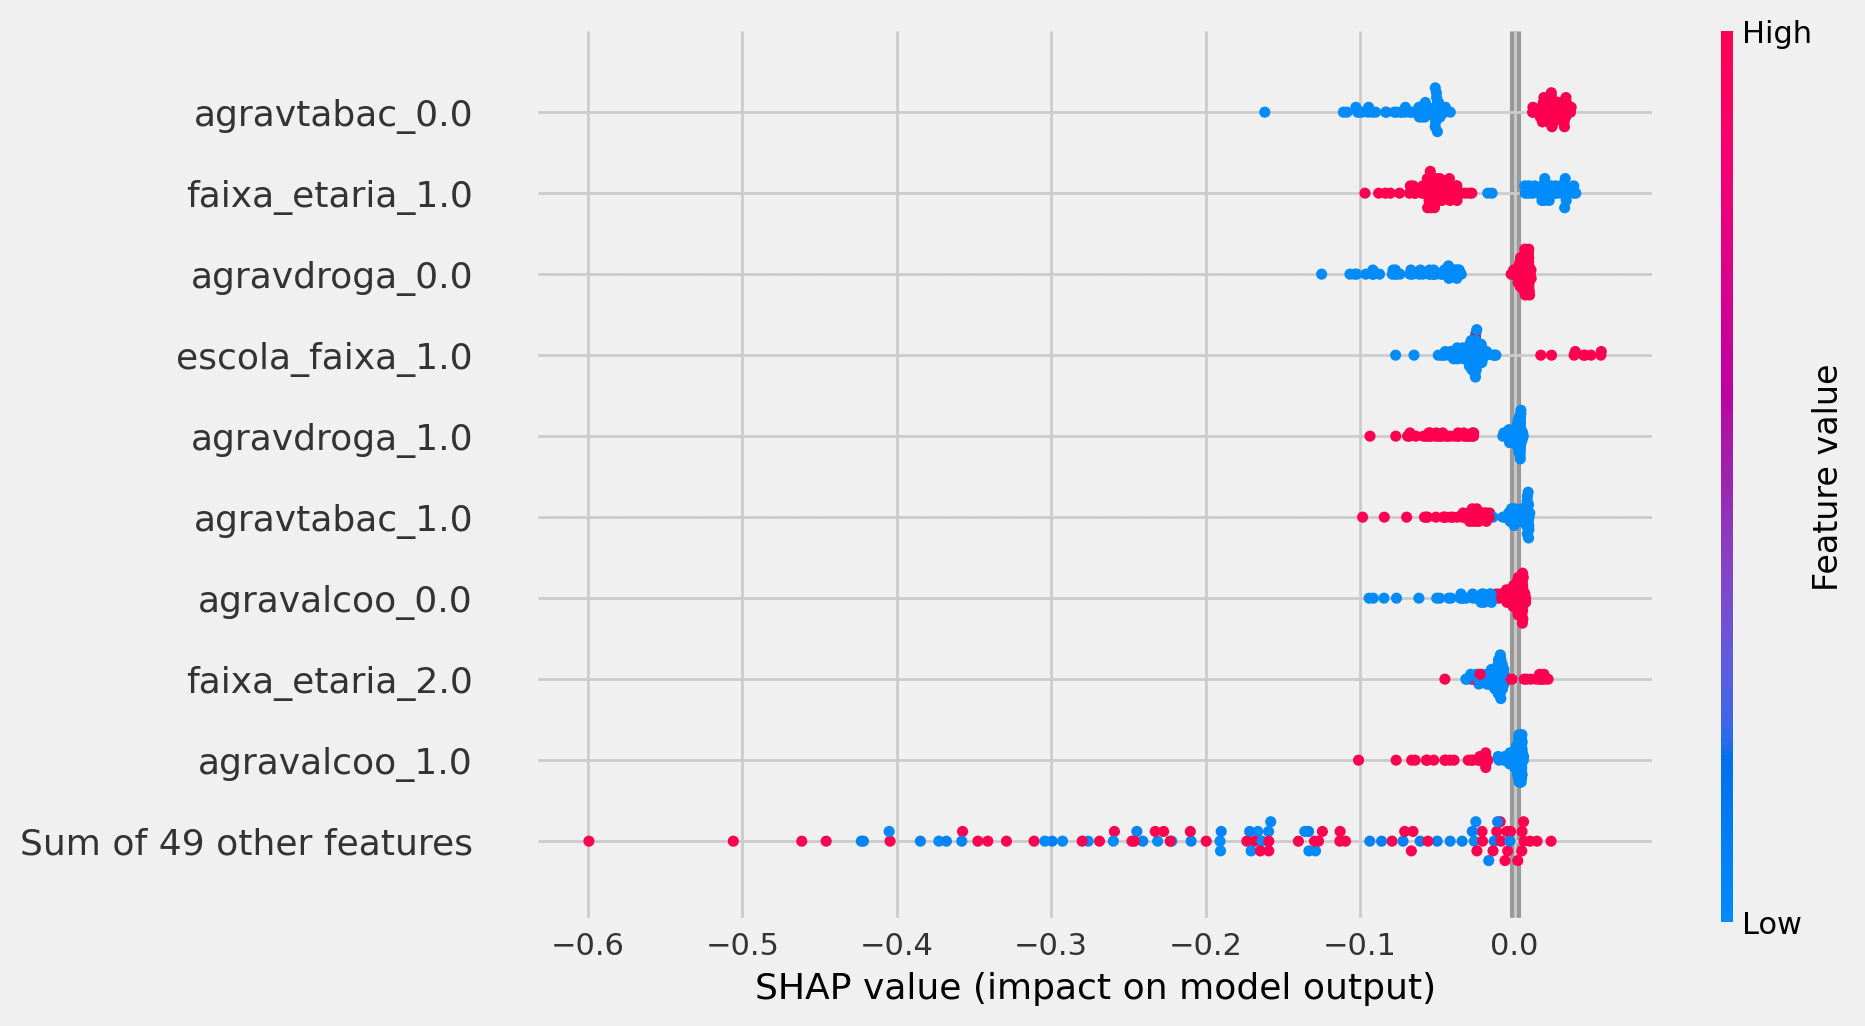

In [ ]:
import shap
import pandas as pd
import numpy as np

# =====================================================
# Seleciona um conjunto de fundo (background)
# =====================================================

background = shap.sample(X_train_tabpfn, 100, random_state=seed)

# =====================================================
# Cria o explicador SHAP
# =====================================================

explainer = shap.Explainer(
    tabpfn.predict_proba,
    background
)

# =====================================================
# Calcula os valores SHAP
# (use poucas amostras inicialmente para acelerar)
# =====================================================

X_explain = X_train_tabpfn.iloc[:100]

shap_values = explainer(X_explain)

# =====================================================
# Gráfico resumo
# =====================================================

shap.plots.beeswarm(shap_values[:, :, 1])

In [ ]:
importance = pd.DataFrame({
    "Variavel": X_explain.columns,
    "SHAP": np.abs(shap_values.values[:, :, 1]).mean(axis=0)
})

importance = (
    importance
    .sort_values("SHAP", ascending=False)
    .head(20)
)

print(importance)

            Variavel      SHAP
41    agravtabac_0.0  0.048398
54  faixa_etaria_1.0  0.040775
38    agravdroga_0.0  0.032573
46  escola_faixa_1.0  0.030735
39    agravdroga_1.0  0.018614
42    agravtabac_1.0  0.018291
14    agravalcoo_0.0  0.014352
55  faixa_etaria_2.0  0.014165
15    agravalcoo_1.0  0.011990
0                pop  0.011517
45  escola_faixa_0.0  0.010611
2        cs_sexo_1.0  0.009844
7        cs_raca_4.0  0.008662
23    bacilosc_e_1.0  0.008565
5        cs_raca_2.0  0.008293
35     benef_gov_0.0  0.007424
56  faixa_etaria_3.0  0.006849
1        cs_sexo_0.0  0.006754
25    bacilosc_e_3.0  0.006562
4        cs_raca_1.0  0.006499


In [ ]:
top20shap = importance.head(20)

print("\nTop 20 variáveis mais importantes:")
print(top20shap)


Top 20 variáveis mais importantes:
            Variavel      SHAP
41    agravtabac_0.0  0.048398
54  faixa_etaria_1.0  0.040775
38    agravdroga_0.0  0.032573
46  escola_faixa_1.0  0.030735
39    agravdroga_1.0  0.018614
42    agravtabac_1.0  0.018291
14    agravalcoo_0.0  0.014352
55  faixa_etaria_2.0  0.014165
15    agravalcoo_1.0  0.011990
0                pop  0.011517
45  escola_faixa_0.0  0.010611
2        cs_sexo_1.0  0.009844
7        cs_raca_4.0  0.008662
23    bacilosc_e_1.0  0.008565
5        cs_raca_2.0  0.008293
35     benef_gov_0.0  0.007424
56  faixa_etaria_3.0  0.006849
1        cs_sexo_0.0  0.006754
25    bacilosc_e_3.0  0.006562
4        cs_raca_1.0  0.006499


####Rodando modelo reduzido

In [ ]:
from tabpfn_client import TabPFNClassifier
from sklearn.metrics import roc_auc_score

# Seleciona as 20 variáveis mais importantes
top20_shap = importance.head(20)['Variavel'].tolist()

print("Top 20 variáveis:")
print(top20_shap)

# Conjunto de treino reduzido
X_train_top20shap = X_train_tabpfn[top20_shap]

# Novo modelo
tabpfn_top20_shap = TabPFNClassifier(
    random_state=seed,
    ignore_pretraining_limits=True
)

# Ajuste
tabpfn_top20_shap.fit(X_train_top20shap, y_train_tabpfn)

# Probabilidades previstas no treino
y_proba_train_shap = tabpfn_top20_shap.predict_proba(X_train_top20shap)[:, 1]

Top 20 variáveis:
['agravtabac_0.0', 'faixa_etaria_1.0', 'agravdroga_0.0', 'escola_faixa_1.0', 'agravdroga_1.0', 'agravtabac_1.0', 'agravalcoo_0.0', 'faixa_etaria_2.0', 'agravalcoo_1.0', 'pop', 'escola_faixa_0.0', 'cs_sexo_1.0', 'cs_raca_4.0', 'bacilosc_e_1.0', 'cs_raca_2.0', 'benef_gov_0.0', 'faixa_etaria_3.0', 'cs_sexo_0.0', 'bacilosc_e_3.0', 'cs_raca_1.0']
00:04 Fitting... Done!
00:02 Predicting... Done!


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, roc_auc_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

tabpfn_novo = TabPFNClassifier(
    random_state=seed,
    ignore_pretraining_limits=True
)

scores = cross_val_score(
    tabpfn_novo,
    X_train_top20shap,
    y_train_tabpfn,
    cv=cv,
    scoring="roc_auc"
)

print(scores)
print(scores.mean())

00:04 Fitting... Done!
00:02 Predicting... Done!
00:02 Fitting... Done!
00:01 Predicting... Done!
00:04 Fitting... Done!
00:01 Predicting... Done!
00:04 Fitting... Done!
00:01 Predicting... Done!
00:02 Fitting... Done!
00:01 Predicting... Done!
[0.71765625 0.72161172 0.67813346 0.67017041 0.70440705]
0.6983957785873547


In [ ]:
auc_cv_novo_tabpfn = scores.mean()

In [ ]:
auc_cv_novo_tabpfn

np.float64(0.6983957785873547)

In [ ]:
# Bases com variáveis selecionadas
X_train_novo = X_train[top20_shap].copy()
X_test_novo = X_test[top20_shap].copy()

# Unificando com a variável alvo
df_train_novo = pd.concat([X_train_novo, y_train], axis=1)
df_test_novo = pd.concat([X_test_novo, y_test], axis=1)

####Salvando dataframe boruta

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Unificando base de Treino
df_train = pd.concat([X_train_novo, y_train], axis = 1)

#Salvando base de Treino
path_to_save_train = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_treino_tabpfn1boruta_rj_2015_2025.csv"
df_train.to_csv(path_to_save_train, index = False)

In [ ]:
#Unificando base de Teste
df_test= pd.concat([X_test_novo, y_test], axis = 1)

#Salvando base de Teste
path_to_save_test = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_teste_tabpfn1boruta_rj_2015_2025.csv"
df_test.to_csv(path_to_save_test, index = False)

###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_treino_tabpfn1boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_teste_tabpfn1boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
#Separação das bases entre X_train, X_test, y_train, y_test
X_train_novo=df_train.drop(columns = "cura")
y_train=df_train.cura
X_test_novo=df_test.drop(columns = "cura")
y_test=df_test.cura

### Retreino do Modelo

In [ ]:
from tabpfn_client import TabPFNClassifier, set_access_token

set_access_token(TOKEN_tabpfn_client)
clf = TabPFNClassifier(random_state=seed)
clf.fit(X_train_novo, y_train)
predictions = clf.predict(X_test_novo)

00:02 Fitting... Done!
00:03 Predicting... Done!


In [ ]:
# Modelo TabPFN com configuração de ensemble
tabpfn_novo=TabPFNClassifier(random_state=seed,ignore_pretraining_limits=True)# para rodar mais de 1000 amostras

#Ajuste da base de treino para rodar o tabpfn (com 1000 amostras, proporcionais)
df_train_novo = df_train.copy()
df_train_novo = (
    df_train_novo
    .groupby('cura', group_keys=False)  # agrupa pelo desfecho
    .apply(lambda x: x.sample(int(1000 * len(x) / len(df_train_novo)), random_state=seed, replace=True))
    .reset_index(drop=True)
)
X_train_novo_tabpfn = df_train_novo.drop(columns = "cura")
y_train_tabpfn = df_train_novo.cura

# Ajuste direto (fit) — sem busca de hiperparâmetros
tabpfn.fit(X_train_novo_tabpfn, y_train_tabpfn)


00:00 Fitting... \

00:02 Fitting... Done!


TabPFNClassifier(client_options=ClientOptions(timeout=900.0,
                                              headers={'sentry-trace': 'b806b50009694737baf4ff9ea010c26a'}),
                 ignore_pretraining_limits=True, random_state=42)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# ======================================
# Validação cruzada (somente treino)
# ======================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

tabpfn_cv = TabPFNClassifier(
    random_state=seed,
    ignore_pretraining_limits=True
)

auc_scores = cross_val_score(
    tabpfn_cv,
    X_train_novo_tabpfn,
    y_train_tabpfn,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1  # recomendado para TabPFN
)

auc_cv_novo_tabpfn = auc_scores.mean()

print(f"AUC CV TabPFN: {auc_cv_novo_tabpfn:.4f}")
print(f"Desvio padrão: {auc_scores.std():.4f}")
print(f"AUC por fold: {auc_scores}")

00:00 Fitting... \

00:04 Fitting... Done!
00:00 Predicting... \

00:01 Predicting... Done!
00:00 Fitting... \

00:04 Fitting... Done!
00:00 Predicting... \

00:01 Predicting... Done!
00:00 Fitting... \

...

00:02 Predicting... Done!
00:00 Fitting... \

00:03 Fitting... Done!
00:00 Predicting... \

00:01 Predicting... Done!
00:00 Fitting... \

00:04 Fitting... Done!
00:00 Predicting... \

00:01 Predicting... Done!
AUC CV TabPFN: 0.6984
Desvio padrão: 0.0208
AUC por fold: [0.71765625 0.72161172 0.67813346 0.67017041 0.70440705]


#### Metricas threshold

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Probabilidades
y_prob_novo_tabpfn = tabpfn.predict_proba(X_test_novo)[:, 1]

# Aplica o threshold
threshold = 0.5
y_pred_novo_tabpfn = (y_prob_novo_tabpfn >= threshold).astype(int)

# Métricas
auc_novo_tabpfn = roc_auc_score(y_test, y_prob_novo_tabpfn)  # Continua usando probabilidade para o AUC

# Impressão
print(f'tabpfn_novo - ROC AUC: {auc_novo_tabpfn:.4f}')


00:02 Predicting... Done!
tabpfn_novo - ROC AUC: 0.6817


In [ ]:
tabpfn_novo.fit(X_train_novo_tabpfn, y_train_tabpfn)

y_prob_novo_tabpfn = tabpfn_novo.predict_proba(X_test_novo)[:, 1]
auc_novo_tabpfn = roc_auc_score(y_test, y_prob_novo_tabpfn)

print(f"AUC CV (treino): {auc_cv_novo_tabpfn:.4f}")
print(f"AUC Teste      : {auc_novo_tabpfn:.4f}")

00:00 Fitting... \

00:04 Fitting... Done!
00:00 Predicting... \

00:02 Predicting... Done!
AUC CV (treino): 0.6984
AUC Teste      : 0.6817


####Salvando modelo boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_tabpfn_novo.pkl"

joblib.dump(tabpfn_novo, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_tabpfn_novo.pkl


In [ ]:
joblib.dump(
    {
        "model_tabpfn_novo": tabpfn_novo,
        "auc_cv_tabpfn_novo": auc_cv_novo_tabpfn,
        "features": list(X_train_novo.columns)
    },
    caminho
)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_tabpfn_novo.pkl']

In [ ]:
data = joblib.load(caminho)

tabpfn_novo = data["model_tabpfn_novo"]
auc_cv_tabpfn_novo = data["auc_cv_tabpfn_novo"]
features_tabpfn = data["features"]

####Comparacao modelo completo e boruta - tabela

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/dados_treino_processados1_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/dados_teste_processados1_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
# Separação das bases entre X_train, X_test, y_train, y_test

X_train = df_train.drop(columns=["cura"])
y_train = df_train["cura"]

X_test = df_test.drop(columns=["cura"])
y_test = df_test["cura"]

In [ ]:
import joblib
import pandas as pd

# Modelo completo
data_full = joblib.load(
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_tabpfn.pkl"
)

# Modelo Boruta/Top Features
data_novo = joblib.load(
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_tabpfn_novo.pkl"
)

auc_cv_tabpfn = data_full["auc_cv_tabpfn"]
auc_cv_tabpfn_novo = data_novo["auc_cv_tabpfn_novo"]

comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Boruta"],
    "AUC-CV": [auc_cv_tabpfn, auc_cv_tabpfn_novo]
})

print(comparacao)

if auc_cv_tabpfn > auc_cv_tabpfn_novo:
    print(f"\n🏆 Melhor modelo: Base Completa (AUC-CV = {auc_cv_tabpfn:.4f})")
elif auc_cv_tabpfn_novo > auc_cv_tabpfn:
    print(f"\n🏆 Melhor modelo: Boruta (AUC-CV = {auc_cv_tabpfn_novo:.4f})")
else:
    print("\n🤝 Os dois modelos possuem o mesmo AUC-CV.")

          Modelo    AUC-CV
0  Base Completa  0.695524
1         Boruta  0.698396

🏆 Melhor modelo: Boruta (AUC-CV = 0.6984)


# Comparando todos os modelos

In [ ]:
!pip install tabpfn-client
import joblib
import pandas as pd
from sklearn.metrics import roc_auc_score
from tabpfn_client import TabPFNClassifier # Added import for TabPFNClassifier

rf = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_rf.pkl")
xgb = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_xgb.pkl")
lgb = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_lgb.pkl")
cat = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_cat.pkl")
tabpfn = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_tabpfn.pkl")
rf_novo = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_rf_novo.pkl")
lgb_novo = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_lgb_novo.pkl")
xgb_novo = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_xgb_novo.pkl")
cat_novo = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_cat_novo.pkl")
tabpfn_novo = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_tabpfn_novo.pkl")

In [ ]:
# ===============================
# SEEDS DOS MODELOS
# ===============================

modelos = {
    "RandomForest": rf['model_rf'],
    "LGBM": lgb['model_lgb'],
    "XGBoost": xgb['model_xgb'],
    "CatBoost": cat['model_cat'],
    "TabPFN": tabpfn['model_tabpfn'],
    "RandomForest_novo": rf_novo['model_rf_novo'],
    "LGBM_novo": lgb_novo['model_lgb_novo'],
    "XGBoost_novo": xgb_novo['model_xgb_novo'],
    "CatBoost_novo": cat_novo['model_cat_novo'],
    "TabPFN_novo": tabpfn_novo['model_tabpfn_novo'],
}

for nome, modelo in modelos.items():
    try:
        params = modelo.get_params()

        seed = (
            params.get('random_state')
            or params.get('seed')
            or params.get('random_seed')
        )

        print(f"{nome}: {seed}")

    except Exception as e:
        print(f"{nome}: não foi possível obter a seed ({e})")

RandomForest: 42
LGBM: 42
XGBoost: 42
CatBoost: 42
TabPFN: não foi possível obter a seed ('TabPFNClassifier' object has no attribute 'api_mode')
RandomForest_novo: 42
LGBM_novo: 42
XGBoost_novo: 42
CatBoost_novo: 42
TabPFN_novo: 42


In [ ]:
# ============================================================
# CONTAGEM REAL DE VARIÁVEIS BORUTA E AUDITORIA DOS MODELOS
# ============================================================

import pandas as pd

TARGET = "cura"

# ------------------------
# Bases pós-Boruta
# ------------------------

paths_boruta = {
    "RandomForest_novo":
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_treino_rf1boruta_rj_2015_2025.csv",

    "LGBM_novo":
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_treino_lgb1boruta_rj_2015_2025.csv",

    "XGBoost_novo":
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_treino_xgb1boruta_rj_2015_2025.csv",

    "CatBoost_novo":
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_treino_cat1boruta_rj_2015_2025.csv",

    "TabPFN_novo":
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_treino_tabpfn1boruta_rj_2015_2025.csv"
}

# ------------------------
# Modelos novos
# ------------------------

modelos_novos = {
    "RandomForest_novo": rf_novo['model_rf_novo'],
    "LGBM_novo": lgb_novo['model_lgb_novo'],
    "XGBoost_novo": xgb_novo['model_xgb_novo'],
    "CatBoost_novo": cat_novo['model_cat_novo'],
    "TabPFN_novo": tabpfn_novo['model_tabpfn_novo']
}

audit_boruta = {}

for nome, caminho in paths_boruta.items():

    df_boruta = pd.read_csv(caminho)

    # Remove desfecho
    features_boruta = [c for c in df_boruta.columns if c != TARGET]

    n_features_boruta = len(features_boruta)

    modelo = modelos_novos[nome]

    # Recupera features efetivamente usadas pelo modelo
    try:

        if hasattr(modelo, "feature_names_in_"):
            features_modelo = list(modelo.feature_names_in_)

        elif hasattr(modelo, "feature_names_"):
            features_modelo = list(modelo.feature_names_)

        else:
            features_modelo = []

        n_features_modelo = len(features_modelo)

        faltantes = sorted(
            list(set(features_boruta) - set(features_modelo))
        )

        extras = sorted(
            list(set(features_modelo) - set(features_boruta))
        )

        status = (
            "OK"
            if len(faltantes) == 0 and len(extras) == 0
            else "DIVERGENTE"
        )

    except Exception as e:

        n_features_modelo = None
        faltantes = []
        extras = []
        status = f"Erro: {e}"

    audit_boruta[nome] = {
        "N_Boruta": n_features_boruta,
        "N_Modelo": n_features_modelo,
        "Status": status,
        "Faltantes": faltantes,
        "Extras": extras
    }

# ------------------------
# Mostrar auditoria
# ------------------------

print("\n" + "="*60)
print("AUDITORIA BORUTA × MODELO")
print("="*60)

for nome, info in audit_boruta.items():

    print(f"\n{nome}")
    print(f"Variáveis Boruta : {info['N_Boruta']}")
    print(f"Variáveis Modelo : {info['N_Modelo']}")
    print(f"Status           : {info['Status']}")

    if len(info['Faltantes']) > 0:
        print(f"\nFaltantes ({len(info['Faltantes'])}):")
        print(info['Faltantes'])

    if len(info['Extras']) > 0:
        print(f"\nExtras ({len(info['Extras'])}):")
        print(info['Extras'])


AUDITORIA BORUTA × MODELO

RandomForest_novo
Variáveis Boruta : 13
Variáveis Modelo : 13
Status           : OK

LGBM_novo
Variáveis Boruta : 11
Variáveis Modelo : 11
Status           : OK

XGBoost_novo
Variáveis Boruta : 25
Variáveis Modelo : 25
Status           : OK

CatBoost_novo
Variáveis Boruta : 15
Variáveis Modelo : 15
Status           : OK

TabPFN_novo
Variáveis Boruta : 20
Variáveis Modelo : 0
Status           : DIVERGENTE

Faltantes (20):
['agravalcoo_0.0', 'agravalcoo_1.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravtabac_0.0', 'agravtabac_1.0', 'bacilosc_e_1.0', 'bacilosc_e_3.0', 'benef_gov_0.0', 'cs_raca_1.0', 'cs_raca_2.0', 'cs_raca_4.0', 'cs_sexo_0.0', 'cs_sexo_1.0', 'escola_faixa_0.0', 'escola_faixa_1.0', 'faixa_etaria_1.0', 'faixa_etaria_2.0', 'faixa_etaria_3.0', 'pop']


In [ ]:
resultados_cv = [

    {
        "Modelo": "RandomForest",
        "AUC_CV": rf["auc_cv_rf"],
        "N_Features": X_train.shape[1]
    },

    {
        "Modelo": "LGBM",
        "AUC_CV": lgb["auc_cv_lgb"],
        "N_Features": X_train.shape[1]
    },

    {
        "Modelo": "XGBoost",
        "AUC_CV": xgb["auc_cv_xgb"],
        "N_Features": X_train.shape[1]
    },

    {
        "Modelo": "CatBoost",
        "AUC_CV": cat["auc_cv_cat"],
        "N_Features": X_train.shape[1]
    },

    {
        "Modelo": "TabPFN",
        "AUC_CV": tabpfn["auc_cv_tabpfn"],
        "N_Features": X_train.shape[1]
    },

    {
        "Modelo": "RandomForest_novo",
        "AUC_CV": rf_novo["auc_cv_rf_novo"],
        "N_Features": audit_boruta["RandomForest_novo"]["N_Boruta"]
    },

    {
        "Modelo": "LGBM_novo",
        "AUC_CV": lgb_novo["auc_cv_lgb_novo"],
        "N_Features": audit_boruta["LGBM_novo"]["N_Boruta"]
    },

    {
        "Modelo": "XGBoost_novo",
        "AUC_CV": xgb_novo["auc_xgb_novo"],
        "N_Features": audit_boruta["XGBoost_novo"]["N_Boruta"]
    },

    {
        "Modelo": "CatBoost_novo",
        "AUC_CV": cat_novo["auc_cv_cat_novo"],
        "N_Features": audit_boruta["CatBoost_novo"]["N_Boruta"]
    },

    {
        "Modelo": "TabPFN_novo",
        "AUC_CV": tabpfn_novo["auc_cv_tabpfn_novo"],
        "N_Features": audit_boruta["TabPFN_novo"]["N_Boruta"]
    }
]

df_cv = (
    pd.DataFrame(resultados_cv)
      .sort_values("AUC_CV", ascending=False)
      .reset_index(drop=True)
)

print("\n")
print("=" * 60)
print("RANKING FINAL DOS MODELOS - AUC DA VALIDAÇÃO CRUZADA")
print("=" * 60)
print(df_cv)




RANKING FINAL DOS MODELOS - AUC DA VALIDAÇÃO CRUZADA
              Modelo    AUC_CV  N_Features
0       XGBoost_novo  0.720853          25
1               LGBM  0.719252          58
2           CatBoost  0.719252          58
3            XGBoost  0.719252          58
4      CatBoost_novo  0.718284          15
5       RandomForest  0.715805          58
6  RandomForest_novo  0.711654          13
7        TabPFN_novo  0.698396          20
8          LGBM_novo  0.698201          11
9             TabPFN  0.695524          58
